# FX Option Signals and Carry: Regression Analysis

Baseline FX carry ranks currencies using the one-month forward discount. This notebook studies whether one-month FX option signals help explain the future return or risk quality of carry before any trading rule is designed.

ATM implied volatility measures the market's overall expected FX uncertainty. Risk reversals, after direction normalization, measure asymmetric pricing of foreign-currency appreciation versus depreciation risk. The foreign-currency-perspective 25-delta risk reversal is:

$$
RR^{foreign}_{25D,1M}
=
IV(\text{foreign currency call})
-
IV(\text{foreign currency put}),
$$

and bad skew is defined as:

$$
BadSkew_{25D,1M}
=
-RR^{foreign}_{25D,1M}
=
IV(\text{foreign put})
-
IV(\text{foreign call}).
$$

The main empirical hypothesis is:

> Option signals may not be standalone return predictors. Instead, they may condition the quality of carry: the relation between carry and future returns may depend on ATM volatility or depreciation skew.

The analysis distinguishes return prediction, cross-sectional carry-quality assessment, risk-state measurement, and portfolio risk management. This notebook does not implement or optimize a trading strategy.


## Scope

The horizon matches the existing carry and option-filter notebook:

- monthly observations;
- 1M forward carry;
- 1M ATM implied volatility;
- 1M 25D risk reversal and butterfly;
- next-month realized 1M forward excess return.

The primary variables are `atm_vol_1m`, `rr25_foreign_1m`, `bad_skew25_1m`, and `bf25_1m`. The 10D risk reversal and butterfly are retained as robustness variables where available, but the primary regressions use 25D signals only so the option horizon aligns with the future return horizon.


In [1]:

from pathlib import Path
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
except Exception:
    plt = None
    mcolors = None

try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from statsmodels.stats.outliers_influence import OLSInfluence
    STATSMODELS_AVAILABLE = True
except Exception as exc:
    STATSMODELS_AVAILABLE = False
    warnings.warn(f"statsmodels unavailable; regression sections will be skipped where needed: {repr(exc)}")

try:
    from scipy import stats as scipy_stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 220)

NOTEBOOK_NAME = "06_options_filter_regression.ipynb"
MONTHS_PER_YEAR = 12
MIN_Z_N_ALL = 5
MIN_Z_N_CLASS = 3
MIN_CELL_OBS = 15
MIN_CELL_MONTHS = 8
ROLLING_MIN_TRAIN_MONTHS = 60


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start] + list(start.parents):
        if (candidate / "data").exists() and (candidate / "theo" / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("Could not find project root.")

ROOT = find_project_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "theo" / "data" / "processed"
FIG_DIR = PROCESSED_DIR / "option_filter_regression_figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

G10_PANEL_PATH = PROCESSED_DIR / "g10_1m_carry_panel.parquet"
EM_PANEL_PATH = PROCESSED_DIR / "em_1m_carry_panel.parquet"
G10_OPTIONS_PATH = RAW_DIR / "g10_fx_options_long.parquet"
EM_OPTIONS_PATH = RAW_DIR / "em_fx_options_long.parquet"

OUTPUTS = {
    "panel": PROCESSED_DIR / "option_filter_regression_panel.parquet",
    "coverage": PROCESSED_DIR / "option_filter_regression_coverage.parquet",
    "descriptive": PROCESSED_DIR / "option_filter_regression_descriptive.parquet",
    "conditional": PROCESSED_DIR / "option_filter_conditional_returns.parquet",
    "heatmap": PROCESSED_DIR / "option_filter_heatmap_cells.parquet",
    "regression": PROCESSED_DIR / "option_filter_regression_results.parquet",
    "fixed_effects": PROCESSED_DIR / "option_filter_regression_fixed_effects.parquet",
    "heterogeneity": PROCESSED_DIR / "option_filter_regression_heterogeneity.parquet",
    "marginal": PROCESSED_DIR / "option_filter_regression_marginal_effects.parquet",
    "robustness": PROCESSED_DIR / "option_filter_regression_robustness.parquet",
    "influence": PROCESSED_DIR / "option_filter_regression_influence.parquet",
    "oos": PROCESSED_DIR / "option_filter_regression_oos_predictions.parquet",
    "summary": PROCESSED_DIR / "option_filter_regression_summary.json",
    "butterfly_descriptive": PROCESSED_DIR / "option_filter_butterfly_descriptive.parquet",
    "butterfly_heatmap": PROCESSED_DIR / "option_filter_butterfly_heatmap_cells.parquet",
    "butterfly_regression": PROCESSED_DIR / "option_filter_butterfly_regression_results.parquet",
    "butterfly_risk": PROCESSED_DIR / "option_filter_butterfly_risk_results.parquet",
    "butterfly_robustness": PROCESSED_DIR / "option_filter_butterfly_robustness.parquet",
    "butterfly_summary": PROCESSED_DIR / "option_filter_butterfly_summary.json",
}

skipped_models = []
successful_sections = []
figure_paths = []
figure_audit_rows = []
heatmap_validation_rows = []

print(f"Project root: {ROOT}")
print(f"Figure directory: {FIG_DIR.relative_to(ROOT)}")


Project root: /Users/theoli/Documents/Work/UChicago/Courses/36000_project_lab/BofA/repo
Figure directory: theo/data/processed/option_filter_regression_figures


## Plotting Helpers and Visualization Standards

Return heatmaps use a red-white-green diverging scale centered at zero: green means positive mean next-month FX forward excess return, red means negative, and white means zero. Count heatmaps use a separate sequential scale and are labeled as observation counts.


In [2]:

from matplotlib.colors import LinearSegmentedColormap
RETURN_CMAP = "RdYlGn"
COUNT_CMAP = "Greys"
HEATMAP_NOTE = "Cell color represents mean next-month FX forward excess return. Green = positive, red = negative, white = zero. Cell text shows mean return and observation count."

LABELS = {
    "carry": "1M carry signal",
    "atm_vol": "1M ATM implied volatility (%)",
    "bad_skew": "1M 25D bad skew (foreign put IV - foreign call IV)",
    "bf25": "1M 25D butterfly / smile curvature",
    "future_return": "Next-month FX forward excess return",
    "month": "Month end",
}

QUINTILE_AXIS_LABELS = {
    "carry": "1M carry-signal quintile\n1 = lowest, 5 = highest within the stated monthly ranking universe",
    "vol": "1M ATM implied-volatility quintile\n1 = lowest, 5 = highest within the stated monthly ranking universe",
    "skew": "1M 25D bad-skew quintile\n1 = lowest depreciation skew, 5 = highest depreciation skew",
    "bf25": "1M 25D butterfly quintile\n1 = lowest smile curvature, 5 = highest smile curvature",
}

def finalize_axis(ax, *, title, xlabel, ylabel, note=None, add_zero_line=False):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if add_zero_line:
        if ax.get_xscale() == "linear":
            ax.axhline(0, color="#333333", lw=.9, alpha=.75)
    ax.grid(alpha=.25)
    if note:
        ax.text(0.0, -0.22, note, transform=ax.transAxes, ha="left", va="top", fontsize=8, color="#444444")
    return ax

def audit_figure(fig, name):
    rows=[]
    for i, ax in enumerate(fig.axes):
        # Matplotlib colorbars are separate axes. They should have a legend label,
        # but not a chart title or ordinary x/y labels.
        label = str(ax.get_label())
        is_heatmap_colorbar = "heatmap" in str(name) and i >= 2
        is_colorbar = label.startswith("<colorbar") or is_heatmap_colorbar
        rows.append({
            "figure": name,
            "axis_index": i,
            "title_present": bool(str(ax.get_title()).strip()) or is_colorbar,
            "xlabel_present": bool(str(ax.get_xlabel()).strip()) or is_colorbar,
            "ylabel_present": bool(str(ax.get_ylabel()).strip()) or is_colorbar,
            "documented_exception": "colorbar axis" if is_colorbar else "",
        })
    figure_audit_rows.extend(rows)
    return rows

def savefig(fig, name):
    path = FIG_DIR / name
    audit_figure(fig, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    figure_paths.append(path)
    return path

def symmetric_limit(values, fallback=0.01):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return fallback
    lim = float(np.nanmax(np.abs(vals)))
    return lim if lim > 0 else fallback

def ranking_convention_label(sample, ranking_version):
    if "global" in str(ranking_version):
        return "quintiles formed across all available currencies each month"
    if sample == "G10":
        return "quintiles formed within G10 each month"
    if sample == "EM":
        return "quintiles formed within EM each month"
    return "quintiles formed within asset class each month"

def heatmap_axis_label(q_name):
    token = str(q_name).split("_")[1] if "_" in str(q_name) else str(q_name)
    return QUINTILE_AXIS_LABELS.get(token, str(q_name))

def plot_return_heatmap_from_cells(cells, *, table, sample, ranking_version, output_name, shared_limit=None):
    if plt is None or cells.empty:
        return None
    sub = cells[(cells["table"].eq(table)) & (cells["sample"].eq(sample)) & (cells["ranking_version"].eq(ranking_version))].copy()
    if sub.empty:
        return None
    piv = sub.pivot(index="row_quantile", columns="column_quantile", values="mean_future_return").sort_index(ascending=False)
    cnt = sub.pivot(index="row_quantile", columns="column_quantile", values="observations").sort_index(ascending=False)
    sufficient = sub.pivot(index="row_quantile", columns="column_quantile", values="sufficient_cell").sort_index(ascending=False).reindex_like(piv).fillna(False)
    unique_months = sub.pivot(index="row_quantile", columns="column_quantile", values="unique_months").sort_index(ascending=False).reindex_like(piv)
    lim = shared_limit if shared_limit is not None else symmetric_limit(piv.to_numpy())
    norm = mcolors.TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim) if mcolors is not None else None
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
    masked = np.ma.masked_where(~sufficient.to_numpy(dtype=bool), piv.to_numpy(dtype=float))
    cmap = plt.get_cmap(RETURN_CMAP).copy(); cmap.set_bad(color="#D9D9D9")
    im = axes[0].imshow(masked, cmap=cmap, norm=norm)
    row_q = sub["row_q"].dropna().iloc[0] if sub["row_q"].notna().any() else "row quintile"
    col_q = sub["col_q"].dropna().iloc[0] if sub["col_q"].notna().any() else "column quintile"
    title = f"Mean next-month FX forward excess return\n{sample} sample — {ranking_convention_label(sample, ranking_version)}"
    axes[0].set_title(title)
    axes[0].set_xlabel(heatmap_axis_label(col_q))
    axes[0].set_ylabel(heatmap_axis_label(row_q))
    axes[0].set_xticks(range(len(piv.columns))); axes[0].set_xticklabels(piv.columns.astype(int))
    axes[0].set_yticks(range(len(piv.index))); axes[0].set_yticklabels(piv.index.astype(int))
    for ii in range(piv.shape[0]):
        for jj in range(piv.shape[1]):
            val = piv.iloc[ii, jj]
            n = cnt.iloc[ii, jj] if jj < cnt.shape[1] else np.nan
            ok = bool(sufficient.iloc[ii, jj]) if ii < sufficient.shape[0] and jj < sufficient.shape[1] else False
            if pd.notna(val):
                txt = f"{val:+.2%}\nn={int(n)}" if pd.notna(n) else f"{val:+.2%}"
                if not ok:
                    txt += "\nlow n"
                axes[0].text(jj, ii, txt, ha="center", va="center", fontsize=8, color="#111111")
    cb = fig.colorbar(im, ax=axes[0], fraction=.046, pad=.04)
    cb.ax.set_ylabel("Mean next-month return")
    im2 = axes[1].imshow(cnt.to_numpy(dtype=float), cmap=COUNT_CMAP)
    axes[1].set_title(f"Observation count\n{sample} sample — {ranking_convention_label(sample, ranking_version)}")
    axes[1].set_xlabel(heatmap_axis_label(col_q))
    axes[1].set_ylabel(heatmap_axis_label(row_q))
    axes[1].set_xticks(range(len(cnt.columns))); axes[1].set_xticklabels(cnt.columns.astype(int))
    axes[1].set_yticks(range(len(cnt.index))); axes[1].set_yticklabels(cnt.index.astype(int))
    for ii in range(cnt.shape[0]):
        for jj in range(cnt.shape[1]):
            n = cnt.iloc[ii, jj]
            axes[1].text(jj, ii, f"{int(n)}" if pd.notna(n) else "", ha="center", va="center", fontsize=8)
    cb2 = fig.colorbar(im2, ax=axes[1], fraction=.046, pad=.04)
    cb2.ax.set_ylabel("Observation count")
    fig.text(0.01, 0.01, HEATMAP_NOTE, ha="left", va="bottom", fontsize=8, color="#444444")
    fig.tight_layout(rect=[0, .05, 1, 1])
    heatmap_validation_rows.append({"figure": output_name, "table": table, "sample": sample, "ranking_version": ranking_version, "return_cmap": RETURN_CMAP, "count_cmap": COUNT_CMAP, "vmin": -lim, "vmax": lim, "center": 0.0, "symmetric_limits": np.isclose(abs(-lim), abs(lim)), "count_uses_return_cmap": COUNT_CMAP == RETURN_CMAP})
    savefig(fig, output_name)
    plt.show()
    return fig


## Reproduce and Validate Data Preparation

This section reuses the data-loading, option-pair mapping, and risk-reversal sign conversion logic from the existing options notebook, but keeps only the pieces needed for a regression panel.

Future returns use the same convention as the carry notebooks:

$$
r_{i,t+1}^{FX}
=
\log S_{i,t+1}
-
\log F^{1M}_{i,t}.
$$

This can be decomposed as:

$$
r_{i,t+1}^{FX}
=
\left(\log S_{i,t}-\log F^{1M}_{i,t}\right)
+
\left(\log S_{i,t+1}-\log S_{i,t}\right).
$$

The first term is the carry known at month $t$ and the second term is subsequent spot appreciation of the foreign currency against USD. Option signals are observed at month $t$ and merged to the future return already stored in the clean carry panels.


In [3]:

def safe_read_parquet(path):
    if not path.exists():
        return pd.DataFrame(), {"path": str(path.relative_to(ROOT)) if path.is_relative_to(ROOT) else str(path), "loaded": False, "rows": 0, "message": "missing"}
    try:
        df = pd.read_parquet(path)
        return df, {"path": str(path.relative_to(ROOT)), "loaded": True, "rows": len(df), "message": ""}
    except Exception as exc:
        return pd.DataFrame(), {"path": str(path), "loaded": False, "rows": 0, "message": repr(exc)}

print("Loading carry and option data from saved files...")
g10_carry_raw, st_g10 = safe_read_parquet(G10_PANEL_PATH)
em_carry_raw, st_em = safe_read_parquet(EM_PANEL_PATH)
g10_opts_raw, st_g10o = safe_read_parquet(G10_OPTIONS_PATH)
em_opts_raw, st_emo = safe_read_parquet(EM_OPTIONS_PATH)
load_status = pd.DataFrame([st_g10, st_em, st_g10o, st_emo])
display(load_status)
if not (st_g10["loaded"] and st_em["loaded"] and st_g10o["loaded"] and st_emo["loaded"]):
    raise FileNotFoundError("Required carry or option input files are missing; cannot build regression panel.")


def harmonize_g10(df):
    out = df.copy()
    out["month_end"] = pd.to_datetime(out["month_end"], errors="coerce")
    out["asset_class"] = "G10"
    # Preserve the original processed-panel convention if available.
    if {"spot_usd_per_ccy", "forward_1m_usd_per_ccy", "next_month_spot_usd_per_ccy"}.issubset(out.columns):
        out["carry_signal_1m"] = np.log(out["spot_usd_per_ccy"]) - np.log(out["forward_1m_usd_per_ccy"])
        out["realized_1m_forward_excess_return"] = np.log(out["next_month_spot_usd_per_ccy"]) - np.log(out["forward_1m_usd_per_ccy"])
    return out[["month_end", "currency", "asset_class", "carry_signal_1m", "realized_1m_forward_excess_return"]]


def harmonize_em(df):
    out = df.copy()
    out["month_end"] = pd.to_datetime(out["month_end"], errors="coerce")
    out["asset_class"] = "EM"
    return out[["month_end", "currency", "asset_class", "carry_signal_1m", "realized_1m_forward_excess_return"]]

carry_panel = pd.concat([harmonize_g10(g10_carry_raw), harmonize_em(em_carry_raw)], ignore_index=True)
carry_panel = carry_panel.dropna(subset=["month_end", "currency", "asset_class"]).sort_values(["month_end", "asset_class", "currency"]).reset_index(drop=True)
display(carry_panel.groupby("asset_class").agg(rows=("currency", "size"), currencies=("currency", "nunique"), first=("month_end", "min"), last=("month_end", "max")))


Loading carry and option data from saved files...


,path,loaded,rows,message
0,theo/data/processed/g10_1m_carry_panel.parquet,True,2106,
1,theo/data/processed/em_1m_carry_panel.parquet,True,4169,
2,data/raw/g10_fx_options_long.parquet,True,4170477,
3,data/raw/em_fx_options_long.parquet,True,4847571,


,rows,currencies,first,last
asset_class,,,,
EM,4169,18,2007-01-31,2026-06-30
G10,2106,9,2007-01-31,2026-06-30


In [4]:

PAIR_MAP = {
    "AUD": {"option_pair": "AUDUSD", "asset_class": "G10", "foreign_is_base": True},
    "CAD": {"option_pair": "USDCAD", "asset_class": "G10", "foreign_is_base": False},
    "CHF": {"option_pair": "USDCHF", "asset_class": "G10", "foreign_is_base": False},
    "EUR": {"option_pair": "EURUSD", "asset_class": "G10", "foreign_is_base": True},
    "GBP": {"option_pair": "GBPUSD", "asset_class": "G10", "foreign_is_base": True},
    "JPY": {"option_pair": "USDJPY", "asset_class": "G10", "foreign_is_base": False},
    "NOK": {"option_pair": "USDNOK", "asset_class": "G10", "foreign_is_base": False},
    "NZD": {"option_pair": "NZDUSD", "asset_class": "G10", "foreign_is_base": True},
    "SEK": {"option_pair": "USDSEK", "asset_class": "G10", "foreign_is_base": False},
    "MXN": {"option_pair": "USDMXN", "asset_class": "EM", "foreign_is_base": False},
    "ZAR": {"option_pair": "USDZAR", "asset_class": "EM", "foreign_is_base": False},
    "BRL": {"option_pair": "USDBRL", "asset_class": "EM", "foreign_is_base": False},
    "KRW": {"option_pair": "USDKRW", "asset_class": "EM", "foreign_is_base": False},
    "SGD": {"option_pair": "USDSGD", "asset_class": "EM", "foreign_is_base": False},
    "CNH": {"option_pair": "USDCNH", "asset_class": "EM", "foreign_is_base": False},
    "INR": {"option_pair": "USDINR", "asset_class": "EM", "foreign_is_base": False},
    "TRY": {"option_pair": "USDTRY", "asset_class": "EM", "foreign_is_base": False},
    "PLN": {"option_pair": "USDPLN", "asset_class": "EM", "foreign_is_base": False},
    "HUF": {"option_pair": "USDHUF", "asset_class": "EM", "foreign_is_base": False},
    "THB": {"option_pair": "USDTHB", "asset_class": "EM", "foreign_is_base": False},
    "ILS": {"option_pair": "USDILS", "asset_class": "EM", "foreign_is_base": False},
}
OPTION_TYPES = ["V", "25R", "25B", "10R", "10B"]
OPTION_TENOR = "1M"
pair_table = pd.DataFrame([{ "currency": k, **v, "rr_sign_to_foreign": 1 if v["foreign_is_base"] else -1 } for k, v in PAIR_MAP.items()])
display(pair_table)


def prepare_option_long(df, asset_class):
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out["ticker"] = out["ticker"].astype(str)
    out["field"] = out["field"].astype(str)
    out["value"] = pd.to_numeric(out["value"], errors="coerce")
    out["asset_class"] = asset_class
    return out.dropna(subset=["date", "ticker", "field"])

print("Constructing monthly 1M option signal panel...")
options_long = pd.concat([prepare_option_long(g10_opts_raw, "G10"), prepare_option_long(em_opts_raw, "EM")], ignore_index=True)
needed_tickers = {f"{cfg['option_pair']}{code}{OPTION_TENOR} Curncy" for cfg in PAIR_MAP.values() for code in OPTION_TYPES}
options_long = options_long[options_long["ticker"].isin(needed_tickers) & options_long["field"].eq("PX_LAST")].copy()


def option_series(pair, opt_code, tenor=OPTION_TENOR):
    ticker = f"{pair}{opt_code}{tenor} Curncy"
    s = (options_long[options_long["ticker"].eq(ticker)]
         .sort_values("date")
         .drop_duplicates(subset=["date"], keep="last")
         .set_index("date")["value"])
    return s.rename(opt_code)

rows=[]
for ccy, cfg in PAIR_MAP.items():
    parts=[]
    for code in OPTION_TYPES:
        s = option_series(cfg["option_pair"], code)
        if not s.empty:
            parts.append(s)
    if not parts:
        continue
    daily = pd.concat(parts, axis=1).sort_index()
    monthly = daily.resample("ME").last().reset_index().rename(columns={"date": "month_end"})
    monthly["currency"] = ccy
    monthly["asset_class"] = cfg["asset_class"]
    monthly["option_pair"] = cfg["option_pair"]
    monthly["foreign_is_base"] = cfg["foreign_is_base"]
    monthly["rr_sign_to_foreign"] = 1 if cfg["foreign_is_base"] else -1
    rows.append(monthly)

option_panel = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
rename_map = {"V": "atm_vol_1m", "25R": "rr25_raw_1m", "25B": "bf25_1m", "10R": "rr10_raw_1m", "10B": "bf10_1m"}
option_panel = option_panel.rename(columns=rename_map)
for col in ["atm_vol_1m", "rr25_raw_1m", "bf25_1m", "rr10_raw_1m", "bf10_1m"]:
    if col not in option_panel.columns:
        option_panel[col] = np.nan
option_panel["rr25_foreign_1m"] = option_panel["rr25_raw_1m"] * option_panel["rr_sign_to_foreign"]
option_panel["rr10_foreign_1m"] = option_panel["rr10_raw_1m"] * option_panel["rr_sign_to_foreign"]
option_panel["bad_skew25_1m"] = -option_panel["rr25_foreign_1m"]
option_panel["bad_skew10_1m"] = -option_panel["rr10_foreign_1m"]
option_panel["option_data_quality_flag"] = np.where(option_panel["atm_vol_1m"].notna() & option_panel["rr25_raw_1m"].notna(), "ok", "partial option data")
option_panel = option_panel[["month_end", "currency", "asset_class", "option_pair", "atm_vol_1m", "rr25_raw_1m", "bf25_1m", "rr10_raw_1m", "bf10_1m", "rr25_foreign_1m", "rr10_foreign_1m", "bad_skew25_1m", "bad_skew10_1m", "foreign_is_base", "rr_sign_to_foreign", "option_data_quality_flag"]]
option_panel = option_panel.sort_values(["month_end", "asset_class", "currency"]).reset_index(drop=True)
display(pd.DataFrame([{ "rows": len(option_panel), "currencies": option_panel["currency"].nunique(), "first": option_panel["month_end"].min(), "last": option_panel["month_end"].max() }]))


,currency,option_pair,asset_class,foreign_is_base,rr_sign_to_foreign
0,AUD,AUDUSD,G10,True,1
1,CAD,USDCAD,G10,False,-1
2,CHF,USDCHF,G10,False,-1
3,EUR,EURUSD,G10,True,1
4,GBP,GBPUSD,G10,True,1
5,JPY,USDJPY,G10,False,-1
6,NOK,USDNOK,G10,False,-1
7,NZD,NZDUSD,G10,True,1
8,SEK,USDSEK,G10,False,-1
9,MXN,USDMXN,EM,False,-1


Constructing monthly 1M option signal panel...


,rows,currencies,first,last
0,4865,21,2007-01-31,2026-06-30


In [5]:

print("Merging carry and option signals...")
reg_panel = carry_panel.merge(option_panel, on=["month_end", "currency", "asset_class"], how="inner")
required = ["carry_signal_1m", "realized_1m_forward_excess_return", "atm_vol_1m", "rr25_foreign_1m", "bad_skew25_1m", "bf25_1m"]
for col in required:
    reg_panel[col] = pd.to_numeric(reg_panel[col], errors="coerce")
reg_panel = reg_panel.sort_values(["month_end", "asset_class", "currency"]).reset_index(drop=True)
reg_panel["is_em"] = reg_panel["asset_class"].eq("EM")
reg_panel["future_loss"] = (reg_panel["realized_1m_forward_excess_return"] < 0).astype(float)
reg_panel["return_bps"] = 10000 * reg_panel["realized_1m_forward_excess_return"]

# Assertions and validation checks.
dupe = reg_panel.duplicated(["month_end", "currency"], keep=False)
if dupe.any():
    raise AssertionError(f"Duplicate month_end x currency keys detected: {reg_panel.loc[dupe, ['month_end','currency']].head().to_dict('records')}")
if not reg_panel["month_end"].is_monotonic_increasing:
    # Sorting by currency inside month breaks strict monotonic blocks only if month order is wrong; this catches actual disorder after sorting.
    if list(reg_panel["month_end"]) != sorted(reg_panel["month_end"]):
        raise AssertionError("Month order is not sorted.")
num_cols = reg_panel.select_dtypes(include=[np.number]).columns
if np.isinf(reg_panel[num_cols].to_numpy(dtype=float)).any():
    raise AssertionError("Infinite numeric values detected in regression panel.")
if not (reg_panel["rr25_foreign_1m"].round(10).eq((reg_panel["rr25_raw_1m"] * reg_panel["rr_sign_to_foreign"]).round(10)) | reg_panel["rr25_foreign_1m"].isna()).all():
    raise AssertionError("RR sign conversion check failed.")
if not (reg_panel["bad_skew25_1m"].round(10).eq((-reg_panel["rr25_foreign_1m"]).round(10)) | reg_panel["bad_skew25_1m"].isna()).all():
    raise AssertionError("Bad-skew definition check failed.")

miss_cols = required + ["rr10_foreign_1m", "bad_skew10_1m", "bf10_1m"]
missingness = reg_panel.groupby(["asset_class", "currency"])[miss_cols].apply(lambda x: x.isna().sum()).reset_index()
reg_panel_clean = reg_panel.dropna(subset=required).copy()
if reg_panel_clean.empty:
    raise ValueError("No complete 25D option/carry observations are available for regression.")

panel_summary = pd.DataFrame([{
    "rows_before_required_drop": len(reg_panel),
    "rows_after_required_drop": len(reg_panel_clean),
    "currencies": reg_panel_clean["currency"].nunique(),
    "months": reg_panel_clean["month_end"].nunique(),
    "first_month": reg_panel_clean["month_end"].min(),
    "last_month": reg_panel_clean["month_end"].max(),
}])
display(panel_summary)
display(Markdown("### Missingness by currency"))
display(missingness.head(80))


Merging carry and option signals...


,rows_before_required_drop,rows_after_required_drop,currencies,months,first_month,last_month
0,4865,4840,21,233,2007-01-31,2026-05-31


### Missingness by currency

,asset_class,currency,carry_signal_1m,realized_1m_forward_excess_return,atm_vol_1m,rr25_foreign_1m,bad_skew25_1m,bf25_1m,rr10_foreign_1m,bad_skew10_1m,bf10_1m
0,EM,BRL,0,1,0,0,0,0,0,0,0
1,EM,CNH,0,1,0,0,0,2,0,0,2
2,EM,HUF,1,3,0,0,0,0,0,0,0
3,EM,ILS,0,1,0,0,0,0,0,0,0
4,EM,INR,0,1,0,0,0,0,0,0,0
5,EM,KRW,0,1,0,0,0,0,0,0,0
6,EM,MXN,0,1,0,0,0,0,0,0,0
7,EM,PLN,0,1,0,0,0,0,0,0,0
8,EM,SGD,0,1,0,0,0,0,0,0,0
9,EM,THB,0,1,0,0,0,0,0,0,0


## Data Coverage and Quality Diagnostics

### Coverage by currency

,asset_class,currency,first_option_month,last_option_month,valid_option_months,valid_future_return_months,missing_month_count,mean_carry,std_carry,mean_atm_vol,std_atm_vol,mean_bad_skew,std_bad_skew,mean_bf25,average_future_return
0,EM,BRL,2007-01-31 00:00:00,2026-06-30 00:00:00,234,233,0,+0.594%,0.279%,15.33,5.11,+2.74,2.01,0.48,+0.212%
1,EM,CNH,2011-02-28 00:00:00,2026-06-30 00:00:00,185,184,0,+0.083%,0.217%,4.27,1.84,+0.54,0.72,0.20,+0.067%
2,EM,HUF,2007-01-31 00:00:00,2026-06-30 00:00:00,234,231,0,+0.220%,0.287%,13.03,5.49,+2.07,1.47,0.48,-0.016%
3,EM,ILS,2007-01-31 00:00:00,2026-06-30 00:00:00,234,233,0,-0.034%,0.102%,8.39,2.68,+0.90,0.49,0.34,+0.120%
4,EM,INR,2007-01-31 00:00:00,2026-06-30 00:00:00,234,233,0,+0.415%,0.249%,7.17,3.46,+1.07,1.21,0.30,+0.088%
5,EM,KRW,2007-01-31 00:00:00,2026-06-30 00:00:00,234,233,0,-0.001%,0.154%,10.16,6.79,+1.57,2.14,0.37,-0.215%
6,EM,MXN,2007-01-31 00:00:00,2026-06-30 00:00:00,234,233,0,+0.389%,0.147%,12.16,4.86,+2.40,1.90,0.43,+0.192%
7,EM,PLN,2007-01-31 00:00:00,2026-06-30 00:00:00,234,233,0,+0.126%,0.150%,12.30,5.91,+1.72,1.20,0.45,+0.031%
8,EM,SGD,2007-01-31 00:00:00,2026-06-30 00:00:00,234,233,0,-0.045%,0.088%,5.41,1.87,+0.47,0.50,0.16,+0.029%
9,EM,THB,2007-01-31 00:00:00,2026-06-30 00:00:00,234,233,0,+0.071%,0.224%,6.95,2.70,+0.63,0.48,0.29,+0.105%


### Sample summary

,sample,observations,currencies,months,first_month,last_month,median_currencies_per_month,min_currencies_per_month,max_currencies_per_month
0,All,4840,21,233,2007-01-31,2026-05-31,21.0,19,21
1,G10,2097,9,233,2007-01-31,2026-05-31,9.0,9,9
2,EM,2743,12,233,2007-01-31,2026-05-31,12.0,10,12


### RR direction diagnostics

,asset_class,currency,option_pair,foreign_is_base,rr_sign_to_foreign,avg_raw_rr,avg_foreign_rr,avg_bad_skew,observations,sign_check
0,EM,BRL,USDBRL,False,-1,+2.74,-2.74,+2.74,233,mechanically consistent
1,EM,CNH,USDCNH,False,-1,+0.55,-0.55,+0.55,182,mechanically consistent
2,EM,HUF,USDHUF,False,-1,+2.08,-2.08,+2.08,231,mechanically consistent
3,EM,ILS,USDILS,False,-1,+0.90,-0.90,+0.90,233,mechanically consistent
4,EM,INR,USDINR,False,-1,+1.07,-1.07,+1.07,233,mechanically consistent
5,EM,KRW,USDKRW,False,-1,+1.58,-1.58,+1.58,233,mechanically consistent
6,EM,MXN,USDMXN,False,-1,+2.40,-2.40,+2.40,233,mechanically consistent
7,EM,PLN,USDPLN,False,-1,+1.73,-1.73,+1.73,233,mechanically consistent
8,EM,SGD,USDSGD,False,-1,+0.47,-0.47,+0.47,233,mechanically consistent
9,EM,THB,USDTHB,False,-1,+0.63,-0.63,+0.63,233,mechanically consistent


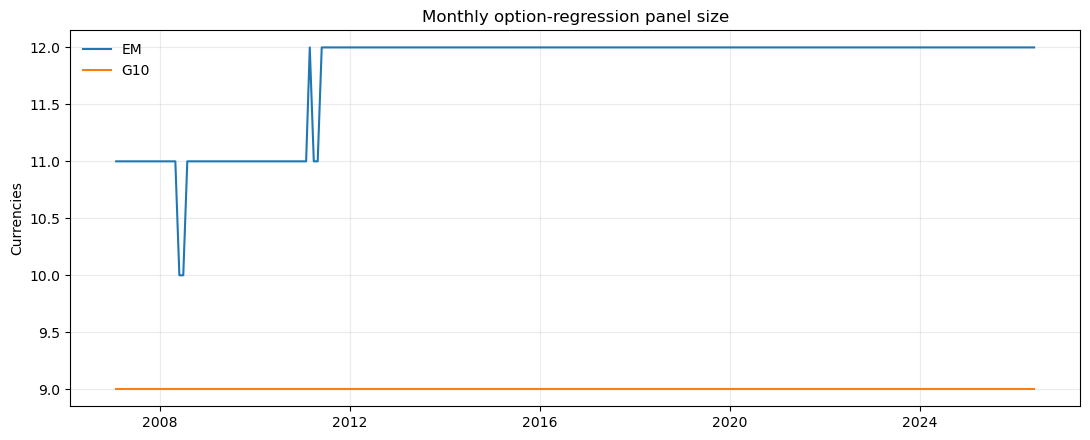

In [6]:

def month_count_between(first, last):
    if pd.isna(first) or pd.isna(last):
        return np.nan
    return len(pd.date_range(first, last, freq="ME"))

coverage_rows=[]
for (asset, ccy), sub in reg_panel.groupby(["asset_class", "currency"]):
    valid_option = sub.dropna(subset=["atm_vol_1m", "bad_skew25_1m"])
    valid_return = sub.dropna(subset=["realized_1m_forward_excess_return"])
    first = valid_option["month_end"].min() if not valid_option.empty else pd.NaT
    last = valid_option["month_end"].max() if not valid_option.empty else pd.NaT
    total_months = month_count_between(first, last)
    coverage_rows.append({
        "asset_class": asset, "currency": ccy,
        "first_option_month": first, "last_option_month": last,
        "valid_option_months": len(valid_option),
        "valid_future_return_months": len(valid_return),
        "missing_month_count": int(total_months - len(valid_option)) if pd.notna(total_months) else np.nan,
        "mean_carry": sub["carry_signal_1m"].mean(), "std_carry": sub["carry_signal_1m"].std(ddof=1),
        "mean_atm_vol": sub["atm_vol_1m"].mean(), "std_atm_vol": sub["atm_vol_1m"].std(ddof=1),
        "mean_bad_skew": sub["bad_skew25_1m"].mean(), "std_bad_skew": sub["bad_skew25_1m"].std(ddof=1),
        "mean_bf25": sub["bf25_1m"].mean(),
        "average_future_return": sub["realized_1m_forward_excess_return"].mean(),
    })
coverage_table = pd.DataFrame(coverage_rows).sort_values(["asset_class", "currency"])

def sample_summary(df, name):
    counts = df.groupby("month_end")["currency"].nunique()
    return {"sample": name, "observations": len(df), "currencies": df["currency"].nunique(), "months": df["month_end"].nunique(), "first_month": df["month_end"].min(), "last_month": df["month_end"].max(), "median_currencies_per_month": counts.median(), "min_currencies_per_month": counts.min(), "max_currencies_per_month": counts.max()}

samples = {"All": reg_panel_clean, "G10": reg_panel_clean[reg_panel_clean["asset_class"].eq("G10")], "EM": reg_panel_clean[reg_panel_clean["asset_class"].eq("EM")]}
sample_summary_table = pd.DataFrame([sample_summary(df, name) for name, df in samples.items()])
rr_direction_diagnostics = reg_panel_clean.groupby(["asset_class", "currency", "option_pair", "foreign_is_base", "rr_sign_to_foreign"], as_index=False).agg(
    avg_raw_rr=("rr25_raw_1m", "mean"), avg_foreign_rr=("rr25_foreign_1m", "mean"), avg_bad_skew=("bad_skew25_1m", "mean"), observations=("month_end", "count")
)
rr_direction_diagnostics["sign_check"] = np.where(np.sign(rr_direction_diagnostics["avg_foreign_rr"].fillna(0)) == np.sign((rr_direction_diagnostics["avg_raw_rr"] * rr_direction_diagnostics["rr_sign_to_foreign"]).fillna(0)), "mechanically consistent", "check")

display(Markdown("### Coverage by currency")); display(coverage_table.style.format({"mean_carry":"{:+.3%}", "std_carry":"{:.3%}", "mean_atm_vol":"{:.2f}", "std_atm_vol":"{:.2f}", "mean_bad_skew":"{:+.2f}", "std_bad_skew":"{:.2f}", "mean_bf25":"{:.2f}", "average_future_return":"{:+.3%}"}))
display(Markdown("### Sample summary")); display(sample_summary_table)
display(Markdown("### RR direction diagnostics")); display(rr_direction_diagnostics.style.format({"avg_raw_rr":"{:+.2f}", "avg_foreign_rr":"{:+.2f}", "avg_bad_skew":"{:+.2f}"}))

monthly_panel_size = reg_panel_clean.groupby(["month_end", "asset_class"], as_index=False).agg(currencies=("currency", "nunique"), observations=("currency", "size"))
if plt is not None:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for asset, sub in monthly_panel_size.groupby("asset_class"):
        ax.plot(sub["month_end"], sub["currencies"], label=asset)
    ax.set_title("Monthly option-regression panel size")
    ax.set_ylabel("Currencies")
    ax.grid(alpha=.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    path = FIG_DIR / "monthly_panel_size.png"; fig.savefig(path, dpi=150, bbox_inches="tight"); figure_paths.append(path); plt.show()


## Signal Standardization

Primary standardized regressions use monthly cross-sectional z-scores. Uninformative groups are not filled with zero; their standardized values are set to missing and reported in the diagnostics.

All-universe monthly z-scores are:

$$
z_{i,t}(X)
=
\frac{X_{i,t}-\bar X_t}{s_t(X)}.
$$


In [7]:

def safe_group_zscore_missing(s, min_n):
    x = pd.to_numeric(s, errors="coerce")
    valid = x.dropna()
    std = valid.std(ddof=0)
    informative = bool(len(valid) >= min_n and pd.notna(std) and std > 0)
    z = pd.Series(np.nan, index=s.index, dtype=float)
    if informative:
        z.loc[valid.index] = (valid - valid.mean()) / std
    return z, {"n_valid": len(valid), "std": std, "informative": informative}

SIGNAL_MAP = {"carry": "carry_signal_1m", "atm_vol": "atm_vol_1m", "bad_skew": "bad_skew25_1m", "bf25": "bf25_1m"}
z_panel = reg_panel_clean.copy()
z_diags=[]
for keys, sub in z_panel.groupby(["month_end"], sort=True):
    for name, col in SIGNAL_MAP.items():
        z, info = safe_group_zscore_missing(sub[col], MIN_Z_N_ALL)
        z_panel.loc[sub.index, f"z_{name}_all"] = z
        z_diags.append({"standardization": "all", "month_end": keys, "asset_class": "All", "signal": name, **info})
for keys, sub in z_panel.groupby(["month_end", "asset_class"], sort=True):
    month, asset = keys
    for name, col in SIGNAL_MAP.items():
        z, info = safe_group_zscore_missing(sub[col], MIN_Z_N_CLASS)
        z_panel.loc[sub.index, f"z_{name}_class"] = z
        z_diags.append({"standardization": "asset_class", "month_end": month, "asset_class": asset, "signal": name, **info})

for suffix in ["all", "class"]:
    z_panel[f"z_carry_x_bad_skew_{suffix}"] = z_panel[f"z_carry_{suffix}"] * z_panel[f"z_bad_skew_{suffix}"]
    z_panel[f"z_carry_x_atm_vol_{suffix}"] = z_panel[f"z_carry_{suffix}"] * z_panel[f"z_atm_vol_{suffix}"]
    z_panel[f"z_atm_vol_x_bad_skew_{suffix}"] = z_panel[f"z_atm_vol_{suffix}"] * z_panel[f"z_bad_skew_{suffix}"]
    z_panel[f"z_carry_x_atm_vol_x_bad_skew_{suffix}"] = z_panel[f"z_carry_{suffix}"] * z_panel[f"z_atm_vol_{suffix}"] * z_panel[f"z_bad_skew_{suffix}"]

z_diagnostics = pd.DataFrame(z_diags)
z_diag_summary = z_diagnostics.groupby(["standardization", "asset_class", "signal"], as_index=False).agg(groups=("informative", "size"), informative_groups=("informative", "sum"), noninformative_groups=("informative", lambda x: int((~x).sum())), avg_n_valid=("n_valid", "mean"), min_n_valid=("n_valid", "min"))
z_loss_summary = []
for name, df in {"All": z_panel, "G10": z_panel[z_panel["asset_class"].eq("G10")], "EM": z_panel[z_panel["asset_class"].eq("EM")]}.items():
    for suffix in ["all", "class"]:
        cols = [f"z_carry_{suffix}", f"z_atm_vol_{suffix}", f"z_bad_skew_{suffix}", f"z_bf25_{suffix}"]
        z_loss_summary.append({"sample": name, "standardization": suffix, "observations_before": len(df), "observations_complete_z": len(df.dropna(subset=cols)), "lost_observations": len(df) - len(df.dropna(subset=cols))})
z_loss_summary = pd.DataFrame(z_loss_summary)

display(z_diag_summary)
display(z_loss_summary)


,standardization,asset_class,signal,groups,informative_groups,noninformative_groups,avg_n_valid,min_n_valid
0,all,All,atm_vol,233,233,0,20.772532,19
1,all,All,bad_skew,233,233,0,20.772532,19
2,all,All,bf25,233,233,0,20.772532,19
3,all,All,carry,233,233,0,20.772532,19
4,asset_class,EM,atm_vol,233,233,0,11.772532,10
5,asset_class,EM,bad_skew,233,233,0,11.772532,10
6,asset_class,EM,bf25,233,233,0,11.772532,10
7,asset_class,EM,carry,233,233,0,11.772532,10
8,asset_class,G10,atm_vol,233,233,0,9.000000,9
9,asset_class,G10,bad_skew,233,233,0,9.000000,9


,sample,standardization,observations_before,observations_complete_z,lost_observations
0,All,all,4840,4840,0
1,All,class,4840,4840,0
2,G10,all,2097,2097,0
3,G10,class,2097,2097,0
4,EM,all,2743,2743,0
5,EM,class,2743,2743,0


## Descriptive Statistics and Correlations

Signal correlations are not predictive return relationships. A positive correlation between carry and bad skew, for example, does not imply that high bad skew predicts higher future returns.


In [8]:

def describe_vars(df, sample, cols, label):
    rows=[]
    for col in cols:
        x = pd.to_numeric(df[col], errors="coerce").dropna()
        rows.append({"sample": sample, "variable_set": label, "variable": col, "mean": x.mean(), "std": x.std(ddof=1), "median": x.median(), "p05": x.quantile(.05), "p25": x.quantile(.25), "p75": x.quantile(.75), "p95": x.quantile(.95), "min": x.min(), "max": x.max(), "skewness": x.skew(), "observations": len(x)})
    return pd.DataFrame(rows)

raw_vars = ["carry_signal_1m", "atm_vol_1m", "bad_skew25_1m", "bf25_1m", "realized_1m_forward_excess_return"]
z_vars = ["z_carry_all", "z_atm_vol_all", "z_bad_skew_all", "z_bf25_all", "z_carry_class", "z_atm_vol_class", "z_bad_skew_class", "z_bf25_class"]
desc_parts=[]
for sample, df in {"All": z_panel, "G10": z_panel[z_panel["asset_class"].eq("G10")], "EM": z_panel[z_panel["asset_class"].eq("EM")]}.items():
    desc_parts.append(describe_vars(df, sample, raw_vars, "raw"))
    desc_parts.append(describe_vars(df, sample, [v for v in z_vars if v in df], "monthly z-scores"))
descriptive_table = pd.concat(desc_parts, ignore_index=True)
display(descriptive_table.style.format({"mean":"{:+.4f}", "std":"{:.4f}", "median":"{:+.4f}", "p05":"{:+.4f}", "p25":"{:+.4f}", "p75":"{:+.4f}", "p95":"{:+.4f}", "min":"{:+.4f}", "max":"{:+.4f}", "skewness":"{:+.2f}"}))

corr_rows=[]
def corr_long(df, sample, cols, method, label):
    c = df[cols].corr(method=method)
    out = c.stack().reset_index()
    out.columns = ["variable_1", "variable_2", "correlation"]
    out["sample"] = sample; out["method"] = method; out["variable_set"] = label
    return out
for sample, df in {"All raw": z_panel, "G10 raw": z_panel[z_panel["asset_class"].eq("G10")], "EM raw": z_panel[z_panel["asset_class"].eq("EM")]}.items():
    for method in ["pearson", "spearman"]:
        corr_rows.append(corr_long(df, sample, raw_vars, method, "raw levels"))
for method in ["pearson", "spearman"]:
    corr_rows.append(corr_long(z_panel, "All", ["z_carry_all", "z_atm_vol_all", "z_bad_skew_all", "z_bf25_all", "realized_1m_forward_excess_return"], method, "monthly z-scores"))
correlation_table = pd.concat(corr_rows, ignore_index=True)
for sample in ["All raw", "G10 raw", "EM raw", "All"]:
    display(Markdown(f"### {sample} Pearson correlation"))
    subset = correlation_table[(correlation_table["sample"].eq(sample)) & (correlation_table["method"].eq("pearson"))]
    display(subset.pivot(index="variable_1", columns="variable_2", values="correlation").style.format("{:+.2f}"))


,sample,variable_set,variable,mean,std,median,p05,p25,p75,p95,min,max,skewness,observations
0,All,raw,carry_signal_1m,+0.0017,0.0047,+0.0004,-0.0023,-0.0006,+0.0028,+0.0081,-0.0106,+0.1062,+6.50,4840
1,All,raw,atm_vol_1m,+10.3022,5.2115,+9.3687,+4.3971,+6.9500,+12.4256,+19.0760,+1.2500,+78.3175,+2.55,4840
2,All,raw,bad_skew25_1m,+1.2552,1.7307,+0.9125,-0.5530,+0.3700,+1.7850,+3.9504,-9.2650,+20.1850,+2.89,4840
3,All,raw,bf25_1m,+0.3369,0.2725,+0.2650,+0.1175,+0.1900,+0.3825,+0.7675,-0.0100,+3.2750,+4.01,4840
4,All,raw,realized_1m_forward_excess_return,-0.0002,0.0323,+0.0012,-0.0508,-0.0170,+0.0174,+0.0494,-0.3242,+0.1430,-0.80,4840
5,All,monthly z-scores,z_carry_all,+0.0000,1.0001,-0.3170,-1.0217,-0.6101,+0.3064,+2.0814,-2.3790,+4.4262,+1.80,4840
6,All,monthly z-scores,z_atm_vol_all,+0.0000,1.0001,-0.0480,-1.5620,-0.6617,+0.5484,+1.8142,-2.7687,+4.3741,+0.42,4840
7,All,monthly z-scores,z_bad_skew_all,-0.0000,1.0001,-0.1935,-1.4045,-0.5436,+0.4492,+1.8080,-3.0227,+4.2953,+0.93,4840
8,All,monthly z-scores,z_bf25_all,+0.0000,1.0001,-0.3030,-1.0422,-0.6337,+0.3693,+1.9270,-2.2085,+4.4372,+1.73,4840
9,All,monthly z-scores,z_carry_class,+0.0000,1.0001,-0.1624,-1.3086,-0.7260,+0.6047,+1.8702,-2.3861,+3.2919,+0.71,4840


### All raw Pearson correlation

variable_2,atm_vol_1m,bad_skew25_1m,bf25_1m,carry_signal_1m,realized_1m_forward_excess_return
variable_1,,,,,
atm_vol_1m,+1.00,+0.65,+0.68,+0.39,+0.05
bad_skew25_1m,+0.65,+1.00,+0.80,+0.66,+0.04
bf25_1m,+0.68,+0.80,+1.00,+0.63,+0.05
carry_signal_1m,+0.39,+0.66,+0.63,+1.00,+0.03
realized_1m_forward_excess_return,+0.05,+0.04,+0.05,+0.03,+1.00


### G10 raw Pearson correlation

variable_2,atm_vol_1m,bad_skew25_1m,bf25_1m,carry_signal_1m,realized_1m_forward_excess_return
variable_1,,,,,
atm_vol_1m,+1.00,+0.35,+0.73,+0.36,+0.06
bad_skew25_1m,+0.35,+1.00,+0.31,+0.54,+0.04
bf25_1m,+0.73,+0.31,+1.00,+0.23,+0.08
carry_signal_1m,+0.36,+0.54,+0.23,+1.00,-0.00
realized_1m_forward_excess_return,+0.06,+0.04,+0.08,-0.00,+1.00


### EM raw Pearson correlation

variable_2,atm_vol_1m,bad_skew25_1m,bf25_1m,carry_signal_1m,realized_1m_forward_excess_return
variable_1,,,,,
atm_vol_1m,+1.00,+0.76,+0.71,+0.41,+0.04
bad_skew25_1m,+0.76,+1.00,+0.86,+0.63,+0.04
bf25_1m,+0.71,+0.86,+1.00,+0.62,+0.04
carry_signal_1m,+0.41,+0.63,+0.62,+1.00,+0.03
realized_1m_forward_excess_return,+0.04,+0.04,+0.04,+0.03,+1.00


### All Pearson correlation

variable_2,realized_1m_forward_excess_return,z_atm_vol_all,z_bad_skew_all,z_bf25_all,z_carry_all
variable_1,,,,,
realized_1m_forward_excess_return,+1.00,+0.02,+0.02,+0.01,+0.03
z_atm_vol_all,+0.02,+1.00,+0.61,+0.57,+0.48
z_bad_skew_all,+0.02,+0.61,+1.00,+0.74,+0.76
z_bf25_all,+0.01,+0.57,+0.74,+1.00,+0.66
z_carry_all,+0.03,+0.48,+0.76,+0.66,+1.00


## Time-Series and Cross-Sectional Plots

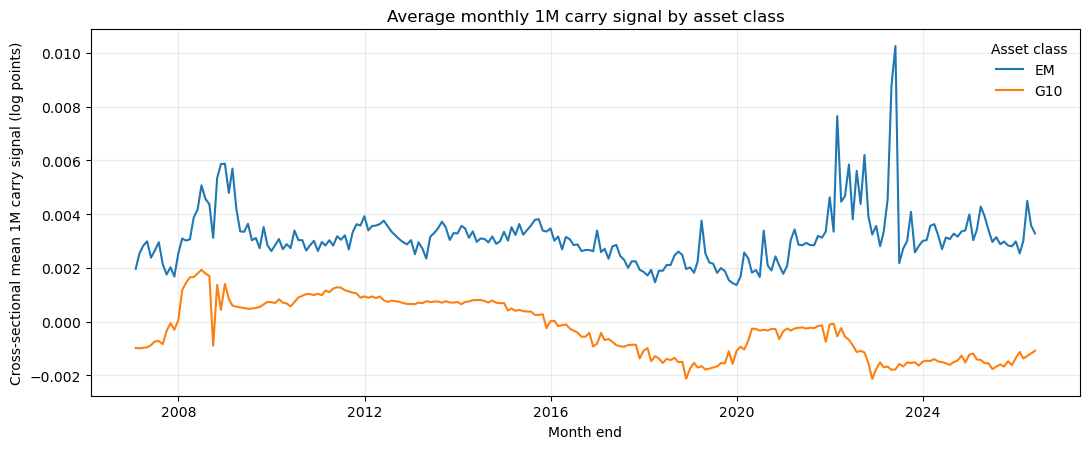

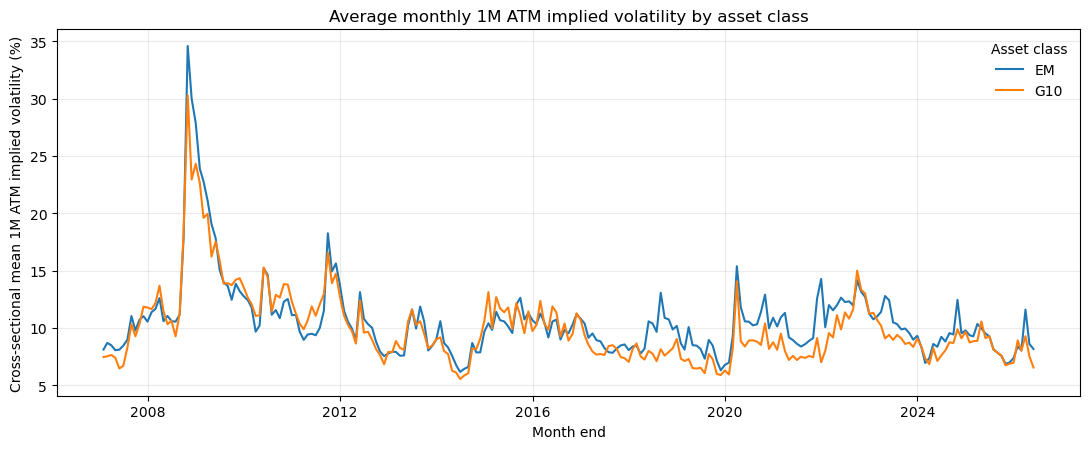

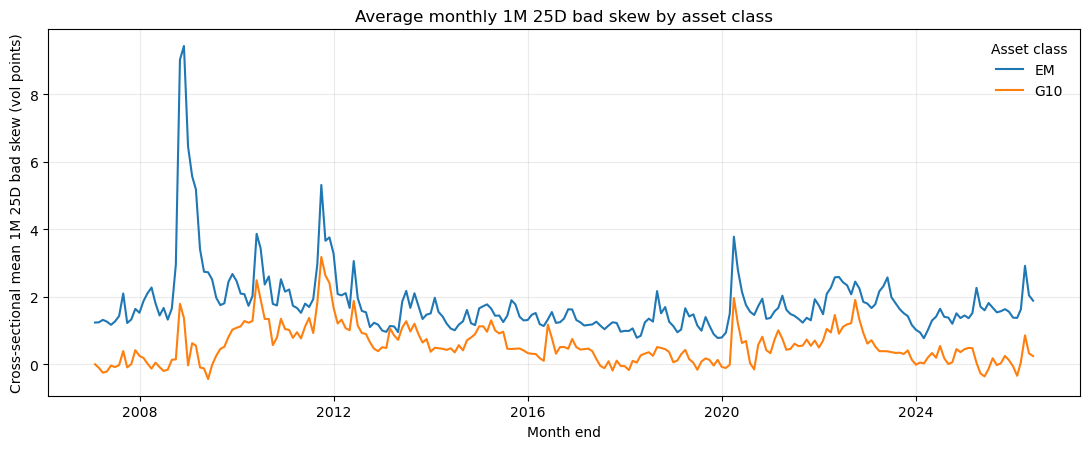

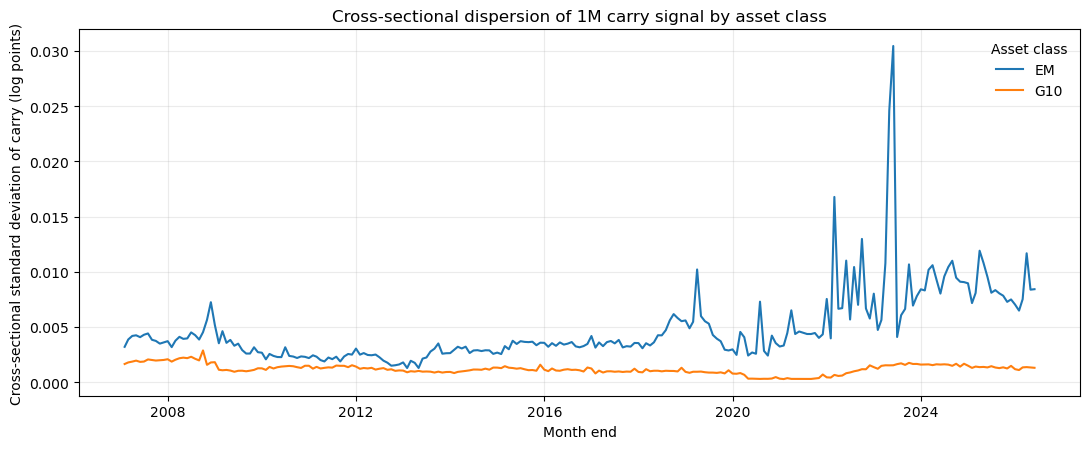

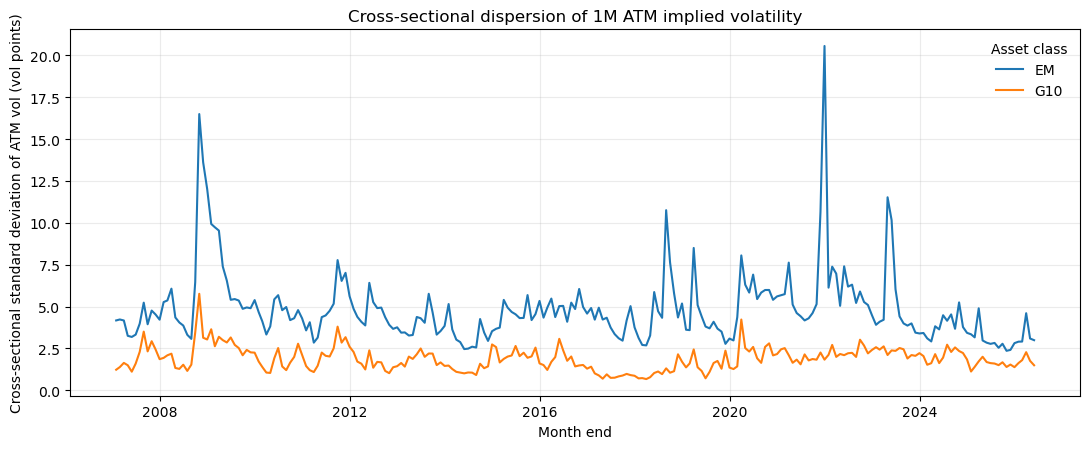

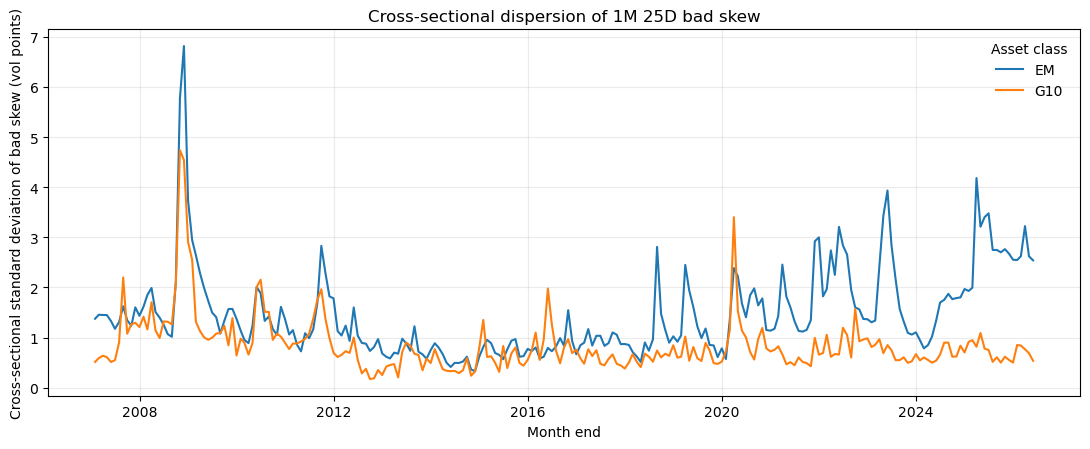

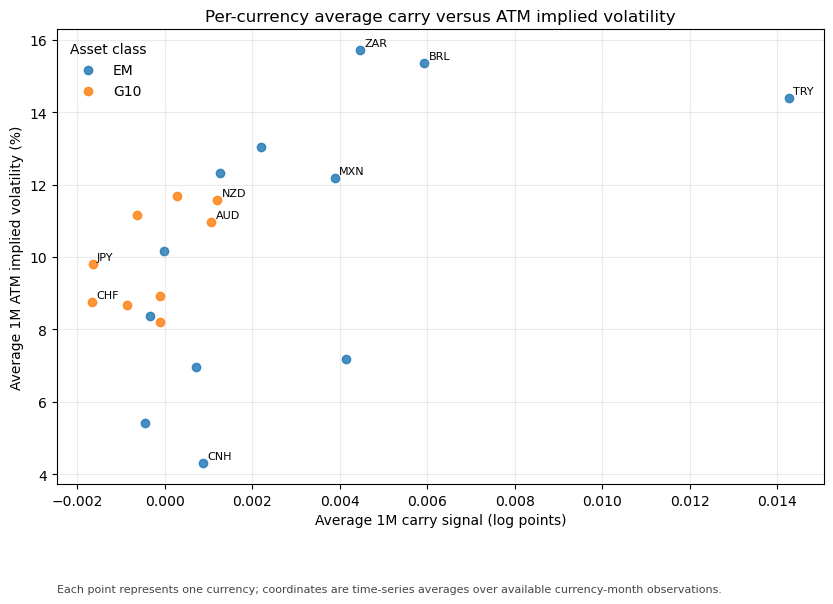

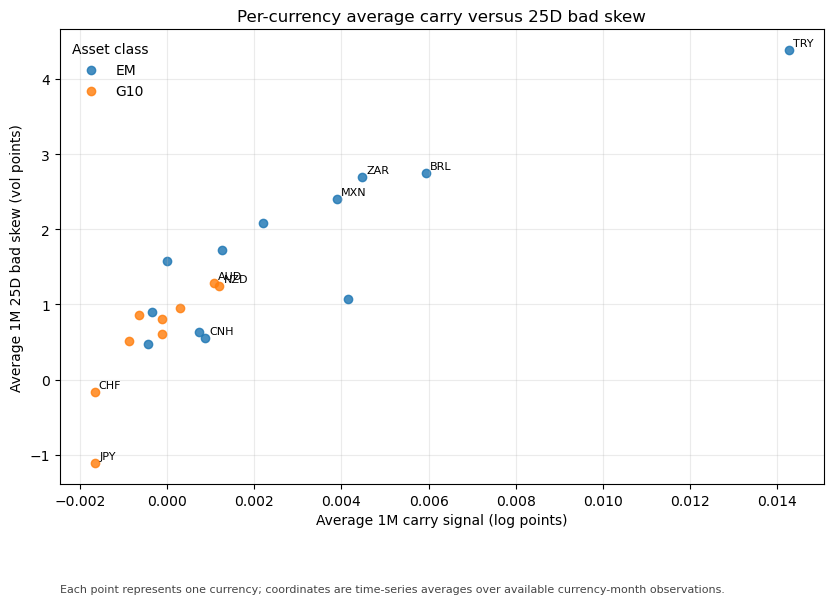

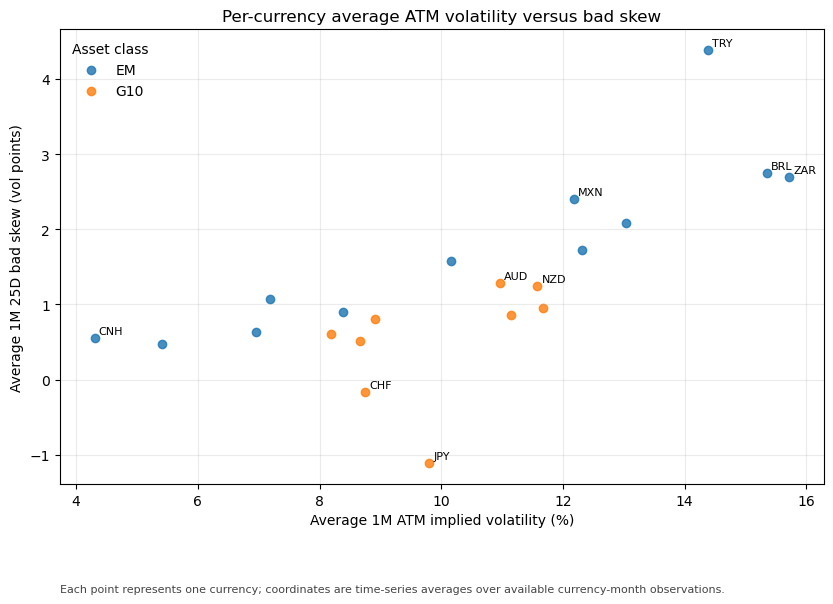

In [9]:

if plt is not None:
    asset_month = z_panel.groupby(["month_end", "asset_class"], as_index=False).agg(
        avg_carry=("carry_signal_1m", "mean"),
        avg_atm_vol=("atm_vol_1m", "mean"),
        avg_bad_skew=("bad_skew25_1m", "mean"),
        disp_carry=("carry_signal_1m", "std"),
        disp_atm_vol=("atm_vol_1m", "std"),
        disp_bad_skew=("bad_skew25_1m", "std"),
    )
    plot_specs = [
        ("avg_carry", "Average monthly 1M carry signal by asset class", "Month end", "Cross-sectional mean 1M carry signal (log points)"),
        ("avg_atm_vol", "Average monthly 1M ATM implied volatility by asset class", "Month end", "Cross-sectional mean 1M ATM implied volatility (%)"),
        ("avg_bad_skew", "Average monthly 1M 25D bad skew by asset class", "Month end", "Cross-sectional mean 1M 25D bad skew (vol points)"),
        ("disp_carry", "Cross-sectional dispersion of 1M carry signal by asset class", "Month end", "Cross-sectional standard deviation of carry (log points)"),
        ("disp_atm_vol", "Cross-sectional dispersion of 1M ATM implied volatility", "Month end", "Cross-sectional standard deviation of ATM vol (vol points)"),
        ("disp_bad_skew", "Cross-sectional dispersion of 1M 25D bad skew", "Month end", "Cross-sectional standard deviation of bad skew (vol points)"),
    ]
    for col, title, xlabel, ylabel in plot_specs:
        fig, ax = plt.subplots(figsize=(11, 4.6))
        for asset, sub in asset_month.groupby("asset_class"):
            ax.plot(sub["month_end"], sub[col], label=asset)
        finalize_axis(ax, title=title, xlabel=xlabel, ylabel=ylabel)
        ax.legend(title="Asset class", frameon=False)
        plt.tight_layout(); savefig(fig, f"{col}_by_asset_class.png"); plt.show()

    avg_ccy = z_panel.groupby(["asset_class", "currency"], as_index=False).agg(
        avg_carry=("carry_signal_1m", "mean"),
        avg_atm_vol=("atm_vol_1m", "mean"),
        avg_bad_skew=("bad_skew25_1m", "mean"),
        avg_bf25=("bf25_1m", "mean"),
        avg_return=("realized_1m_forward_excess_return", "mean"),
    )
    scatters = [
        ("avg_carry", "avg_atm_vol", "Per-currency average carry versus ATM implied volatility", "Average 1M carry signal (log points)", "Average 1M ATM implied volatility (%)"),
        ("avg_carry", "avg_bad_skew", "Per-currency average carry versus 25D bad skew", "Average 1M carry signal (log points)", "Average 1M 25D bad skew (vol points)"),
        ("avg_atm_vol", "avg_bad_skew", "Per-currency average ATM volatility versus bad skew", "Average 1M ATM implied volatility (%)", "Average 1M 25D bad skew (vol points)"),
    ]
    scatter_note = "Each point represents one currency; coordinates are time-series averages over available currency-month observations."
    for xcol, ycol, title, xlabel, ylabel in scatters:
        fig, ax = plt.subplots(figsize=(8.5, 6.2))
        for asset, sub in avg_ccy.groupby("asset_class"):
            ax.scatter(sub[xcol], sub[ycol], label=asset, alpha=.82)
            for _, row in sub.iterrows():
                if row["currency"] in ["TRY", "BRL", "ZAR", "MXN", "JPY", "CHF", "AUD", "NZD", "CNH"]:
                    ax.annotate(row["currency"], (row[xcol], row[ycol]), fontsize=8, xytext=(3,3), textcoords="offset points")
        finalize_axis(ax, title=title, xlabel=xlabel, ylabel=ylabel, note=scatter_note)
        ax.legend(title="Asset class", frameon=False)
        plt.tight_layout(); savefig(fig, f"scatter_{xcol}_vs_{ycol}.png"); plt.show()
else:
    display(Markdown("Plots skipped because matplotlib is unavailable."))


## Conditional-Sort Analysis

The conditional-sort analysis is nonparametric. It asks whether future returns differ across carry, volatility, skew, and butterfly buckets before imposing a linear regression structure.


,sample,ranking_version,row_quantile,column_quantile,mean_future_return,median_future_return,std_future_return,hit_rate,skewness,worst_observation,observations,unique_months,unique_currencies,row_q,col_q,sufficient_cell,table
0,All,global monthly quintiles,1,1,+0.04%,-0.00%,2.13%,49.8%,0.470400,-8.21%,303,192,10,q_carry_global,q_vol_global,True,carry_x_vol
1,All,global monthly quintiles,1,2,-0.18%,-0.15%,2.43%,48.1%,-0.075435,-8.40%,391,216,12,q_carry_global,q_vol_global,True,carry_x_vol
2,All,global monthly quintiles,1,3,+0.06%,+0.07%,2.98%,50.6%,0.095821,-10.51%,249,177,11,q_carry_global,q_vol_global,True,carry_x_vol
3,All,global monthly quintiles,1,4,-0.65%,-0.40%,2.92%,42.4%,-0.364732,-8.90%,139,117,10,q_carry_global,q_vol_global,True,carry_x_vol
4,All,global monthly quintiles,1,5,-2.02%,-1.70%,5.94%,31.2%,0.487064,-13.48%,32,32,4,q_carry_global,q_vol_global,True,carry_x_vol
5,All,global monthly quintiles,2,1,-0.25%,-0.02%,2.11%,49.4%,-0.934084,-13.22%,253,174,10,q_carry_global,q_vol_global,True,carry_x_vol
6,All,global monthly quintiles,2,2,+0.18%,+0.18%,2.71%,52.2%,-0.070297,-9.06%,224,168,11,q_carry_global,q_vol_global,True,carry_x_vol
7,All,global monthly quintiles,2,3,-0.32%,-0.25%,3.04%,46.5%,-0.203382,-11.71%,200,152,13,q_carry_global,q_vol_global,True,carry_x_vol
8,All,global monthly quintiles,2,4,-0.16%,+0.16%,3.31%,52.5%,-0.445158,-14.24%,221,164,12,q_carry_global,q_vol_global,True,carry_x_vol
9,All,global monthly quintiles,2,5,-0.27%,-0.56%,3.36%,41.2%,0.187265,-8.46%,34,34,6,q_carry_global,q_vol_global,True,carry_x_vol


### Conditional-sort difference tests

,sample,difference,mean_difference,newey_west_t,months
0,All global,CarryQ5 SkewQ1 minus CarryQ5 SkewQ5,+1.87%,+3.11,11
1,All global,CarryQ5 VolQ1 minus CarryQ5 VolQ5,+0.23%,+0.54,82
2,All class,CarryQ5 SkewQ1 minus CarryQ5 SkewQ5,+0.22%,+0.55,19
3,All class,CarryQ5 VolQ1 minus CarryQ5 VolQ5,-0.80%,-1.45,46
4,G10 class,CarryQ5 SkewQ1 minus CarryQ5 SkewQ5,+nan%,+nan,0
5,G10 class,CarryQ5 VolQ1 minus CarryQ5 VolQ5,+0.01%,+0.01,16
6,EM class,CarryQ5 SkewQ1 minus CarryQ5 SkewQ5,-0.12%,-0.17,16
7,EM class,CarryQ5 VolQ1 minus CarryQ5 VolQ5,-1.71%,-2.02,14


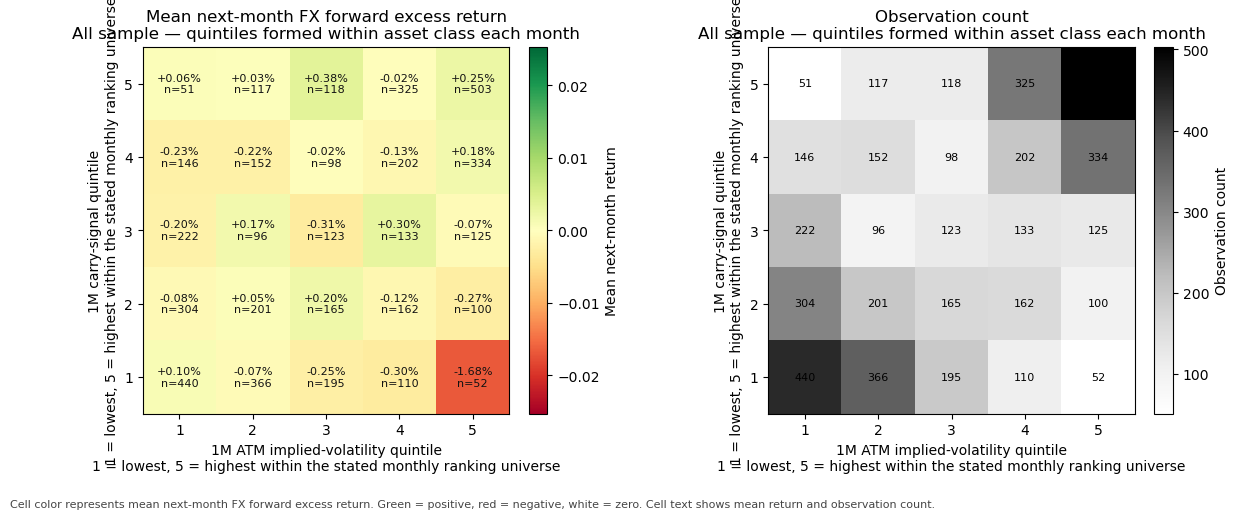

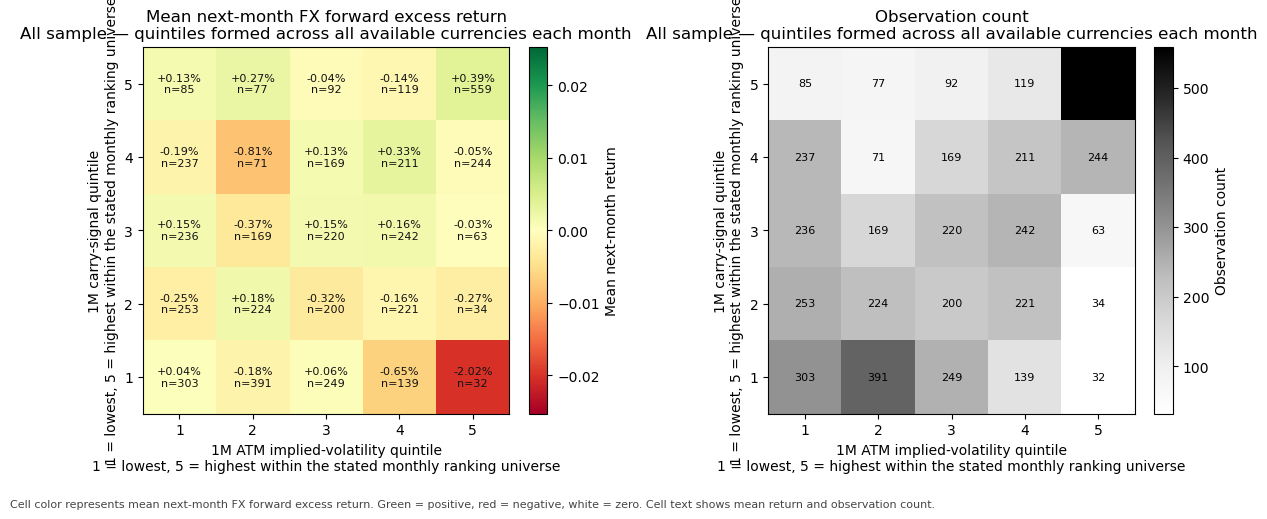

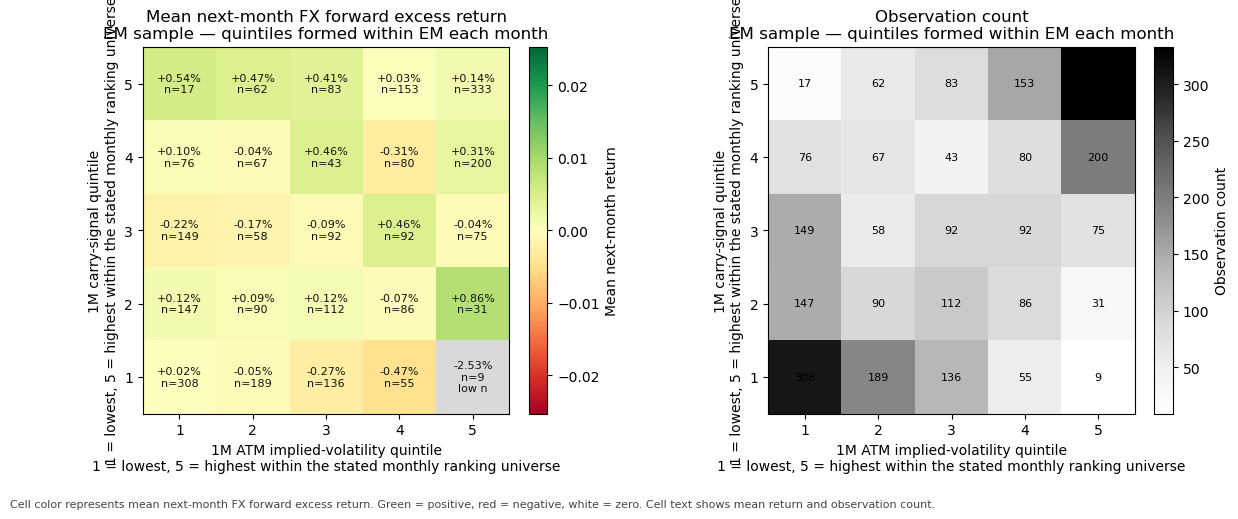

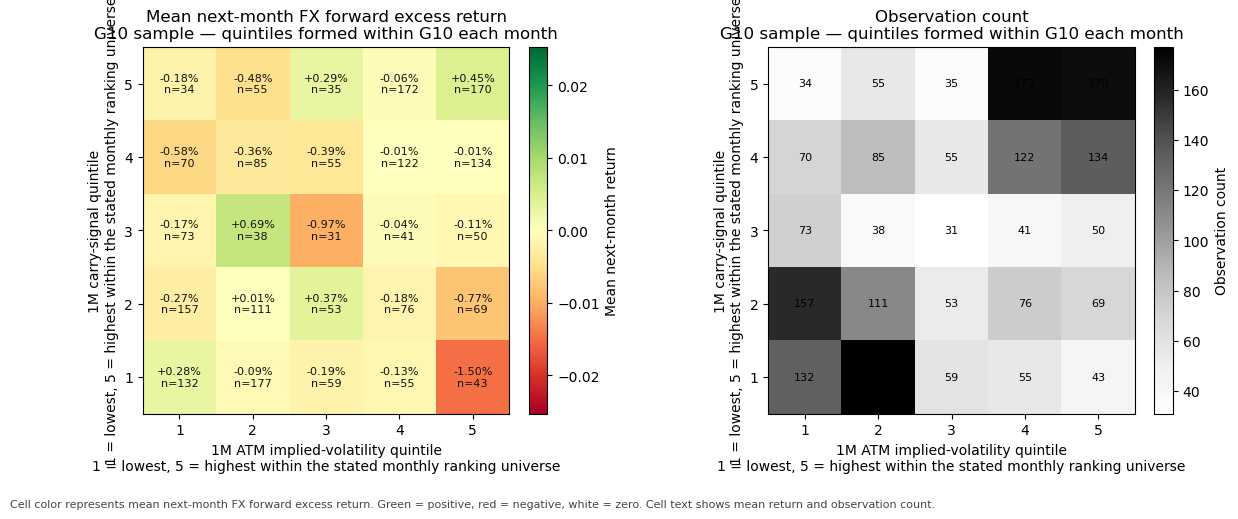

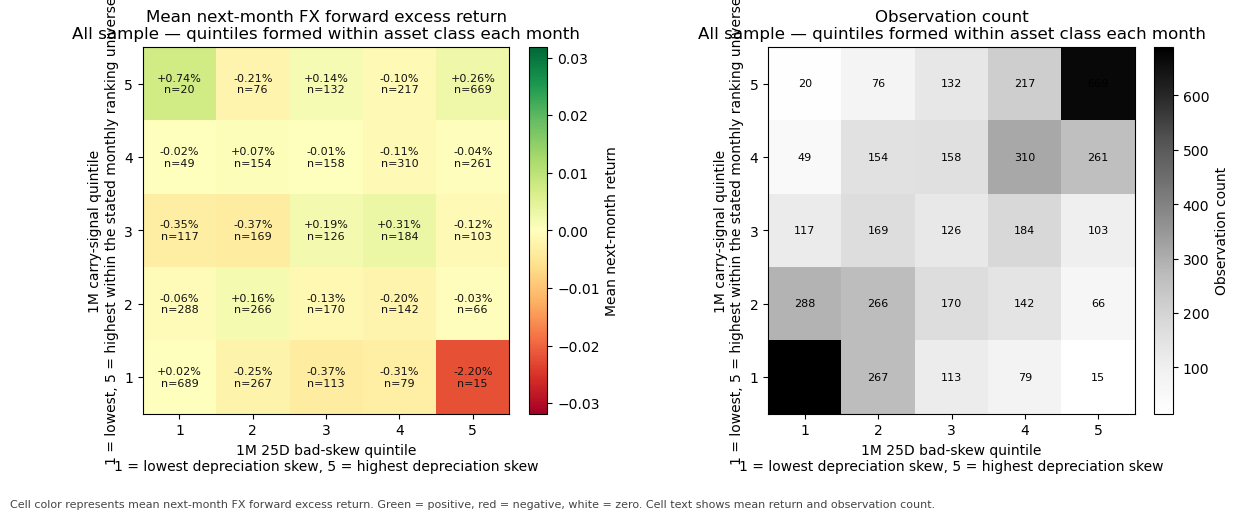

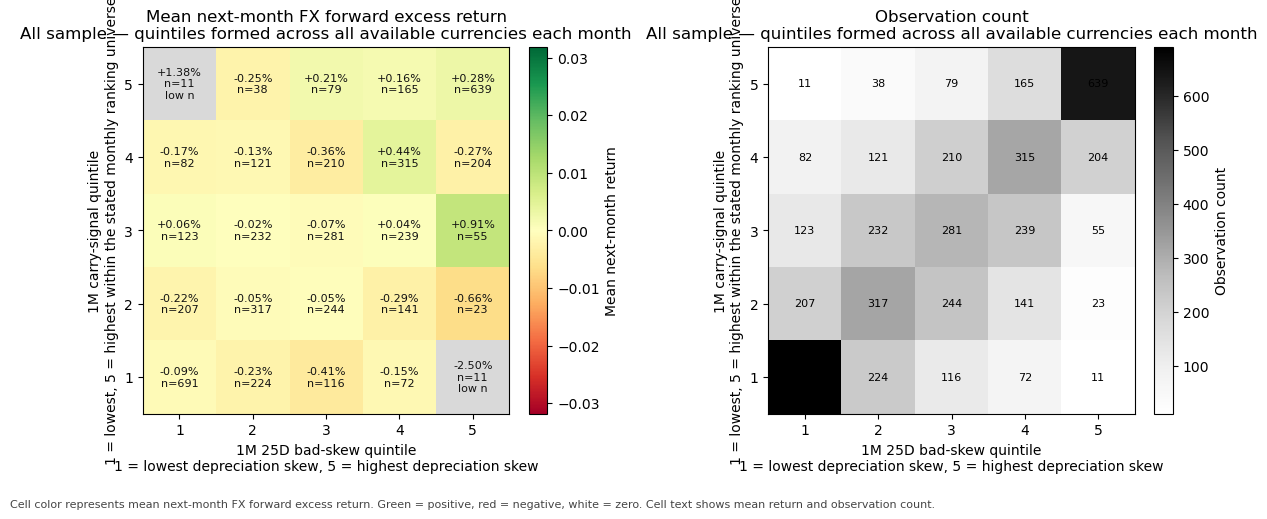

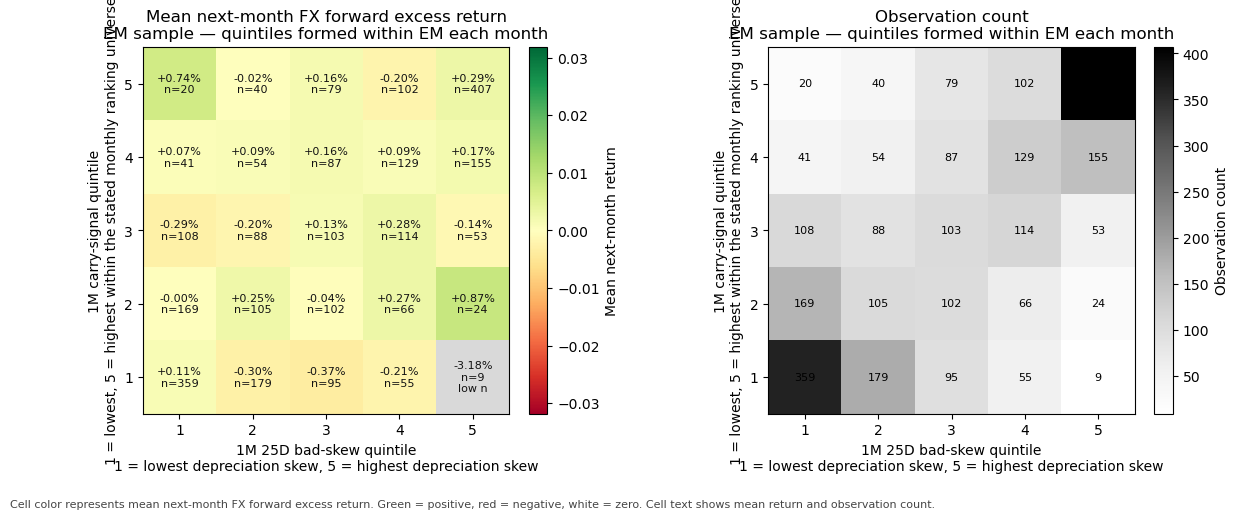

/var/folders/zs/t66fm21n3rndqc_bp6z244200000gn/T/ipykernel_19137/2385045924.py:89: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sufficient = sub.pivot(index="row_quantile", columns="column_quantile", values="sufficient_cell").sort_index(ascending=False).reindex_like(piv).fillna(False)


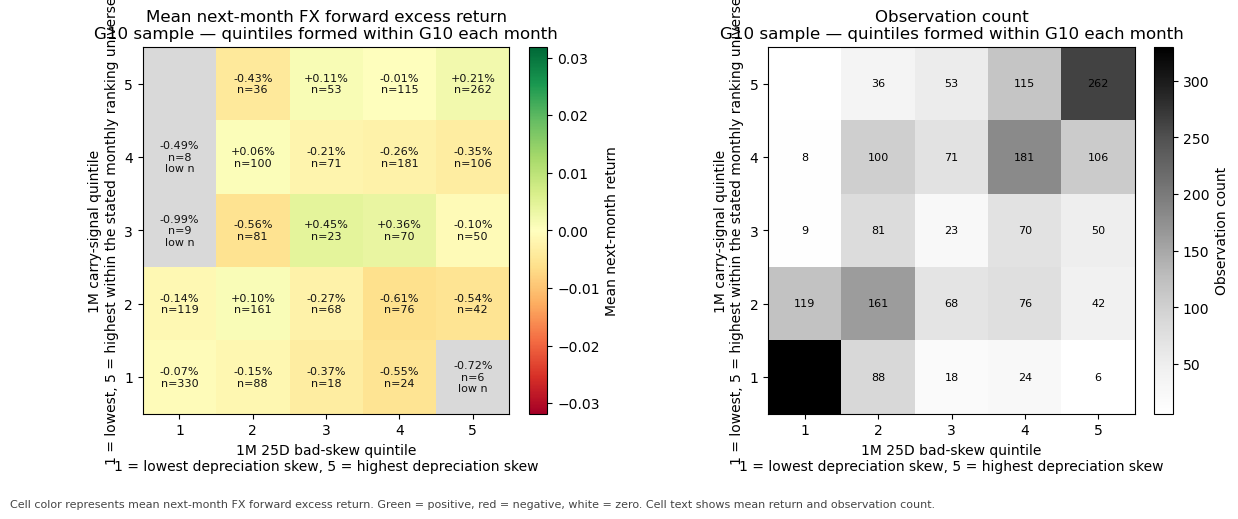

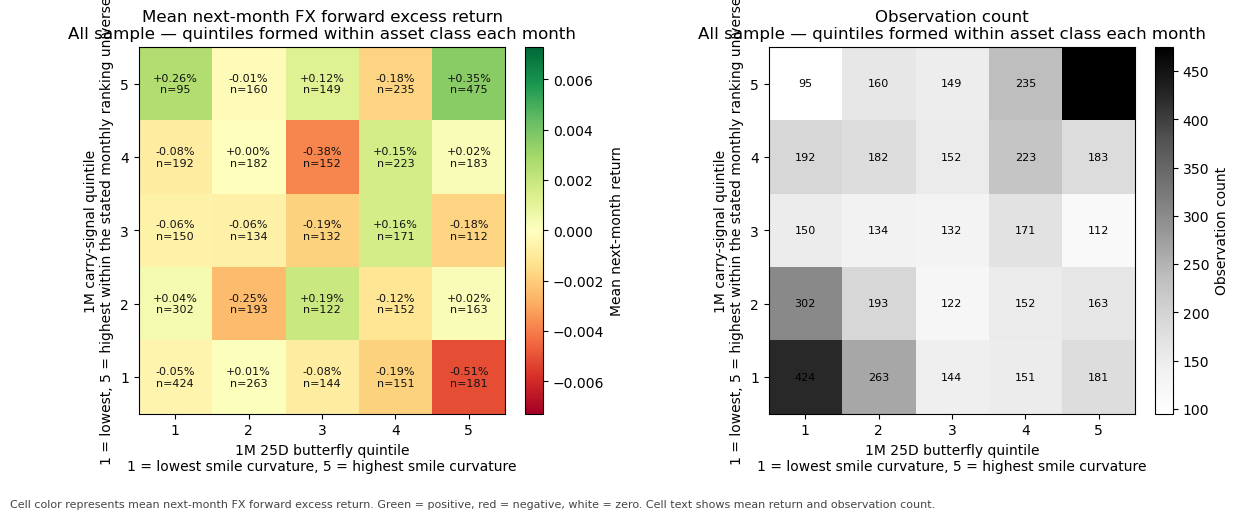

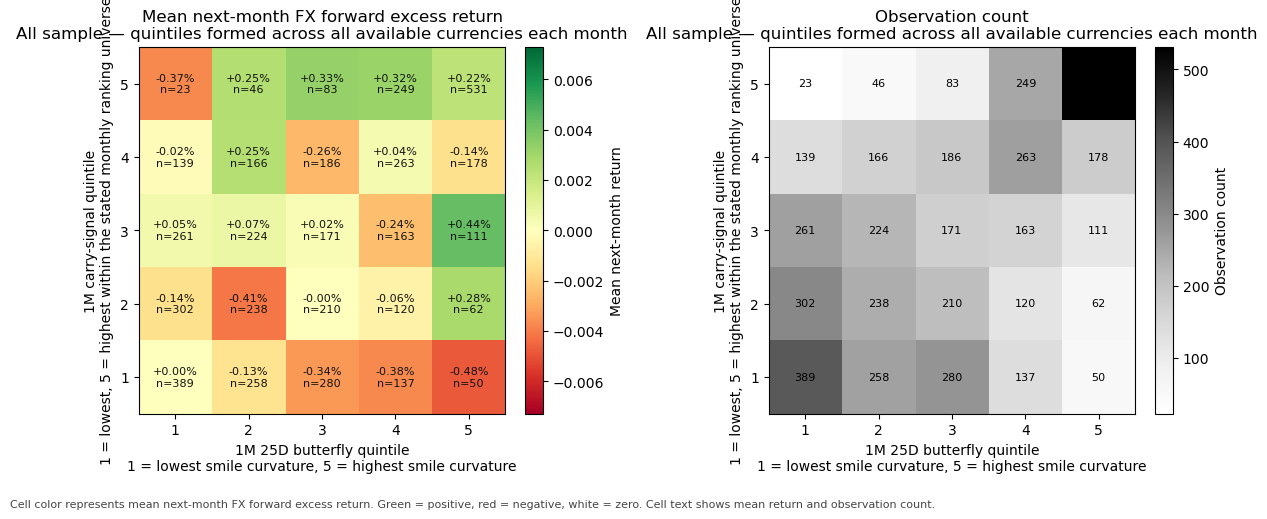

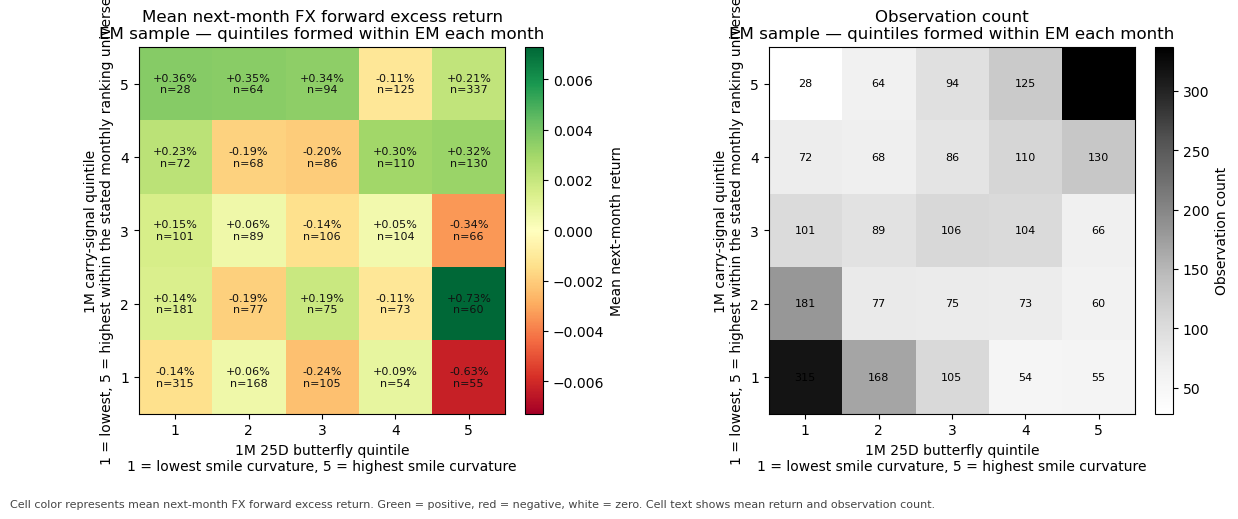

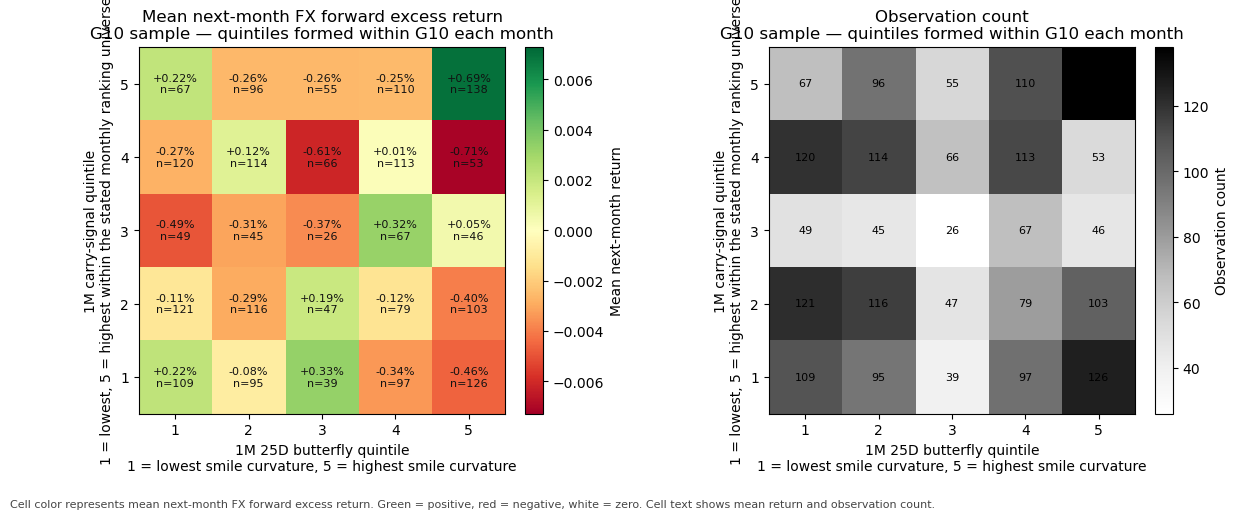

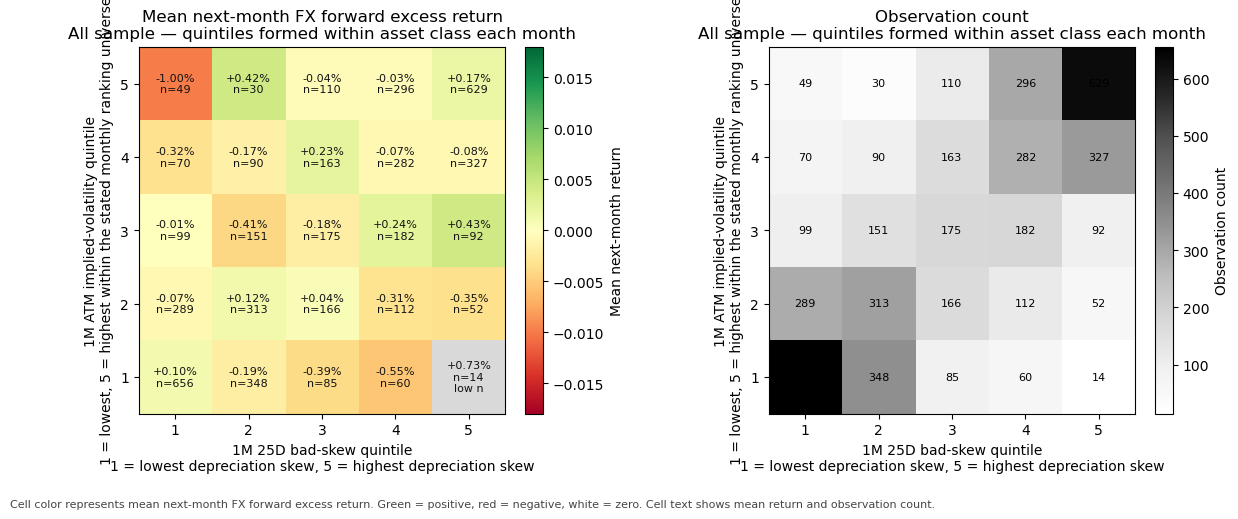

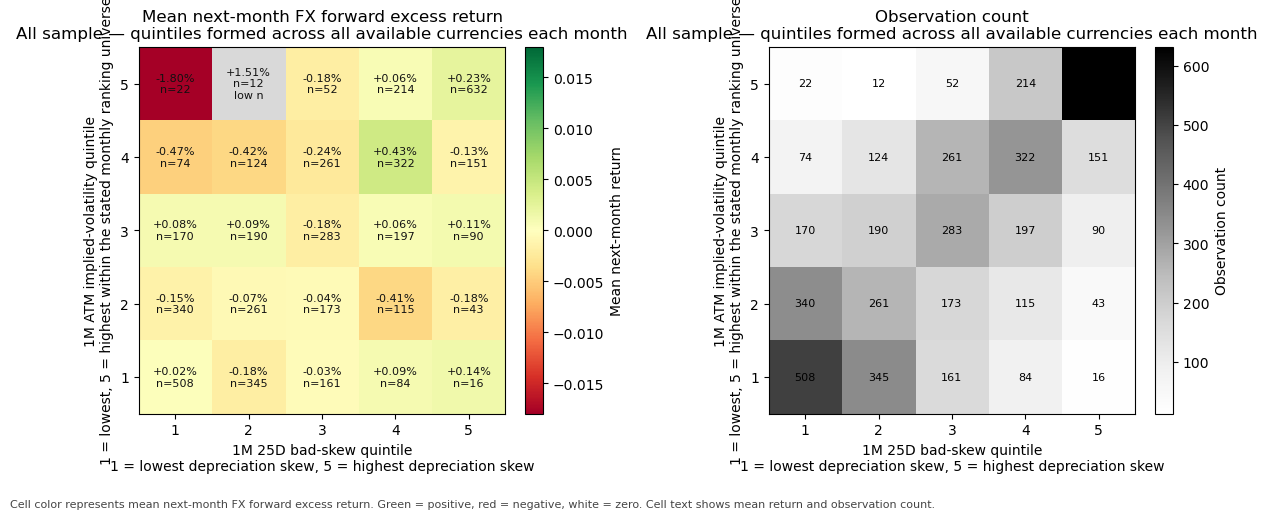

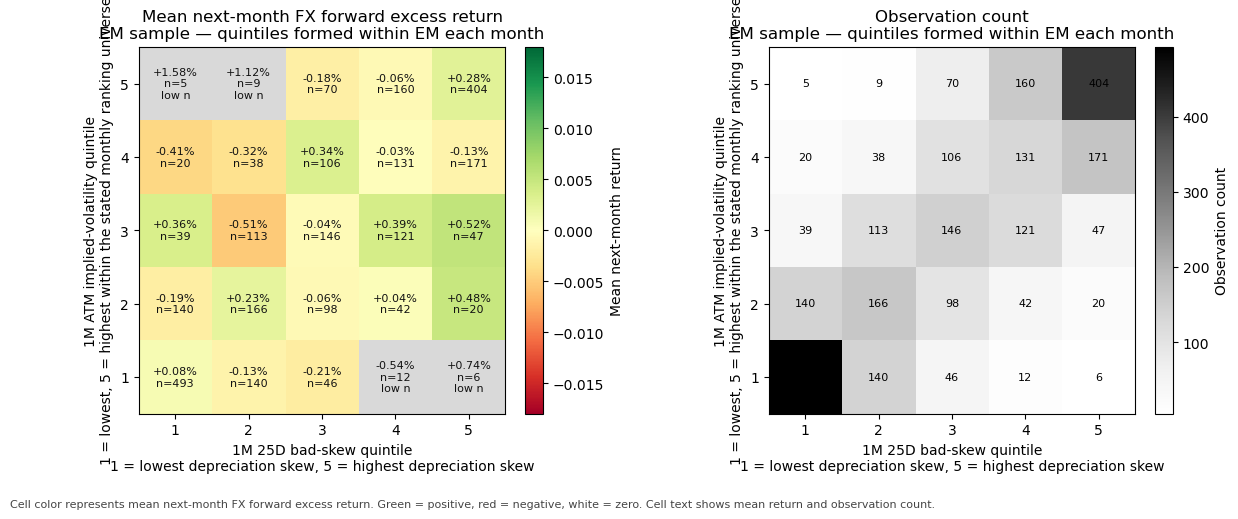

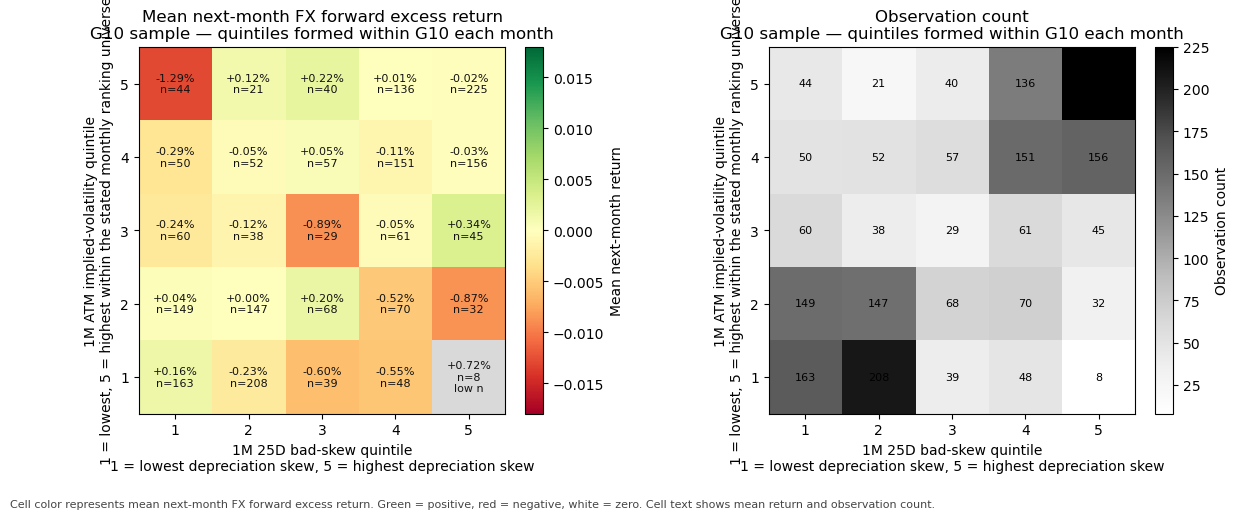

In [10]:

def assign_quintiles(df, col, group_cols, out_col):
    out = df.copy()
    out[out_col] = np.nan
    for _, sub in out.groupby(group_cols, sort=True):
        x = sub[col].dropna()
        if len(x) < 5 or x.nunique() < 5:
            continue
        try:
            q = pd.qcut(x.rank(method="first"), 5, labels=[1,2,3,4,5])
            out.loc[x.index, out_col] = q.astype(float)
        except Exception:
            continue
    return out

cond_panel = z_panel.copy()
for col, short in [("carry_signal_1m", "carry"), ("atm_vol_1m", "vol"), ("bad_skew25_1m", "skew"), ("bf25_1m", "bf25")]:
    cond_panel = assign_quintiles(cond_panel, col, ["month_end"], f"q_{short}_global")
    cond_panel = assign_quintiles(cond_panel, col, ["month_end", "asset_class"], f"q_{short}_class")


def cell_stats(df, row_q, col_q, sample, ranking_version):
    rows=[]
    d = df.dropna(subset=[row_q, col_q, "realized_1m_forward_excess_return"])
    for (rq, cq), sub in d.groupby([row_q, col_q], sort=True):
        r = sub["realized_1m_forward_excess_return"]
        rows.append({"sample": sample, "ranking_version": ranking_version, "row_quantile": int(rq), "column_quantile": int(cq), "mean_future_return": r.mean(), "median_future_return": r.median(), "std_future_return": r.std(ddof=1), "hit_rate": (r>0).mean(), "skewness": r.skew(), "worst_observation": r.min(), "observations": len(r), "unique_months": sub["month_end"].nunique(), "unique_currencies": sub["currency"].nunique(), "row_q": row_q, "col_q": col_q, "sufficient_cell": len(r) >= MIN_CELL_OBS and sub["month_end"].nunique() >= MIN_CELL_MONTHS})
    return pd.DataFrame(rows)

heatmap_tables=[]
for sample, df in {"All": cond_panel, "G10": cond_panel[cond_panel["asset_class"].eq("G10")], "EM": cond_panel[cond_panel["asset_class"].eq("EM")]}.items():
    versions = ["global"] if sample == "All" else []
    versions.append("class")
    for version in versions:
        suffix = "global" if version == "global" else "class"
        pairs = [("carry", "vol"), ("carry", "skew"), ("carry", "bf25"), ("vol", "skew")]
        for a,b in pairs:
            t = cell_stats(df, f"q_{a}_{suffix}", f"q_{b}_{suffix}", sample, "global monthly quintiles" if version=="global" else "asset-class monthly quintiles")
            t["table"] = f"{a}_x_{b}"
            heatmap_tables.append(t)
conditional_returns = pd.concat(heatmap_tables, ignore_index=True) if heatmap_tables else pd.DataFrame()
heatmap_cells = conditional_returns.copy()
display(conditional_returns.head(80).style.format({"mean_future_return":"{:+.2%}", "median_future_return":"{:+.2%}", "std_future_return":"{:.2%}", "hit_rate":"{:.1%}", "worst_observation":"{:+.2%}"}))

# Difference tests: high-carry low-risk minus high-carry high-risk.
def nw_tstat(x, lag=3):
    x = pd.Series(x).dropna().astype(float)
    if len(x) <= 3:
        return np.nan
    u = x - x.mean(); n = len(u)
    gamma0 = float(np.sum(u*u) / n); var = gamma0
    for l in range(1, min(lag, n-1)+1):
        gamma = float(np.sum(u.iloc[l:].to_numpy() * u.iloc[:-l].to_numpy()) / n)
        var += 2 * (1 - l/(lag+1)) * gamma
    se = math.sqrt(max(var / n, 0.0))
    return x.mean() / se if se > 0 else np.nan

diff_rows=[]
for sample, df in {"All global": cond_panel, "All class": cond_panel, "G10 class": cond_panel[cond_panel["asset_class"].eq("G10")], "EM class": cond_panel[cond_panel["asset_class"].eq("EM")]}.items():
    suffix = "global" if sample == "All global" else "class"
    for signal, label in [("skew", "CarryQ5 SkewQ1 minus CarryQ5 SkewQ5"), ("vol", "CarryQ5 VolQ1 minus CarryQ5 VolQ5")]:
        low = df[(df[f"q_carry_{suffix}"].eq(5)) & (df[f"q_{signal}_{suffix}"].eq(1))].groupby("month_end")["realized_1m_forward_excess_return"].mean()
        high = df[(df[f"q_carry_{suffix}"].eq(5)) & (df[f"q_{signal}_{suffix}"].eq(5))].groupby("month_end")["realized_1m_forward_excess_return"].mean()
        common = low.index.intersection(high.index)
        d = low.loc[common] - high.loc[common]
        diff_rows.append({"sample": sample, "difference": label, "mean_difference": d.mean(), "newey_west_t": nw_tstat(d), "months": len(d)})
conditional_difference_tests = pd.DataFrame(diff_rows)
display(Markdown("### Conditional-sort difference tests")); display(conditional_difference_tests.style.format({"mean_difference":"{:+.2%}", "newey_west_t":"{:+.2f}"}))


if plt is not None and not heatmap_cells.empty:
    # Shared symmetric limits by comparable table family.
    family_limits = heatmap_cells.groupby("table")["mean_future_return"].apply(lambda s: symmetric_limit(s.to_numpy())).to_dict()
    for table in ["carry_x_vol", "carry_x_skew", "carry_x_bf25", "vol_x_skew"]:
        sub = heatmap_cells[heatmap_cells["table"].eq(table)]
        if sub.empty:
            continue
        for (sample, ranking_version), _ in sub.groupby(["sample", "ranking_version"]):
            safe_sample = str(sample).replace("+", "plus").replace(" ", "_")
            safe_rank = str(ranking_version).replace(" ", "_").replace("-", "_")
            plot_return_heatmap_from_cells(
                heatmap_cells,
                table=table,
                sample=sample,
                ranking_version=ranking_version,
                output_name=f"heatmap_return_{table}_{safe_sample}_{safe_rank}.png",
                shared_limit=family_limits.get(table),
            )
    successful_sections.append("zero-centered red-white-green conditional-return heatmaps")


## Regression Architecture

The dependent variable is `realized_1m_forward_excess_return`. Standardized models are the main presentation, with raw-level models retained as benchmarks.

The primary interaction model is M4:

$$
r_{i,t+1}
=
\alpha
+
\beta_C C_{i,t}
+
\beta_V V_{i,t}
+
\beta_S S_{i,t}
+
\beta_{CS}C_{i,t}S_{i,t}
+
\beta_{CV}C_{i,t}V_{i,t}
+
\varepsilon_{i,t+1}.
$$

With centered z-scores, $\beta_C$ is the carry slope when option signals are at their monthly mean. Interaction coefficients show how the carry slope changes as option signals move.

A coefficient significant under iid OLS but not under two-way clustering is not treated as robust evidence.


In [11]:

Y_COL = "realized_1m_forward_excess_return"
PREFERRED_TERMS = ["carry", "atm_vol", "bad_skew", "carry_x_atm_vol", "carry_x_bad_skew", "atm_vol_x_bad_skew", "carry_x_atm_vol_x_bad_skew"]

MODEL_TERMS = {
    "M0 carry only": ["carry"],
    "M1 main effects": ["carry", "atm_vol", "bad_skew"],
    "M2 carry x bad skew": ["carry", "atm_vol", "bad_skew", "carry_x_bad_skew"],
    "M3 carry x ATM vol": ["carry", "atm_vol", "bad_skew", "carry_x_atm_vol"],
    "M4 both carry interactions": ["carry", "atm_vol", "bad_skew", "carry_x_atm_vol", "carry_x_bad_skew"],
    "M5 pairwise interactions": ["carry", "atm_vol", "bad_skew", "carry_x_atm_vol", "carry_x_bad_skew", "atm_vol_x_bad_skew"],
    "M6 three-way exploratory": ["carry", "atm_vol", "bad_skew", "carry_x_atm_vol", "carry_x_bad_skew", "atm_vol_x_bad_skew", "carry_x_atm_vol_x_bad_skew"],
}


def add_design_columns(df, suffix=None, raw=False, rank=False):
    out = df.copy()
    if rank:
        # Ranks are computed monthly and scaled to [-0.5, 0.5].
        for base, col in SIGNAL_MAP.items():
            out[f"r_{base}"] = out.groupby("month_end")[col].transform(lambda s: (s.rank(method="average", pct=True) - 0.5) if s.notna().sum() >= 3 else np.nan)
        prefix = "r_"
    elif raw:
        out["raw_carry"] = out["carry_signal_1m"]
        out["raw_atm_vol"] = out["atm_vol_1m"]
        out["raw_bad_skew"] = out["bad_skew25_1m"]
        out["raw_bf25"] = out["bf25_1m"]
        prefix = "raw_"
    else:
        prefix = f"z_"
    if raw:
        c, v, s = "raw_carry", "raw_atm_vol", "raw_bad_skew"
    elif rank:
        c, v, s = "r_carry", "r_atm_vol", "r_bad_skew"
    else:
        c, v, s = f"z_carry_{suffix}", f"z_atm_vol_{suffix}", f"z_bad_skew_{suffix}"
    out["carry"] = out[c]
    out["atm_vol"] = out[v]
    out["bad_skew"] = out[s]
    out["carry_x_atm_vol"] = out["carry"] * out["atm_vol"]
    out["carry_x_bad_skew"] = out["carry"] * out["bad_skew"]
    out["atm_vol_x_bad_skew"] = out["atm_vol"] * out["bad_skew"]
    out["carry_x_atm_vol_x_bad_skew"] = out["carry"] * out["atm_vol"] * out["bad_skew"]
    return out


def robustcov_fit(fit, d, kind):
    try:
        if kind == "iid":
            return fit
        if kind == "hc3":
            return fit.get_robustcov_results(cov_type="HC3")
        if kind == "month_cluster":
            return fit.get_robustcov_results(cov_type="cluster", groups=pd.factorize(d["month_end"])[0], use_correction=True)
        if kind == "currency_cluster":
            return fit.get_robustcov_results(cov_type="cluster", groups=pd.factorize(d["currency"])[0], use_correction=True)
        if kind == "two_way_cluster":
            groups = np.column_stack([pd.factorize(d["month_end"])[0], pd.factorize(d["currency"])[0]])
            return fit.get_robustcov_results(cov_type="cluster", groups=groups, use_correction=True)
    except Exception as exc:
        return exc
    return None


def star(p):
    if pd.isna(p): return ""
    if p < .01: return "***"
    if p < .05: return "**"
    if p < .10: return "*"
    return ""


def fit_ols_with_inference(df, y_col, x_cols, sample, model, specification, min_obs=30):
    if not STATSMODELS_AVAILABLE:
        skipped_models.append({"section": "regression", "sample": sample, "model": model, "reason": "statsmodels unavailable"})
        return pd.DataFrame(), None, pd.DataFrame()
    cols = [y_col, "month_end", "currency"] + x_cols
    d = df[cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    if len(d) < max(min_obs, len(x_cols) + 8) or d["currency"].nunique() < 2 or d["month_end"].nunique() < 6:
        skipped_models.append({"section": "regression", "sample": sample, "model": model, "specification": specification, "reason": "insufficient observations or clusters", "obs": len(d), "currencies": d["currency"].nunique(), "months": d["month_end"].nunique()})
        return pd.DataFrame(), None, d
    X = sm.add_constant(d[x_cols].astype(float), has_constant="add")
    y = d[y_col].astype(float)
    try:
        fit = sm.OLS(y, X).fit()
    except Exception as exc:
        skipped_models.append({"section": "regression", "sample": sample, "model": model, "specification": specification, "reason": repr(exc)})
        return pd.DataFrame(), None, d
    names = list(fit.params.index)
    covfits = {k: robustcov_fit(fit, d, k) for k in ["iid", "hc3", "month_cluster", "currency_cluster", "two_way_cluster"]}
    rows=[]
    for name in names:
        row = {"sample": sample, "model": model, "specification": specification, "variable": name, "coefficient": fit.params.get(name, np.nan), "observations": len(d), "currencies": d["currency"].nunique(), "months": d["month_end"].nunique(), "r_squared": fit.rsquared, "adj_r_squared": fit.rsquared_adj, "aic": fit.aic, "bic": fit.bic}
        for kind, obj in covfits.items():
            if isinstance(obj, Exception) or obj is None:
                row[f"{kind}_se"] = np.nan; row[f"{kind}_t"] = np.nan; row[f"{kind}_p"] = np.nan
                row[f"{kind}_issue"] = repr(obj) if isinstance(obj, Exception) else "unavailable"
                continue
            idx = names.index(name)
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="invalid value encountered in sqrt", category=RuntimeWarning)
                se_arr = np.asarray(obj.bse, dtype=float)
                t_arr = np.asarray(obj.tvalues, dtype=float)
                p_arr = np.asarray(obj.pvalues, dtype=float)
            row[f"{kind}_se"] = float(se_arr[idx]) if idx < len(se_arr) else np.nan
            row[f"{kind}_t"] = float(t_arr[idx]) if idx < len(t_arr) else np.nan
            row[f"{kind}_p"] = float(p_arr[idx]) if idx < len(p_arr) else np.nan
        se = row.get("two_way_cluster_se", np.nan)
        row["two_way_ci_low"] = row["coefficient"] - 1.96*se if pd.notna(se) else np.nan
        row["two_way_ci_high"] = row["coefficient"] + 1.96*se if pd.notna(se) else np.nan
        row["stars"] = star(row.get("two_way_cluster_p", np.nan))
        rows.append(row)
    preferred_fit = covfits.get("two_way_cluster") if not isinstance(covfits.get("two_way_cluster"), Exception) else None
    return pd.DataFrame(rows), preferred_fit if preferred_fit is not None else fit, d

print("Running raw and standardized regression model sequence...")
regression_parts=[]; fitted_models={}; fitted_data={}
regression_specs = [
    ("All", "raw levels", add_design_columns(z_panel, raw=True)),
    ("All", "all-universe monthly z-scores", add_design_columns(z_panel, suffix="all")),
    ("All", "asset-class monthly z-scores", add_design_columns(z_panel, suffix="class")),
    ("G10", "within-class monthly z-scores", add_design_columns(z_panel[z_panel["asset_class"].eq("G10")], suffix="class")),
    ("EM", "within-class monthly z-scores", add_design_columns(z_panel[z_panel["asset_class"].eq("EM")], suffix="class")),
]
for sample, spec, df in regression_specs:
    for model, terms in MODEL_TERMS.items():
        res, fit, used = fit_ols_with_inference(df, Y_COL, terms, sample, model, spec)
        if not res.empty:
            regression_parts.append(res)
            fitted_models[(sample, spec, model)] = fit
            fitted_data[(sample, spec, model)] = used
regression_results = pd.concat(regression_parts, ignore_index=True) if regression_parts else pd.DataFrame()
successful_sections.append("raw and standardized OLS model sequence")

display(Markdown("Regression model sequence M0-M6 has been estimated. Compact model-by-model results are shown next; comprehensive diagnostic tables are shown later."))
primary_table = regression_results[(regression_results["model"].isin(MODEL_TERMS)) & (regression_results["variable"].isin(["carry", "atm_vol", "bad_skew", "carry_x_atm_vol", "carry_x_bad_skew", "atm_vol_x_bad_skew", "carry_x_atm_vol_x_bad_skew"]))].copy()


Running raw and standardized regression model sequence...


Regression model sequence M0-M6 has been estimated. Compact model-by-model results are shown next; comprehensive diagnostic tables are shown later.

## Model-by-Model Regression Presentation

The main regression narrative uses the preferred two-way clustered inference only. Full classical, HC3, month-clustered, currency-clustered, and two-way-clustered diagnostics remain in the saved regression output and the comprehensive tables below.

Predictors in the main standardized specifications are monthly cross-sectional z-scores. Therefore, a main-effect coefficient in an interaction model is evaluated when interacting option signals are at their monthly cross-sectional mean, and an interaction coefficient indicates how the carry slope changes as the option signal moves by one standard deviation.


In [12]:

MODEL_NARRATIVE = {
    "M0 carry only": {
        "heading": "M0: Carry-only model",
        "question": "Does the 1M carry signal alone predict next-month FX forward excess returns?",
        "formula": r"""
$$
r_{i,t+1}=\alpha+\beta_C C_{i,t}+\varepsilon_{i,t+1}.
$$
""",
        "marginal": "",
        "terms": ["carry"],
    },
    "M1 main effects": {
        "heading": "M1: Main-effects model",
        "question": "Do ATM vol or bad skew have standalone incremental return associations after controlling for carry?",
        "formula": r"""
$$
r_{i,t+1}=\alpha+\beta_C C_{i,t}+\beta_V V_{i,t}+\beta_S S_{i,t}+\varepsilon_{i,t+1}.
$$
""",
        "marginal": "",
        "terms": ["carry", "atm_vol", "bad_skew"],
    },
    "M2 carry x bad skew": {
        "heading": "M2: Carry x bad-skew model",
        "question": "Does depreciation-skew pricing change the slope of carry?",
        "formula": r"""
$$
r_{i,t+1}=\alpha+\beta_C C+\beta_V V+\beta_S S+\beta_{CS}CS+\varepsilon.
$$
""",
        "marginal": r"""
$$
\frac{\partial E[r_{i,t+1}]}{\partial C}=\beta_C+\beta_{CS}S.
$$
""",
        "terms": ["carry", "atm_vol", "bad_skew", "carry_x_bad_skew"],
    },
    "M3 carry x ATM vol": {
        "heading": "M3: Carry x ATM-vol model",
        "question": "Does the carry slope change when relative ATM implied volatility is high?",
        "formula": r"""
$$
r_{i,t+1}=\alpha+\beta_C C+\beta_V V+\beta_S S+\beta_{CV}CV+\varepsilon.
$$
""",
        "marginal": r"""
$$
\frac{\partial E[r_{i,t+1}]}{\partial C}=\beta_C+\beta_{CV}V.
$$
""",
        "terms": ["carry", "atm_vol", "bad_skew", "carry_x_atm_vol"],
    },
    "M4 both carry interactions": {
        "heading": "M4: Both carry interactions",
        "question": "Do carry x ATM-vol and carry x bad-skew each contain incremental information?",
        "formula": r"""
$$
r_{i,t+1}=\alpha+\beta_C C+\beta_V V+\beta_S S+\beta_{CV}CV+\beta_{CS}CS+\varepsilon.
$$
""",
        "marginal": r"""
$$
\frac{\partial E[r_{i,t+1}]}{\partial C}=\beta_C+\beta_{CV}V+\beta_{CS}S.
$$
""",
        "terms": ["carry", "atm_vol", "bad_skew", "carry_x_atm_vol", "carry_x_bad_skew"],
    },
    "M5 pairwise interactions": {
        "heading": "M5: Pairwise interaction model",
        "question": "Does the interpretation of skew depend on overall volatility, while preserving all lower-order terms?",
        "formula": r"""
$$
\begin{aligned}
r_{i,t+1}=&\ \alpha+\beta_C C+\beta_V V+\beta_S S\\
&+\beta_{CV}CV+\beta_{CS}CS+\beta_{VS}VS+\varepsilon.
\end{aligned}
$$
""",
        "marginal": r"""
$$
\frac{\partial E[r_{i,t+1}]}{\partial C}=\beta_C+\beta_{CV}V+\beta_{CS}S.
$$
""",
        "terms": ["carry", "atm_vol", "bad_skew", "carry_x_atm_vol", "carry_x_bad_skew", "atm_vol_x_bad_skew"],
    },
    "M6 three-way exploratory": {
        "heading": "M6: Three-way interaction, exploratory",
        "question": "Is there evidence that the carry slope depends jointly on ATM vol and bad skew?",
        "formula": r"""
$$
\begin{aligned}
r_{i,t+1}=&\ \alpha+\beta_C C+\beta_V V+\beta_S S\\
&+\beta_{CV}CV+\beta_{CS}CS+\beta_{VS}VS+\beta_{CVS}CVS+\varepsilon.
\end{aligned}
$$
""",
        "marginal": r"""
$$
\frac{\partial E[r_{i,t+1}]}{\partial C}=\beta_C+\beta_{CV}V+\beta_{CS}S+\beta_{CVS}VS.
$$
""",
        "terms": ["carry", "atm_vol", "bad_skew", "carry_x_atm_vol", "carry_x_bad_skew", "atm_vol_x_bad_skew", "carry_x_atm_vol_x_bad_skew"],
    },
}

TERM_LABELS = {
    "const": "Intercept",
    "carry": "Carry",
    "atm_vol": "ATM vol",
    "bad_skew": "Bad skew",
    "carry_x_atm_vol": "Carry x ATM vol",
    "carry_x_bad_skew": "Carry x bad skew",
    "atm_vol_x_bad_skew": "ATM vol x bad skew",
    "carry_x_atm_vol_x_bad_skew": "Carry x ATM vol x bad skew",
    "bf25": "Butterfly",
    "carry_x_bf25": "Carry x butterfly",
}

def compact_model_table(results, sample, specification, model, terms=None):
    terms = terms or MODEL_TERMS.get(model, [])
    sub = results[(results["sample"].eq(sample)) & (results["specification"].eq(specification)) & (results["model"].eq(model)) & (results["variable"].isin(terms))].copy()
    if sub.empty:
        return sub
    sub["term"] = sub["variable"].map(TERM_LABELS).fillna(sub["variable"])
    out = sub[["term", "coefficient", "two_way_cluster_se", "two_way_cluster_t", "two_way_cluster_p", "two_way_ci_low", "two_way_ci_high", "stars", "observations", "currencies", "months", "adj_r_squared"]].copy()
    out["monthly_bps"] = out["coefficient"] * 10000
    return out

def interpretation_for_table(tbl, model, previous_tbl=None):
    if tbl.empty:
        return "No compact table is available for this model/specification."
    lines=[]
    for _, row in tbl.iterrows():
        term=row["term"]
        coef=row["coefficient"]
        p=row["two_way_cluster_p"]
        direction="positive" if coef>0 else "negative" if coef<0 else "near zero"
        strength="robust" if pd.notna(p) and p<0.05 else "borderline" if pd.notna(p) and p<0.10 else "weak"
        delta=""
        if previous_tbl is not None and not previous_tbl.empty and term in set(previous_tbl["term"]):
            prev=previous_tbl.loc[previous_tbl["term"].eq(term), "coefficient"].iloc[0]
            if pd.notna(prev):
                delta=f" Change versus the previous model is {(coef-prev)*10000:+.1f} bp."
        lines.append(f"- {term}: {direction} estimate of {coef*10000:+.1f} bp per one-standard-deviation signal move; two-way p={p:.3f} if available, so evidence is {strength}.{delta}")
    return "\n".join(lines)

MAIN_SPEC_BY_SAMPLE = {"All": "asset-class monthly z-scores", "G10": "within-class monthly z-scores", "EM": "within-class monthly z-scores"}
previous_by_sample={s: None for s in MAIN_SPEC_BY_SAMPLE}
for model, meta in MODEL_NARRATIVE.items():
    display(Markdown(f"### {meta['heading']}"))
    display(Markdown(f"**Economic question:** {meta['question']}"))
    display(Markdown(meta["formula"]))
    if meta.get("marginal"):
        display(Markdown(meta["marginal"]))
    display(Markdown("Dependent variable: next-month FX forward excess return. Main specification: monthly standardized predictors; preferred inference: two-way clustered by month and currency."))
    for sample, spec in MAIN_SPEC_BY_SAMPLE.items():
        tbl=compact_model_table(regression_results, sample, spec, model, meta["terms"])
        display(Markdown(f"#### {sample} sample — {spec}"))
        display(tbl.style.format({"coefficient":"{:+.5f}", "monthly_bps":"{:+.1f}", "two_way_cluster_se":"{:.5f}", "two_way_cluster_t":"{:+.2f}", "two_way_cluster_p":"{:.3f}", "two_way_ci_low":"{:+.5f}", "two_way_ci_high":"{:+.5f}", "adj_r_squared":"{:.4f}"}) if not tbl.empty else tbl)
        display(Markdown(interpretation_for_table(tbl, model, previous_by_sample.get(sample))))
        previous_by_sample[sample]=tbl
successful_sections.append("model-by-model M0-M6 presentation")


### M0: Carry-only model

**Economic question:** Does the 1M carry signal alone predict next-month FX forward excess returns?


$$
r_{i,t+1}=\alpha+\beta_C C_{i,t}+\varepsilon_{i,t+1}.
$$


Dependent variable: next-month FX forward excess return. Main specification: monthly standardized predictors; preferred inference: two-way clustered by month and currency.

#### All sample — asset-class monthly z-scores

...

,term,coefficient,two_way_cluster_se,two_way_cluster_t,two_way_cluster_p,two_way_ci_low,two_way_ci_high,stars,observations,currencies,months,adj_r_squared,monthly_bps
141,Carry,+0.00050,0.00085,+0.59,0.571,-0.00116,+0.00217,,2097,9,233,0.0056,+5.0
142,ATM vol,+0.00049,0.00050,+0.99,0.351,-0.00048,+0.00147,,2097,9,233,0.0056,+4.9
143,Bad skew,+0.00030,0.00061,+0.49,0.636,-0.00090,+0.00151,,2097,9,233,0.0056,+3.0
144,Carry x ATM vol,+0.00357,0.00116,+3.07,0.015,+0.00129,+0.00584,**,2097,9,233,0.0056,+35.7
145,Carry x bad skew,+0.00059,0.00055,+1.06,0.320,-0.00050,+0.00167,,2097,9,233,0.0056,+5.9
146,ATM vol x bad skew,-0.00127,0.00094,-1.36,0.212,-0.00310,+0.00056,,2097,9,233,0.0056,-12.7
147,Carry x ATM vol x bad skew,-0.00106,0.00067,-1.60,0.149,-0.00237,+0.00024,,2097,9,233,0.0056,-10.6


- Carry: positive estimate of +5.0 bp per one-standard-deviation signal move; two-way p=0.571 if available, so evidence is weak. Change versus the previous model is +1.9 bp.
- ATM vol: positive estimate of +4.9 bp per one-standard-deviation signal move; two-way p=0.351 if available, so evidence is weak. Change versus the previous model is +5.6 bp.
- Bad skew: positive estimate of +3.0 bp per one-standard-deviation signal move; two-way p=0.636 if available, so evidence is weak. Change versus the previous model is +2.7 bp.
- Carry x ATM vol: positive estimate of +35.7 bp per one-standard-deviation signal move; two-way p=0.015 if available, so evidence is robust. Change versus the previous model is +2.1 bp.
- Carry x bad skew: positive estimate of +5.9 bp per one-standard-deviation signal move; two-way p=0.320 if available, so evidence is weak. Change versus the previous model is +4.4 bp.
- ATM vol x bad skew: negative estimate of -12.7 bp per one-standard-deviation signal move; two-way p=0.212 if available, so evidence is weak. Change versus the previous model is -5.9 bp.
- Carry x ATM vol x bad skew: negative estimate of -10.6 bp per one-standard-deviation signal move; two-way p=0.149 if available, so evidence is weak.

#### EM sample — within-class monthly z-scores

,term,coefficient,two_way_cluster_se,two_way_cluster_t,two_way_cluster_p,two_way_ci_low,two_way_ci_high,stars,observations,currencies,months,adj_r_squared,monthly_bps
178,Carry,+0.00125,0.00041,+3.04,0.011,+0.00045,+0.00206,**,2743,12,233,-0.0007,+12.5
179,ATM vol,+0.00132,0.00062,+2.14,0.055,+0.00011,+0.00253,*,2743,12,233,-0.0007,+13.2
180,Bad skew,-0.00109,0.00045,-2.42,0.034,-0.00197,-0.00021,**,2743,12,233,-0.0007,-10.9
181,Carry x ATM vol,+0.00029,0.00135,+0.22,0.832,-0.00236,+0.00295,,2743,12,233,-0.0007,+2.9
182,Carry x bad skew,+0.00068,0.00043,+1.57,0.144,-0.00017,+0.00152,,2743,12,233,-0.0007,+6.8
183,ATM vol x bad skew,-0.00011,0.00126,-0.09,0.932,-0.00259,+0.00237,,2743,12,233,-0.0007,-1.1
184,Carry x ATM vol x bad skew,-0.00061,0.00030,-2.07,0.062,-0.00119,-0.00003,*,2743,12,233,-0.0007,-6.1


- Carry: positive estimate of +12.5 bp per one-standard-deviation signal move; two-way p=0.011 if available, so evidence is robust. Change versus the previous model is +2.6 bp.
- ATM vol: positive estimate of +13.2 bp per one-standard-deviation signal move; two-way p=0.055 if available, so evidence is borderline. Change versus the previous model is +3.1 bp.
- Bad skew: negative estimate of -10.9 bp per one-standard-deviation signal move; two-way p=0.034 if available, so evidence is robust. Change versus the previous model is +1.7 bp.
- Carry x ATM vol: positive estimate of +2.9 bp per one-standard-deviation signal move; two-way p=0.832 if available, so evidence is weak. Change versus the previous model is +4.9 bp.
- Carry x bad skew: positive estimate of +6.8 bp per one-standard-deviation signal move; two-way p=0.144 if available, so evidence is weak. Change versus the previous model is +1.8 bp.
- ATM vol x bad skew: negative estimate of -1.1 bp per one-standard-deviation signal move; two-way p=0.932 if available, so evidence is weak. Change versus the previous model is +2.6 bp.
- Carry x ATM vol x bad skew: negative estimate of -6.1 bp per one-standard-deviation signal move; two-way p=0.062 if available, so evidence is borderline.

# Butterfly Extensions

The main analysis focuses on ATM volatility and bad skew. This extension adds the 1M 25D butterfly without changing M0-M6.

The 25D butterfly is:

$$
BF_{25}
=
\frac{IV_{25C}+IV_{25P}}{2}
-
IV_{ATM}.
$$

ATM vol measures overall implied uncertainty. Bad skew measures directional asymmetry. Butterfly measures the average richness of both wings relative to ATM and is therefore closer to smile curvature or two-sided tail pricing.


Running butterfly extension...


## Butterfly Descriptive Analysis

,sample,variable_set,variable,mean,std,median,p05,p25,p75,p95,min,max,skewness,observations,table,variable_1,variable_2,correlation,method
0,All,raw,bf25_1m,+0.3369,0.2725,0.265000,0.117500,0.190000,0.382500,0.767500,-0.010000,3.275000,4.011564,4840.000000,descriptive,nan,nan,+nan,nan
1,All,monthly z-scores,z_bf25_all,+0.0000,1.0001,-0.302979,-1.042225,-0.633656,0.369256,1.927025,-2.208465,4.437195,1.734349,4840.000000,descriptive,nan,nan,+nan,nan
2,All,monthly z-scores,z_bf25_class,+0.0000,1.0001,-0.155623,-1.391823,-0.659164,0.540639,1.950037,-2.351807,3.299755,0.805338,4840.000000,descriptive,nan,nan,+nan,nan
3,G10,raw,bf25_1m,+0.2398,0.1192,0.215000,0.112500,0.170000,0.277500,0.448000,0.052500,1.450000,2.540161,2097.000000,descriptive,nan,nan,+nan,nan
4,G10,monthly z-scores,z_bf25_all,-0.4986,0.4205,-0.528088,-1.025837,-0.762629,-0.315062,0.117088,-1.493022,3.689429,2.588755,2097.000000,descriptive,nan,nan,+nan,nan
5,G10,monthly z-scores,z_bf25_class,+0.0000,1.0002,-0.180208,-1.359878,-0.723502,0.595149,1.983348,-2.310906,2.768383,0.599384,2097.000000,descriptive,nan,nan,+nan,nan
6,EM,raw,bf25_1m,+0.4111,0.3279,0.332500,0.125000,0.225000,0.473750,0.989250,-0.010000,3.275000,3.392350,2743.000000,descriptive,nan,nan,+nan,nan
7,EM,monthly z-scores,z_bf25_all,+0.3812,1.1377,0.167740,-1.074886,-0.385863,0.944508,2.523087,-2.208465,4.437195,1.137936,2743.000000,descriptive,nan,nan,+nan,nan
8,EM,monthly z-scores,z_bf25_class,+0.0000,1.0002,-0.143729,-1.414033,-0.617660,0.487262,1.883670,-2.351807,3.299755,0.963203,2743.000000,descriptive,nan,nan,+nan,nan
9,All,nan,nan,+nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,correlations,carry_signal_1m,carry_signal_1m,+1.00,pearson


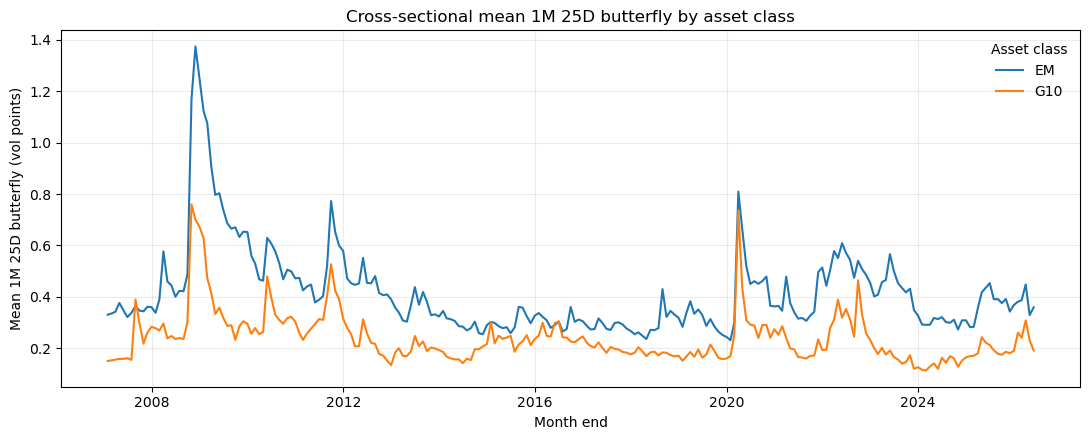

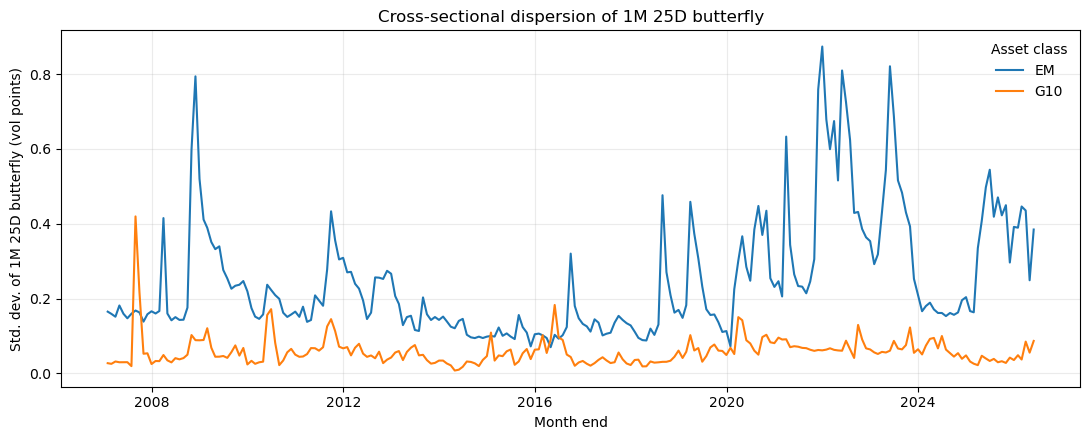

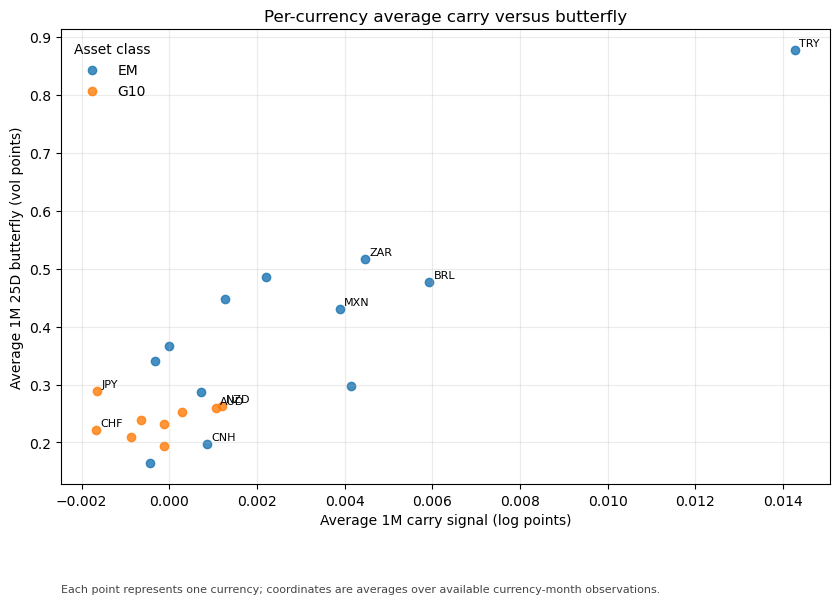

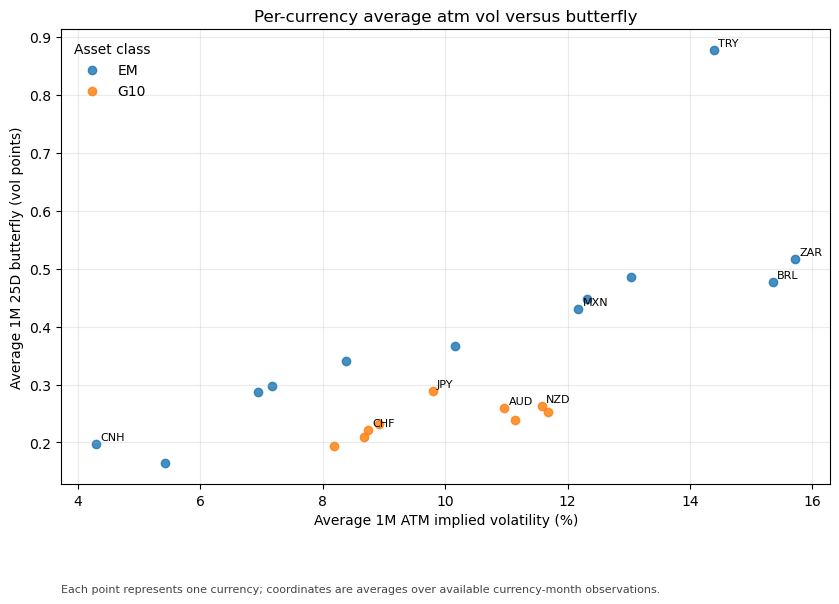

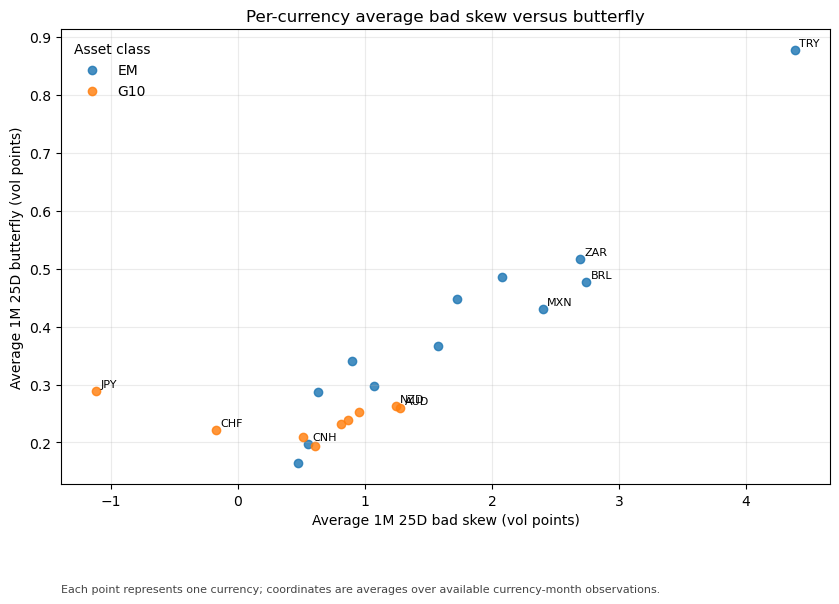

## Butterfly Conditional Heatmaps

,sample,ranking_version,row_quantile,column_quantile,mean_future_return,median_future_return,std_future_return,hit_rate,skewness,worst_observation,observations,unique_months,unique_currencies,row_q,col_q,sufficient_cell,table
0,All,global monthly quintiles,1,1,+0.00%,+0.06%,2.25%,51.4%,-0.127340,-0.082287,389,204,12,q_carry_global,q_bf25_global,True,carry_x_bf25
1,All,global monthly quintiles,1,2,-0.13%,-0.11%,2.84%,48.4%,0.172788,-0.105134,258,180,12,q_carry_global,q_bf25_global,True,carry_x_bf25
2,All,global monthly quintiles,1,3,-0.34%,-0.26%,2.78%,44.6%,-0.296087,-0.120225,280,185,14,q_carry_global,q_bf25_global,True,carry_x_bf25
3,All,global monthly quintiles,1,4,-0.38%,-0.31%,2.62%,44.5%,-0.003698,-0.088959,137,116,10,q_carry_global,q_bf25_global,True,carry_x_bf25
4,All,global monthly quintiles,1,5,-0.48%,-0.12%,4.89%,46.0%,0.074552,-0.134821,50,50,5,q_carry_global,q_bf25_global,True,carry_x_bf25
5,All,global monthly quintiles,2,1,-0.14%,-0.04%,2.50%,49.0%,-0.340637,-0.132198,302,189,13,q_carry_global,q_bf25_global,True,carry_x_bf25
6,All,global monthly quintiles,2,2,-0.41%,-0.25%,2.75%,45.4%,-0.255632,-0.117123,238,176,14,q_carry_global,q_bf25_global,True,carry_x_bf25
7,All,global monthly quintiles,2,3,-0.00%,+0.18%,3.28%,52.4%,-0.401774,-0.142363,210,150,15,q_carry_global,q_bf25_global,True,carry_x_bf25
8,All,global monthly quintiles,2,4,-0.06%,+0.22%,2.74%,52.5%,-0.411986,-0.076690,120,108,14,q_carry_global,q_bf25_global,True,carry_x_bf25
9,All,global monthly quintiles,2,5,+0.28%,+0.29%,3.04%,58.1%,-0.368979,-0.084620,62,59,8,q_carry_global,q_bf25_global,True,carry_x_bf25


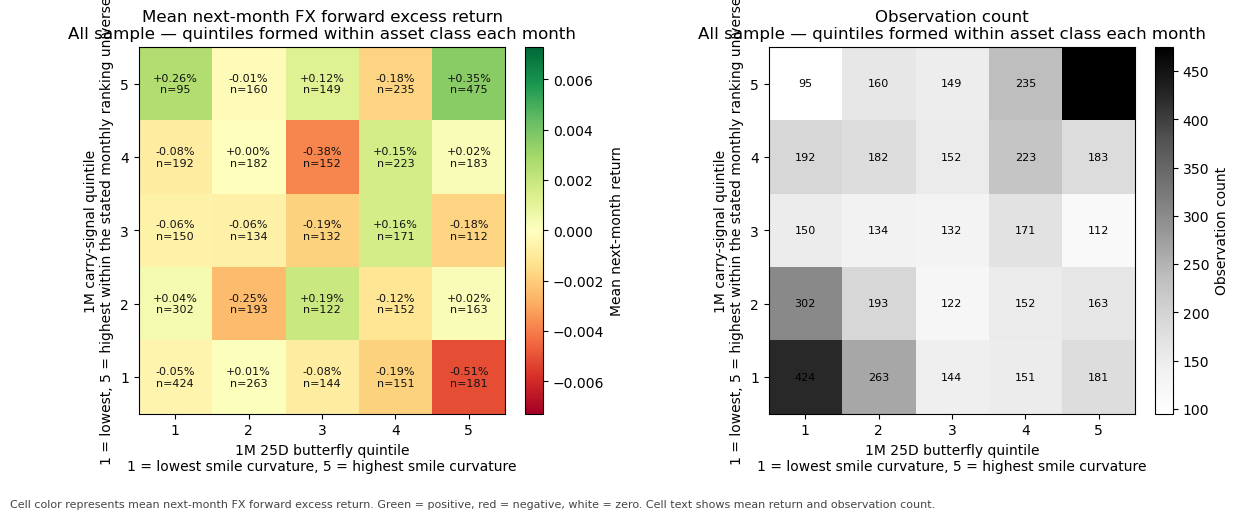

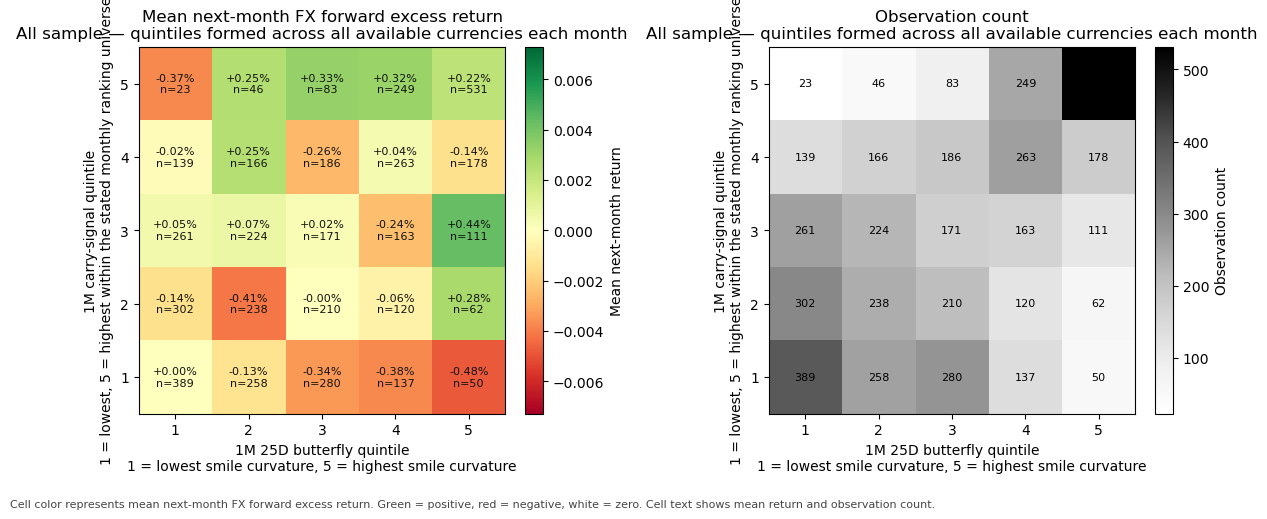

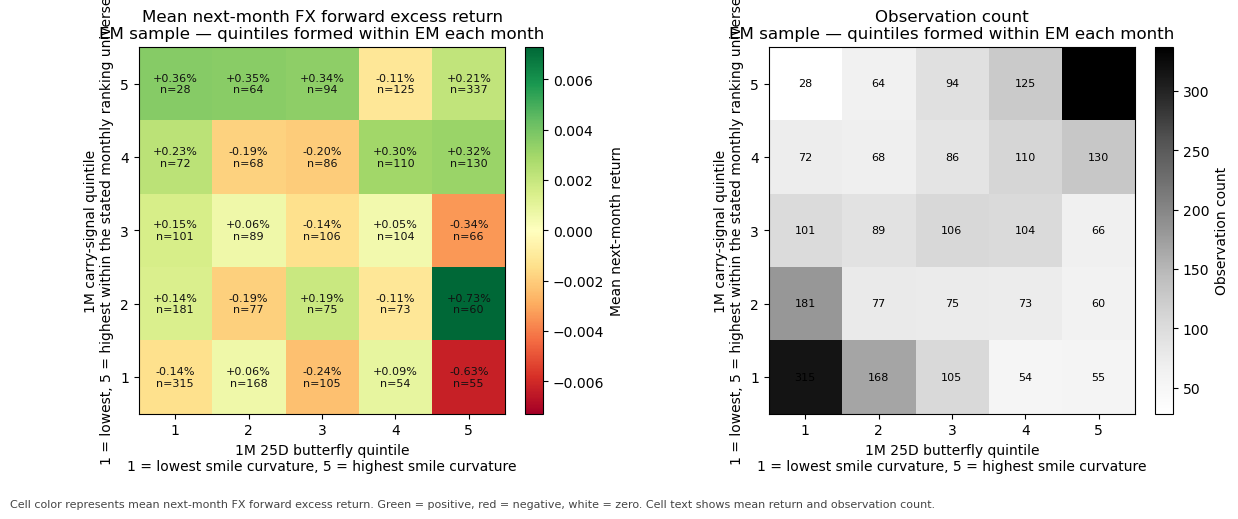

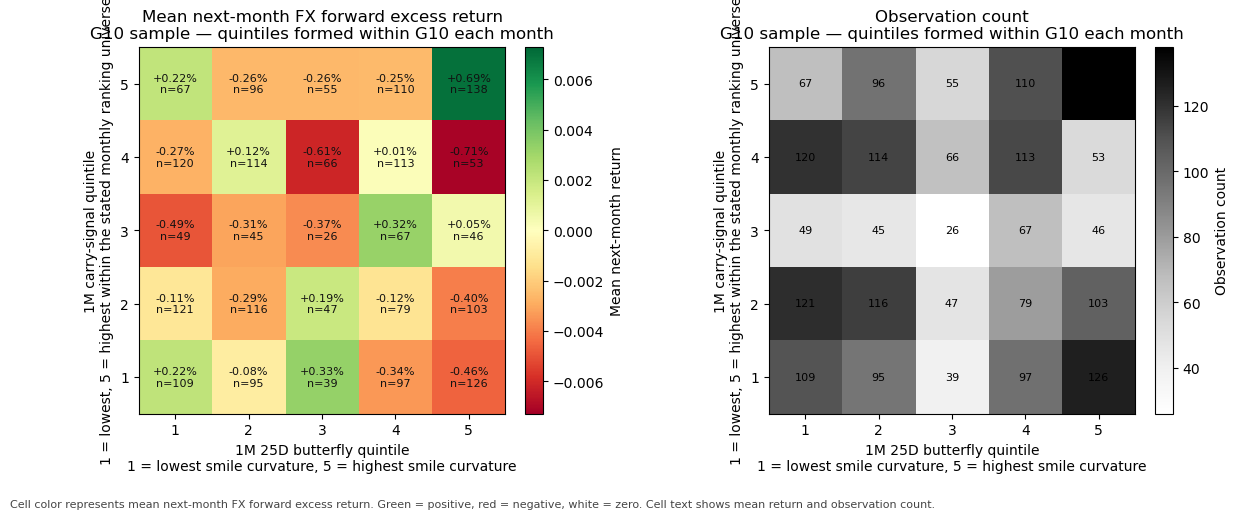

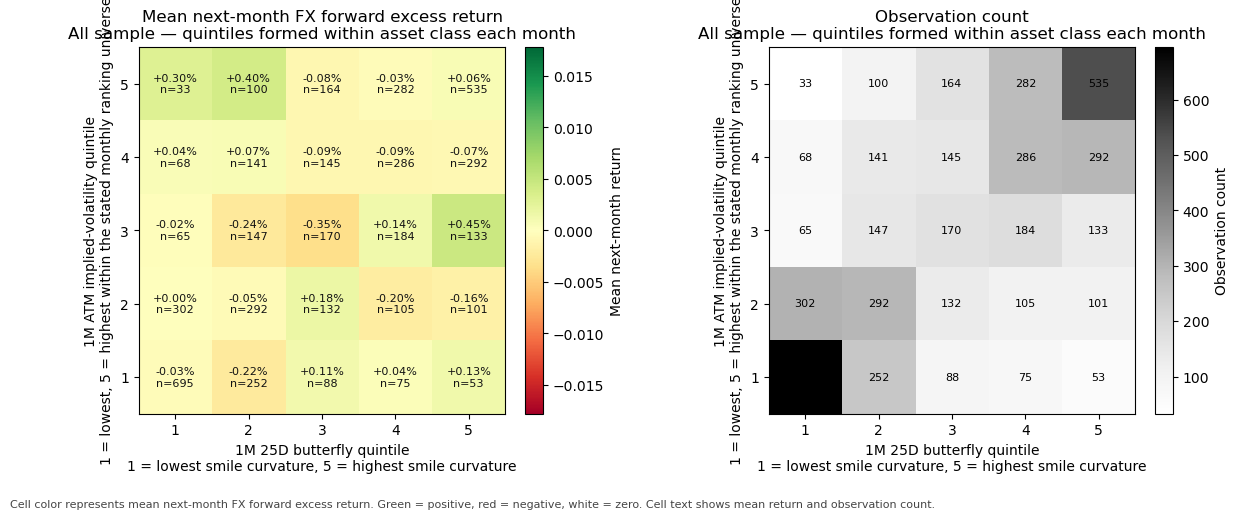

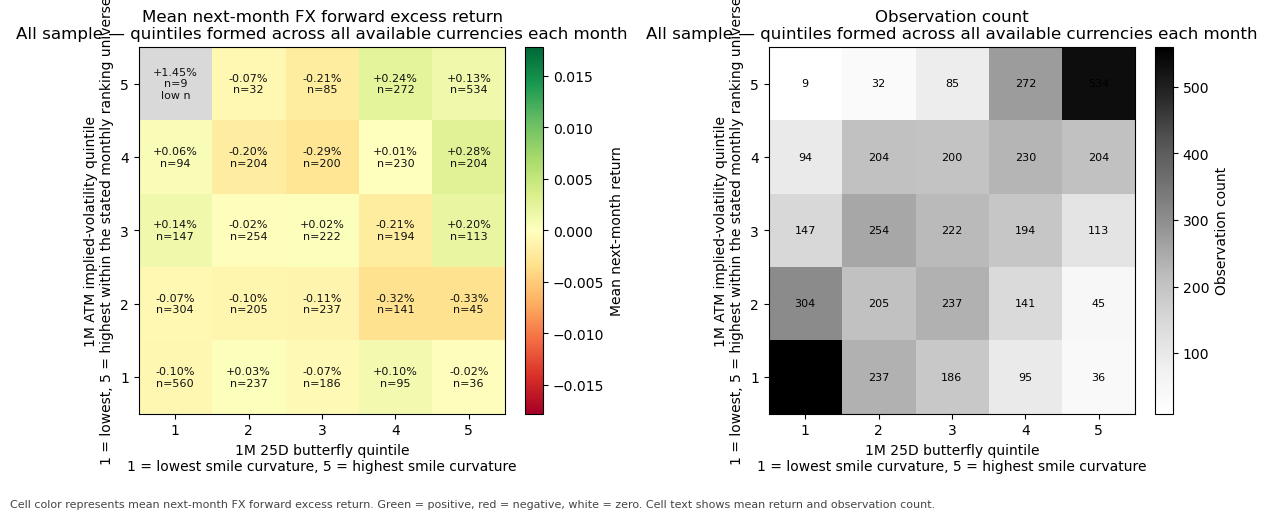

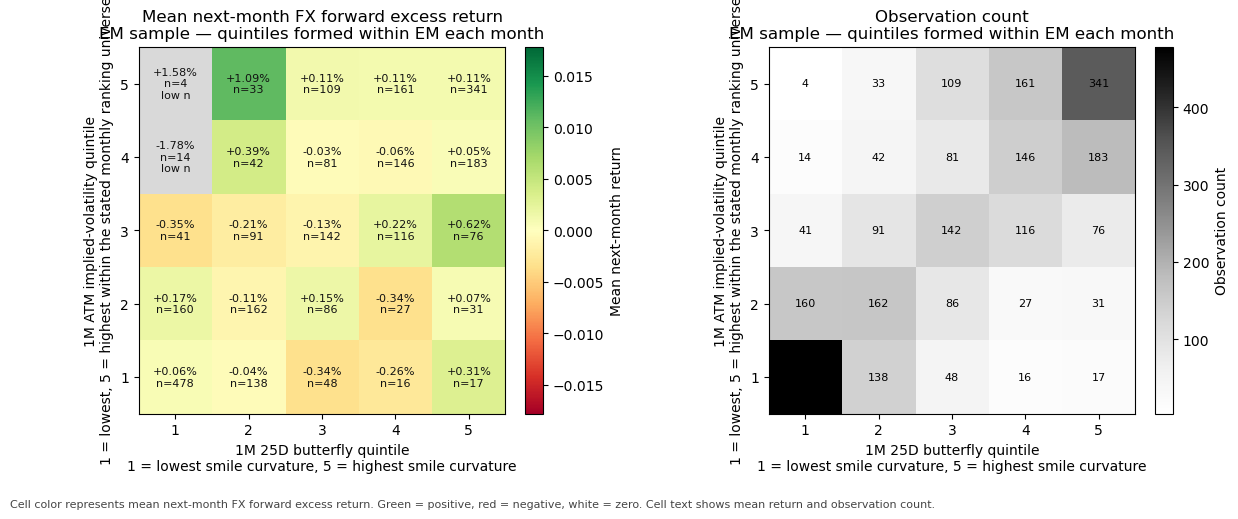

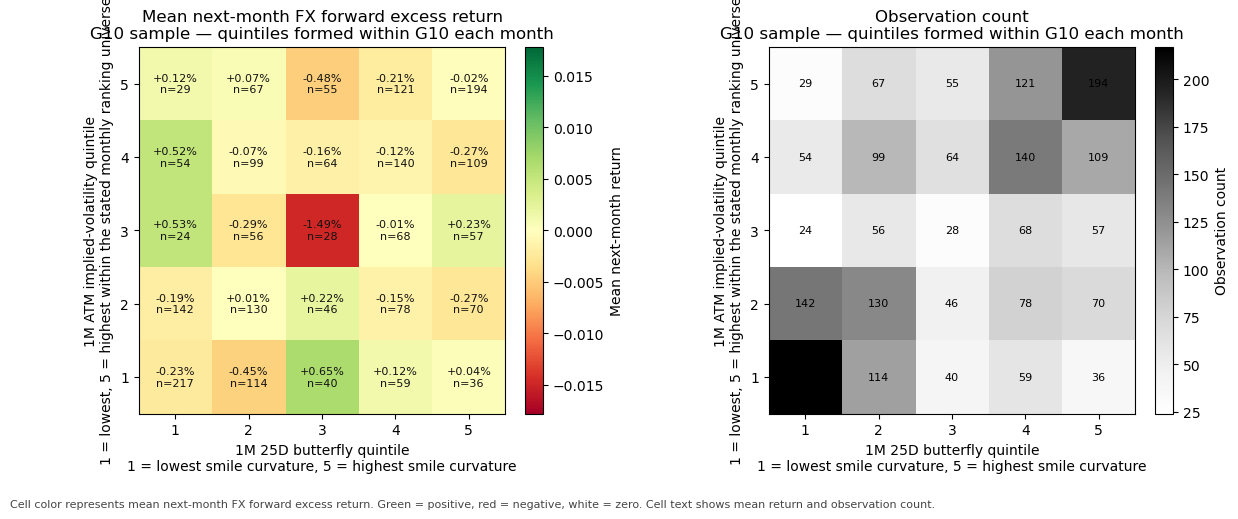

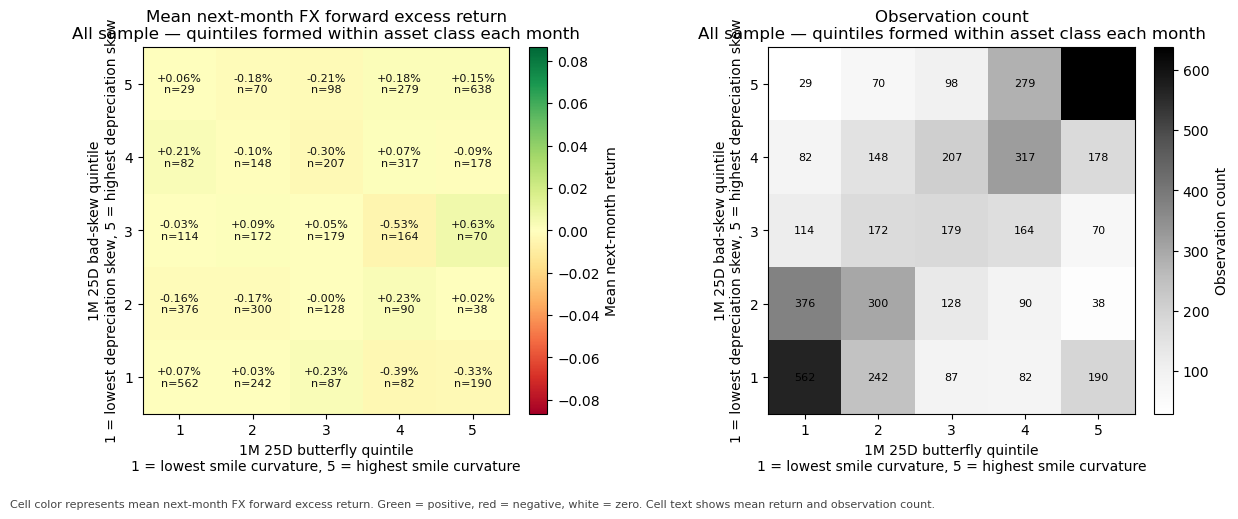

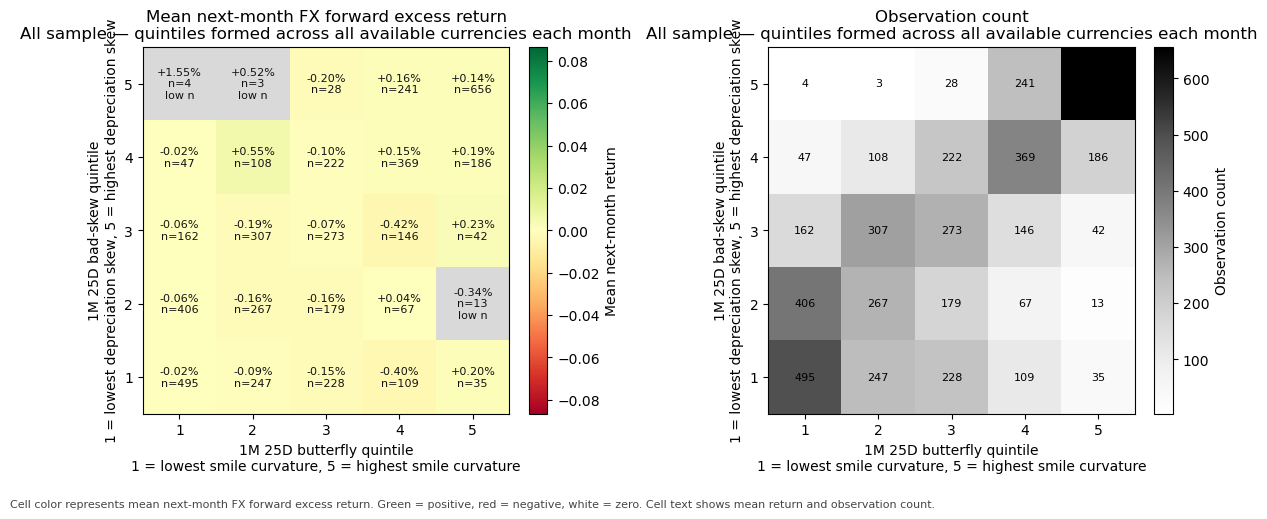

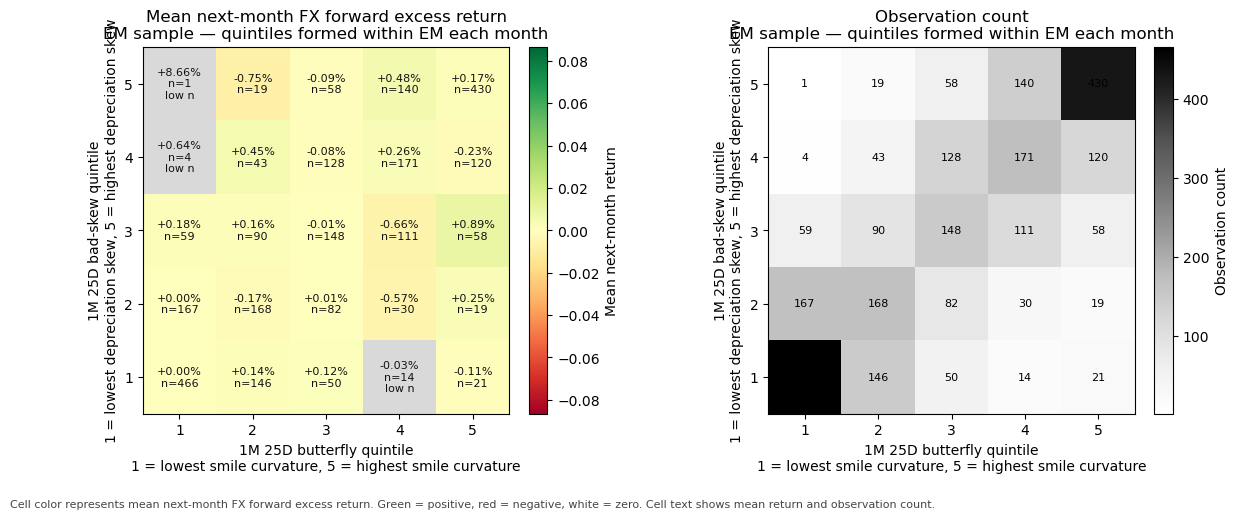

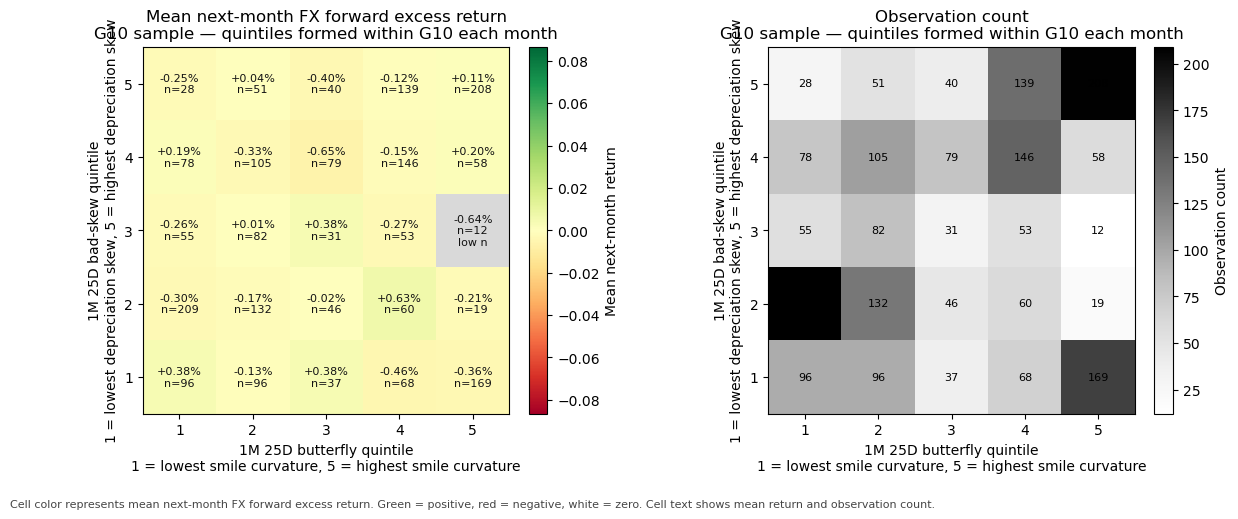

## B0 butterfly standalone control

**Purpose:** Test whether butterfly has an incremental standalone association with future mean returns.


$$
r=\alpha+\beta_C C+\beta_V V+\beta_S S+\beta_B B+\varepsilon.
$$


### All sample — asset-class monthly z-scores

,term,coefficient,two_way_cluster_se,two_way_cluster_t,two_way_cluster_p,two_way_ci_low,two_way_ci_high,stars,observations,currencies,months,adj_r_squared,monthly_bps
27,Carry,+0.00101,0.00031,+3.22,0.004,+0.00040,+0.00162,***,4840,21,233,0.0001,+10.1
28,ATM vol,+0.00045,0.00053,+0.85,0.407,-0.00059,+0.00150,,4840,21,233,0.0001,+4.5
29,Bad skew,-0.00028,0.00051,-0.55,0.588,-0.00128,+0.00072,,4840,21,233,0.0001,-2.8
30,Butterfly,-0.00052,0.00034,-1.51,0.147,-0.00119,+0.00016,,4840,21,233,0.0001,-5.2


...

,sample,specification,model,variable,coefficient,two_way_cluster_t,stars,observations,adj_r_squared
1,All,all-universe monthly z-scores,B0 butterfly standalone control,carry,+0.00128,+3.87,***,4840,0.0004
2,All,all-universe monthly z-scores,B0 butterfly standalone control,atm_vol,+0.00037,+0.70,,4840,0.0004
3,All,all-universe monthly z-scores,B0 butterfly standalone control,bad_skew,+0.00010,+0.27,,4840,0.0004
4,All,all-universe monthly z-scores,B0 butterfly standalone control,bf25,-0.00079,-1.99,*,4840,0.0004
6,All,all-universe monthly z-scores,B1 butterfly control added to M4,carry,+0.00114,+2.64,**,4840,0.0001
7,All,all-universe monthly z-scores,B1 butterfly control added to M4,atm_vol,+0.00033,+0.61,,4840,0.0001
8,All,all-universe monthly z-scores,B1 butterfly control added to M4,bad_skew,+0.00011,+0.30,,4840,0.0001
9,All,all-universe monthly z-scores,B1 butterfly control added to M4,bf25,-0.00086,-1.95,*,4840,0.0001
10,All,all-universe monthly z-scores,B1 butterfly control added to M4,carry_x_atm_vol,+0.00018,+0.32,,4840,0.0001
11,All,all-universe monthly z-scores,B1 butterfly control added to M4,carry_x_bad_skew,+0.00004,+0.21,,4840,0.0001


## Butterfly and Future Risk

,sample,outcome,model,variable,coefficient,two_way_cluster_t,two_way_cluster_p,observations
0,All,future absolute return,future absolute return,bf25,+0.00091,+1.81,0.086,4840
1,All,future absolute return,future absolute return,carry_x_atm_vol,+0.00048,+0.61,0.549,4840
2,All,future absolute return,future absolute return,carry_x_bad_skew,-0.00013,-0.36,0.726,4840
3,All,future absolute return,future absolute return,carry_x_bf25,-0.00041,-0.90,0.381,4840
4,G10,future absolute return,future absolute return,bf25,+0.00058,+0.90,0.395,2097
5,G10,future absolute return,future absolute return,carry_x_atm_vol,+0.00033,+0.58,0.580,2097
6,G10,future absolute return,future absolute return,carry_x_bad_skew,+0.00019,+0.21,0.840,2097
7,G10,future absolute return,future absolute return,carry_x_bf25,+0.00044,+0.72,0.491,2097
8,EM,future absolute return,future absolute return,bf25,+0.00117,+1.26,0.235,2743
9,EM,future absolute return,future absolute return,carry_x_atm_vol,-0.00031,-0.26,0.799,2743


## Butterfly Robustness

,sample,model,robustness_check,excluded_currency,variable,coefficient,two_way_cluster_t,two_way_cluster_p,observations
0,All,B1 butterfly control added to M4,raw variables,nan,bf25,+0.00518,+0.81,0.426,4840
1,All,B1 butterfly control added to M4,raw variables,nan,carry_x_atm_vol,-0.01054,-0.79,0.437,4840
2,All,B1 butterfly control added to M4,raw variables,nan,carry_x_bad_skew,-0.02866,-0.67,0.510,4840
3,All,B1 butterfly control added to M4,within-class z-scores,nan,bf25,-0.00058,-1.26,0.222,4840
4,All,B1 butterfly control added to M4,within-class z-scores,nan,carry_x_atm_vol,+0.00125,+1.59,0.128,4840
5,All,B1 butterfly control added to M4,within-class z-scores,nan,carry_x_bad_skew,-0.00010,-0.31,0.760,4840
6,G10,B1 butterfly control added to M4,raw variables,nan,bf25,+0.01836,+1.09,0.307,2097
7,G10,B1 butterfly control added to M4,raw variables,nan,carry_x_atm_vol,-0.12977,-0.53,0.607,2097
8,G10,B1 butterfly control added to M4,raw variables,nan,carry_x_bad_skew,+0.22129,+0.42,0.685,2097
9,G10,B1 butterfly control added to M4,within-class z-scores,nan,bf25,-0.00056,-0.76,0.471,2097


In [13]:

print("Running butterfly extension...")

def add_butterfly_design(df, suffix=None, raw=False, use_bf10=False):
    out = add_design_columns(df, suffix=suffix, raw=raw)
    if raw:
        out["bf25"] = out["bf10_1m"] if use_bf10 and "bf10_1m" in out else out["bf25_1m"]
    else:
        if use_bf10 and "bf10_1m" in out and out["bf10_1m"].notna().sum() > 50:
            tmp = out.copy()
            # Recompute 10D butterfly z-score with the same grouping convention.
            group_cols = ["month_end"] if suffix == "all" else ["month_end", "asset_class"]
            min_n = MIN_Z_N_ALL if suffix == "all" else MIN_Z_N_CLASS
            zcol = f"z_bf25_{suffix}"
            for _, sub in tmp.groupby(group_cols):
                z, _ = safe_group_zscore_missing(sub["bf10_1m"], min_n)
                tmp.loc[sub.index, zcol] = z
            out = tmp
        out["bf25"] = out[f"z_bf25_{suffix}"]
    out["carry_x_bf25"] = out["carry"] * out["bf25"]
    return out

BUTTERFLY_MODELS = {
    "B0 butterfly standalone control": ["carry", "atm_vol", "bad_skew", "bf25"],
    "B1 butterfly control added to M4": ["carry", "atm_vol", "bad_skew", "bf25", "carry_x_atm_vol", "carry_x_bad_skew"],
    "B2 carry x butterfly": ["carry", "atm_vol", "bad_skew", "bf25", "carry_x_bf25"],
    "B3 joint three-conditioner model": ["carry", "atm_vol", "bad_skew", "bf25", "carry_x_atm_vol", "carry_x_bad_skew", "carry_x_bf25"],
}
BUTTERFLY_NARRATIVE = {
    "B0 butterfly standalone control": {
        "formula": r"""
$$
r=\alpha+\beta_C C+\beta_V V+\beta_S S+\beta_B B+\varepsilon.
$$
""",
        "purpose": "Test whether butterfly has an incremental standalone association with future mean returns.",
    },
    "B1 butterfly control added to M4": {
        "formula": r"""
$$
r=\alpha+\beta_C C+\beta_V V+\beta_S S+\beta_B B+\beta_{CV}CV+\beta_{CS}CS+\varepsilon.
$$
""",
        "purpose": "Test whether carry x ATM-vol and carry x bad-skew survive after controlling for smile curvature.",
    },
    "B2 carry x butterfly": {
        "formula": r"""
$$
r=\alpha+\beta_C C+\beta_V V+\beta_S S+\beta_B B+\beta_{CB}CB+\varepsilon.
$$

$$
\frac{\partial E[r]}{\partial C}=\beta_C+\beta_{CB}B.
$$
""",
        "purpose": "Test whether smile curvature conditions carry quality.",
    },
    "B3 joint three-conditioner model": {
        "formula": r"""
$$
\begin{aligned}
r=&\ \alpha+\beta_C C+\beta_V V+\beta_S S+\beta_B B\\
&+\beta_{CV}CV+\beta_{CS}CS+\beta_{CB}CB+\varepsilon.
\end{aligned}
$$

$$
\frac{\partial E[r]}{\partial C}=\beta_C+\beta_{CV}V+\beta_{CS}S+\beta_{CB}B.
$$
""",
        "purpose": "Compare whether ATM vol, bad skew, or butterfly has incremental information about the carry slope.",
    },
}

butterfly_descriptive = descriptive_table[descriptive_table["variable"].astype(str).str.contains("bf25|butterfly", case=False, na=False)].copy()
# Add focused butterfly correlations.
bf_corr_rows=[]
for sample, df in {"All": z_panel, "G10": z_panel[z_panel["asset_class"].eq("G10")], "EM": z_panel[z_panel["asset_class"].eq("EM")]}.items():
    cols=["carry_signal_1m", "atm_vol_1m", "bad_skew25_1m", "bf25_1m", Y_COL]
    for method in ["pearson", "spearman"]:
        cc=df[cols].corr(method=method).stack().reset_index()
        cc.columns=["variable_1","variable_2","correlation"]
        cc["sample"]=sample; cc["method"]=method
        bf_corr_rows.append(cc)
butterfly_correlations=pd.concat(bf_corr_rows, ignore_index=True) if bf_corr_rows else pd.DataFrame()
butterfly_descriptive = pd.concat([butterfly_descriptive.assign(table="descriptive"), butterfly_correlations.assign(table="correlations")], ignore_index=True, sort=False)
display(Markdown("## Butterfly Descriptive Analysis"))
display(butterfly_descriptive.head(120).style.format({"mean":"{:+.4f}", "std":"{:.4f}", "correlation":"{:+.2f}"}) if not butterfly_descriptive.empty else butterfly_descriptive)

# Butterfly-specific plots.
if plt is not None:
    bf_month = z_panel.groupby(["month_end", "asset_class"], as_index=False).agg(mean_bf25=("bf25_1m","mean"), disp_bf25=("bf25_1m","std"))
    for col, title, ylabel in [("mean_bf25", "Cross-sectional mean 1M 25D butterfly by asset class", "Mean 1M 25D butterfly (vol points)"), ("disp_bf25", "Cross-sectional dispersion of 1M 25D butterfly", "Std. dev. of 1M 25D butterfly (vol points)")]:
        fig, ax = plt.subplots(figsize=(11,4.5))
        for asset, sub in bf_month.groupby("asset_class"):
            ax.plot(sub["month_end"], sub[col], label=asset)
        finalize_axis(ax, title=title, xlabel="Month end", ylabel=ylabel)
        ax.legend(title="Asset class", frameon=False)
        plt.tight_layout(); savefig(fig, f"butterfly_{col}_by_asset_class.png"); plt.show()
    avg_ccy_bf = z_panel.groupby(["asset_class","currency"], as_index=False).agg(avg_carry=("carry_signal_1m","mean"), avg_atm_vol=("atm_vol_1m","mean"), avg_bad_skew=("bad_skew25_1m","mean"), avg_bf25=("bf25_1m","mean"))
    for xcol, xlabel, name in [("avg_carry", "Average 1M carry signal (log points)", "carry"), ("avg_atm_vol", "Average 1M ATM implied volatility (%)", "atm_vol"), ("avg_bad_skew", "Average 1M 25D bad skew (vol points)", "bad_skew")]:
        fig, ax = plt.subplots(figsize=(8.5,6.2))
        for asset, sub in avg_ccy_bf.groupby("asset_class"):
            ax.scatter(sub[xcol], sub["avg_bf25"], label=asset, alpha=.82)
            for _, row in sub.iterrows():
                if row["currency"] in ["TRY","BRL","ZAR","MXN","JPY","CHF","AUD","NZD","CNH"]:
                    ax.annotate(row["currency"], (row[xcol], row["avg_bf25"]), fontsize=8, xytext=(3,3), textcoords="offset points")
        finalize_axis(ax, title=f"Per-currency average {name.replace('_',' ')} versus butterfly", xlabel=xlabel, ylabel="Average 1M 25D butterfly (vol points)", note="Each point represents one currency; coordinates are averages over available currency-month observations.")
        ax.legend(title="Asset class", frameon=False)
        plt.tight_layout(); savefig(fig, f"butterfly_scatter_{name}_vs_bf25.png"); plt.show()

# Butterfly conditional heatmaps.
bf_heatmap_tables=[]
for sample, df in {"All": cond_panel, "G10": cond_panel[cond_panel["asset_class"].eq("G10")], "EM": cond_panel[cond_panel["asset_class"].eq("EM")]}.items():
    versions=["global"] if sample=="All" else []
    versions.append("class")
    for version in versions:
        suffix="global" if version=="global" else "class"
        for a,b in [("carry","bf25"),("vol","bf25"),("skew","bf25")]:
            t=cell_stats(df, f"q_{a}_{suffix}", f"q_{b}_{suffix}", sample, "global monthly quintiles" if version=="global" else "asset-class monthly quintiles")
            t["table"]=f"{a}_x_{b}"
            bf_heatmap_tables.append(t)
butterfly_heatmap_cells=pd.concat(bf_heatmap_tables, ignore_index=True) if bf_heatmap_tables else pd.DataFrame()
display(Markdown("## Butterfly Conditional Heatmaps"))
display(butterfly_heatmap_cells.head(80).style.format({"mean_future_return":"{:+.2%}", "median_future_return":"{:+.2%}", "std_future_return":"{:.2%}", "hit_rate":"{:.1%}"}) if not butterfly_heatmap_cells.empty else butterfly_heatmap_cells)
if plt is not None and not butterfly_heatmap_cells.empty:
    bf_limits=butterfly_heatmap_cells.groupby("table")["mean_future_return"].apply(lambda s: symmetric_limit(s.to_numpy())).to_dict()
    for table in ["carry_x_bf25", "vol_x_bf25", "skew_x_bf25"]:
        sub=butterfly_heatmap_cells[butterfly_heatmap_cells["table"].eq(table)]
        if sub.empty: continue
        for (sample, ranking_version), _ in sub.groupby(["sample","ranking_version"]):
            safe_sample=str(sample).replace("+","plus").replace(" ","_")
            safe_rank=str(ranking_version).replace(" ","_").replace("-","_")
            plot_return_heatmap_from_cells(butterfly_heatmap_cells, table=table, sample=sample, ranking_version=ranking_version, output_name=f"butterfly_heatmap_return_{table}_{safe_sample}_{safe_rank}.png", shared_limit=bf_limits.get(table))

# Butterfly regressions B0-B3.
butterfly_regression_parts=[]; butterfly_fitted_models={}; butterfly_fitted_data={}
bf_specs=[
    ("All", "all-universe monthly z-scores", add_butterfly_design(z_panel, suffix="all")),
    ("All", "asset-class monthly z-scores", add_butterfly_design(z_panel, suffix="class")),
    ("G10", "within-class monthly z-scores", add_butterfly_design(z_panel[z_panel["asset_class"].eq("G10")], suffix="class")),
    ("EM", "within-class monthly z-scores", add_butterfly_design(z_panel[z_panel["asset_class"].eq("EM")], suffix="class")),
]
for sample, spec, df in bf_specs:
    for model, terms in BUTTERFLY_MODELS.items():
        res, fit, used=fit_ols_with_inference(df, Y_COL, terms, sample, model, spec)
        if not res.empty:
            butterfly_regression_parts.append(res)
            butterfly_fitted_models[(sample, spec, model)] = fit
            butterfly_fitted_data[(sample, spec, model)] = used
butterfly_regression_results=pd.concat(butterfly_regression_parts, ignore_index=True) if butterfly_regression_parts else pd.DataFrame()
for model, meta in BUTTERFLY_NARRATIVE.items():
    display(Markdown(f"## {model}"))
    display(Markdown(f"**Purpose:** {meta['purpose']}"))
    display(Markdown(meta["formula"]))
    for sample, spec in MAIN_SPEC_BY_SAMPLE.items():
        tbl=compact_model_table(butterfly_regression_results, sample, spec, model, BUTTERFLY_MODELS[model])
        display(Markdown(f"### {sample} sample — {spec}"))
        display(tbl.style.format({"coefficient":"{:+.5f}", "monthly_bps":"{:+.1f}", "two_way_cluster_se":"{:.5f}", "two_way_cluster_t":"{:+.2f}", "two_way_cluster_p":"{:.3f}", "two_way_ci_low":"{:+.5f}", "two_way_ci_high":"{:+.5f}", "adj_r_squared":"{:.4f}"}) if not tbl.empty else tbl)
        display(Markdown(interpretation_for_table(tbl, model)))

butterfly_model_comparison = butterfly_regression_results[butterfly_regression_results["variable"].isin(["carry","atm_vol","bad_skew","bf25","carry_x_atm_vol","carry_x_bad_skew","carry_x_bf25"])].copy()
display(Markdown("## Butterfly Model Comparison"))
display(butterfly_model_comparison[["sample","specification","model","variable","coefficient","two_way_cluster_t","stars","observations","adj_r_squared"]].style.format({"coefficient":"{:+.5f}", "two_way_cluster_t":"{:+.2f}", "adj_r_squared":"{:.4f}"}) if not butterfly_model_comparison.empty else butterfly_model_comparison)

# Butterfly future-risk outcomes.
bf_risk_rows=[]
bf_risk = add_butterfly_design(z_panel, suffix="class")
bf_risk["future_abs_return"] = bf_risk[Y_COL].abs()
bf_risk["future_squared_return"] = bf_risk[Y_COL] ** 2
risk_q10 = bf_risk[Y_COL].quantile(.10)
bf_risk["severe_loss_full"] = (bf_risk[Y_COL] <= risk_q10).astype(float)
for yout, label in [("future_abs_return", "future absolute return"), ("future_squared_return", "future squared return"), ("future_loss", "negative-return probability LPM"), ("severe_loss_full", "severe-loss probability LPM")]:
    for sample, df in {"All": bf_risk, "G10": bf_risk[bf_risk["asset_class"].eq("G10")], "EM": bf_risk[bf_risk["asset_class"].eq("EM")]}.items():
        res, _, _ = fit_ols_with_inference(df, yout, BUTTERFLY_MODELS["B3 joint three-conditioner model"], sample, label, "butterfly risk outcome", min_obs=40)
        if not res.empty:
            bf_risk_rows.append(res[res["variable"].isin(["bf25","carry_x_bf25","carry_x_atm_vol","carry_x_bad_skew"])].assign(outcome=label))
# Quantile regressions for lower tail.
if STATSMODELS_AVAILABLE:
    for q in [.10,.25]:
        df=bf_risk.dropna(subset=[Y_COL]+BUTTERFLY_MODELS["B3 joint three-conditioner model"]).copy()
        if len(df)>=80:
            try:
                X=sm.add_constant(df[BUTTERFLY_MODELS["B3 joint three-conditioner model"]], has_constant="add")
                fit=sm.QuantReg(df[Y_COL], X).fit(q=q, max_iter=2000)
                for var in ["bf25","carry_x_bf25","carry_x_atm_vol","carry_x_bad_skew"]:
                    bf_risk_rows.append(pd.DataFrame([{"sample":"All","model":f"butterfly quantile {q:.2f}","specification":"quantile regression no clustered inference","variable":var,"coefficient":fit.params.get(var,np.nan),"two_way_cluster_t":np.nan,"two_way_cluster_p":np.nan,"observations":len(df),"outcome":f"lower-tail quantile {q:.2f}"}]))
            except Exception as exc:
                skipped_models.append({"section":"butterfly quantile regression","q":q,"reason":repr(exc)})
butterfly_risk_results=pd.concat([x for x in bf_risk_rows if isinstance(x, pd.DataFrame) and not x.empty], ignore_index=True, sort=False) if bf_risk_rows else pd.DataFrame()
display(Markdown("## Butterfly and Future Risk"))
display(butterfly_risk_results[[c for c in ["sample","outcome","model","variable","coefficient","two_way_cluster_t","two_way_cluster_p","observations"] if c in butterfly_risk_results]].head(120).style.format({"coefficient":"{:+.5f}", "two_way_cluster_t":"{:+.2f}", "two_way_cluster_p":"{:.3f}"}) if not butterfly_risk_results.empty else butterfly_risk_results)

# Butterfly robustness.
bf_robust_rows=[]
def extract_bf_terms(res, check):
    if res.empty: return pd.DataFrame()
    return res[res["variable"].isin(["bf25","carry_x_bf25","carry_x_atm_vol","carry_x_bad_skew"])].copy().assign(robustness_check=check)
for model in ["B1 butterfly control added to M4", "B3 joint three-conditioner model"]:
    for sample, df0 in {"All": z_panel, "G10": z_panel[z_panel["asset_class"].eq("G10")], "EM": z_panel[z_panel["asset_class"].eq("EM")]}.items():
        specs=[("raw variables", add_butterfly_design(df0, raw=True)), ("within-class z-scores", add_butterfly_design(df0, suffix="class"))]
        for check, dfx in specs:
            res,_,_=fit_ols_with_inference(dfx, Y_COL, BUTTERFLY_MODELS[model], sample, model, check)
            bf_robust_rows.append(extract_bf_terms(res, check))
    # Winsorized class z-scores.
    tmp=z_panel.copy()
    for col in list(SIGNAL_MAP.values()):
        tmp[col]=tmp.groupby("month_end")[col].transform(lambda s: s.clip(s.quantile(.01), s.quantile(.99)) if s.notna().sum()>=5 else s)
    for keys, sub in tmp.groupby(["month_end","asset_class"]):
        for name, col in SIGNAL_MAP.items():
            z,_=safe_group_zscore_missing(sub[col], MIN_Z_N_CLASS)
            tmp.loc[sub.index, f"z_{name}_class"] = z
    res,_,_=fit_ols_with_inference(add_butterfly_design(tmp, suffix="class"), Y_COL, BUTTERFLY_MODELS[model], "All", model, "monthly 1/99 winsorization")
    bf_robust_rows.append(extract_bf_terms(res, "monthly 1/99 winsorization"))
    # Leave-one-currency-out for All.
    for ccy in sorted(z_panel["currency"].dropna().unique()):
        res,_,_=fit_ols_with_inference(add_butterfly_design(z_panel[~z_panel["currency"].eq(ccy)], suffix="class"), Y_COL, BUTTERFLY_MODELS[model], "All", model, f"excluding {ccy}")
        tmpres=extract_bf_terms(res, f"excluding {ccy}"); tmpres["excluded_currency"]=ccy; bf_robust_rows.append(tmpres)
    # 10D butterfly if available.
    if z_panel["bf10_1m"].notna().sum() > 50:
        res,_,_=fit_ols_with_inference(add_butterfly_design(z_panel, suffix="class", use_bf10=True), Y_COL, BUTTERFLY_MODELS[model], "All", model, "10D butterfly substitute")
        bf_robust_rows.append(extract_bf_terms(res, "10D butterfly substitute"))
butterfly_robustness=pd.concat([x for x in bf_robust_rows if isinstance(x, pd.DataFrame) and not x.empty], ignore_index=True, sort=False) if bf_robust_rows else pd.DataFrame()
# Fixed-effect robustness for B1 and B3, suppressing dummy coefficients.
bf_fe_rows=[]
def fit_butterfly_fe(df, sample, model, fe_type):
    if not STATSMODELS_AVAILABLE:
        return pd.DataFrame()
    d=add_butterfly_design(df, suffix="class").replace([np.inf,-np.inf], np.nan).dropna(subset=[Y_COL,"month_end","currency"]+BUTTERFLY_MODELS[model]).copy()
    if len(d)<50 or d["currency"].nunique()<2 or d["month_end"].nunique()<6:
        skipped_models.append({"section":"butterfly fixed effects","sample":sample,"model":model,"fe_type":fe_type,"reason":"insufficient observations"})
        return pd.DataFrame()
    d["month_fe"]=pd.to_datetime(d["month_end"]).dt.to_period("M").astype(str)
    rhs=" + ".join(BUTTERFLY_MODELS[model])
    if fe_type=="currency FE": rhs += " + C(currency)"
    if fe_type=="month FE": rhs += " + C(month_fe)"
    if fe_type=="currency and month FE": rhs += " + C(currency) + C(month_fe)"
    try:
        fit=sm.OLS.from_formula(f"{Y_COL} ~ {rhs}", data=d).fit()
        tw=robustcov_fit(fit,d,"two_way_cluster")
        if isinstance(tw, Exception) or tw is None: tw=fit
    except Exception as exc:
        skipped_models.append({"section":"butterfly fixed effects","sample":sample,"model":model,"fe_type":fe_type,"reason":repr(exc)})
        return pd.DataFrame()
    names=list(fit.params.index); rows=[]
    for var in ["bf25","carry_x_bf25","carry_x_atm_vol","carry_x_bad_skew"]:
        if var not in names: continue
        idx=names.index(var)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="invalid value encountered in sqrt", category=RuntimeWarning)
            se_arr=np.asarray(tw.bse,dtype=float); t_arr=np.asarray(tw.tvalues,dtype=float); p_arr=np.asarray(tw.pvalues,dtype=float)
        pval=float(p_arr[idx]) if idx<len(p_arr) else np.nan
        rows.append({"sample":sample,"model":model,"robustness_check":fe_type,"variable":var,"coefficient":fit.params[var],"two_way_cluster_se":float(se_arr[idx]) if idx<len(se_arr) else np.nan,"two_way_cluster_t":float(t_arr[idx]) if idx<len(t_arr) else np.nan,"two_way_cluster_p":pval,"stars":star(pval),"observations":len(d),"currencies":d["currency"].nunique(),"months":d["month_end"].nunique()})
    return pd.DataFrame(rows)
for model in ["B1 butterfly control added to M4", "B3 joint three-conditioner model"]:
    for sample, df0 in {"All": z_panel, "G10": z_panel[z_panel["asset_class"].eq("G10")], "EM": z_panel[z_panel["asset_class"].eq("EM")]}.items():
        for fe_type in ["currency FE", "month FE", "currency and month FE"]:
            bf_fe_rows.append(fit_butterfly_fe(df0, sample, model, fe_type))
butterfly_fe_robustness=pd.concat([x for x in bf_fe_rows if isinstance(x, pd.DataFrame) and not x.empty], ignore_index=True, sort=False) if bf_fe_rows else pd.DataFrame()
if not butterfly_fe_robustness.empty:
    butterfly_robustness=pd.concat([butterfly_robustness, butterfly_fe_robustness.assign(robustness_check=butterfly_fe_robustness["robustness_check"] + " (FE)")], ignore_index=True, sort=False)

display(Markdown("## Butterfly Robustness"))
display(butterfly_robustness[[c for c in ["sample","model","robustness_check","excluded_currency","variable","coefficient","two_way_cluster_t","two_way_cluster_p","observations"] if c in butterfly_robustness]].head(180).style.format({"coefficient":"{:+.5f}", "two_way_cluster_t":"{:+.2f}", "two_way_cluster_p":"{:.3f}"}) if not butterfly_robustness.empty else butterfly_robustness)

successful_sections.append("butterfly descriptive, heatmap, regression, risk, and robustness extensions")


## Fixed-Effect Specifications

For standardized M4, fixed effects change the interpretation. Currency fixed effects focus on within-currency variation relative to persistent currency characteristics. Month fixed effects focus on relative cross-sectional variation after removing common monthly shocks. Because monthly z-scores have zero monthly mean by construction, month fixed effects can be partly redundant but still useful for removing common return shocks.


In [14]:

def fit_fe_formula(df, sample, specification, fe_type):
    if not STATSMODELS_AVAILABLE:
        return pd.DataFrame()
    d = add_design_columns(df, suffix="class" if specification != "all-universe monthly z-scores" else "all")
    terms = MODEL_TERMS["M4 both carry interactions"]
    d = d.replace([np.inf, -np.inf], np.nan).dropna(subset=[Y_COL, "month_end", "currency"] + terms).copy()
    if len(d) < 40 or d["currency"].nunique() < 2 or d["month_end"].nunique() < 6:
        skipped_models.append({"section": "fixed effects", "sample": sample, "fe_type": fe_type, "reason": "insufficient observations"})
        return pd.DataFrame()
    d["month_fe"] = pd.to_datetime(d["month_end"]).dt.to_period("M").astype(str)
    rhs = " + ".join(terms)
    if fe_type == "currency FE": rhs += " + C(currency)"
    if fe_type == "month FE": rhs += " + C(month_fe)"
    if fe_type == "currency and month FE": rhs += " + C(currency) + C(month_fe)"
    formula = f"{Y_COL} ~ {rhs}"
    try:
        fit = sm.OLS.from_formula(formula, data=d).fit()
        tw = robustcov_fit(fit, d, "two_way_cluster")
        if isinstance(tw, Exception) or tw is None: tw = fit
    except Exception as exc:
        skipped_models.append({"section": "fixed effects", "sample": sample, "fe_type": fe_type, "reason": repr(exc)})
        return pd.DataFrame()
    names = list(fit.params.index)
    rows=[]
    for var in terms:
        if var not in names: continue
        idx = names.index(var)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="invalid value encountered in sqrt", category=RuntimeWarning)
            se_arr = np.asarray(tw.bse, dtype=float)
            p_arr = np.asarray(tw.pvalues, dtype=float)
            t_arr = np.asarray(tw.tvalues, dtype=float)
        se = float(se_arr[idx]) if idx < len(se_arr) else np.nan
        p = float(p_arr[idx]) if idx < len(p_arr) else np.nan
        t = float(t_arr[idx]) if idx < len(t_arr) else np.nan
        rows.append({"sample": sample, "specification": specification, "fe_type": fe_type, "variable": var, "coefficient": fit.params[var], "two_way_cluster_se": se, "two_way_cluster_t": t, "two_way_cluster_p": p, "stars": star(p), "observations": len(d), "currencies": d["currency"].nunique(), "months": d["month_end"].nunique(), "r_squared": fit.rsquared, "adj_r_squared": fit.rsquared_adj})
    return pd.DataFrame(rows)

fe_parts=[]
for sample, df in [("All", z_panel), ("G10", z_panel[z_panel["asset_class"].eq("G10")]), ("EM", z_panel[z_panel["asset_class"].eq("EM")])]:
    spec = "asset-class monthly z-scores" if sample == "All" else "within-class monthly z-scores"
    for fe in ["no FE", "currency FE", "month FE", "currency and month FE"]:
        if fe == "no FE":
            base = regression_results[(regression_results["sample"].eq(sample)) & (regression_results["specification"].eq(spec)) & (regression_results["model"].eq("M4 both carry interactions"))].copy()
            base["fe_type"] = "no FE"
            fe_parts.append(base[["sample", "specification", "fe_type", "variable", "coefficient", "two_way_cluster_se", "two_way_cluster_t", "two_way_cluster_p", "stars", "observations", "currencies", "months", "r_squared", "adj_r_squared"]])
        else:
            fe_parts.append(fit_fe_formula(df, sample, spec, fe))
fixed_effect_results = pd.concat([x for x in fe_parts if not x.empty], ignore_index=True) if fe_parts else pd.DataFrame()
successful_sections.append("fixed-effect M4 regressions")
display(fixed_effect_results[fixed_effect_results["variable"].isin(["carry", "atm_vol", "bad_skew", "carry_x_atm_vol", "carry_x_bad_skew"])].style.format({"coefficient":"{:+.5f}", "two_way_cluster_se":"{:.5f}", "two_way_cluster_t":"{:+.2f}", "two_way_cluster_p":"{:.3f}", "adj_r_squared":"{:.3f}"}) if not fixed_effect_results.empty else fixed_effect_results)


,sample,specification,fe_type,variable,coefficient,two_way_cluster_se,two_way_cluster_t,two_way_cluster_p,stars,observations,currencies,months,r_squared,adj_r_squared
1,All,asset-class monthly z-scores,no FE,carry,+0.00076,0.00038,+2.00,0.059,*,4840,21,233,0.001987,0.001
2,All,asset-class monthly z-scores,no FE,atm_vol,+0.00025,0.00044,+0.57,0.573,,4840,21,233,0.001987,0.001
3,All,asset-class monthly z-scores,no FE,bad_skew,-0.00048,0.00039,-1.25,0.227,,4840,21,233,0.001987,0.001
4,All,asset-class monthly z-scores,no FE,carry_x_atm_vol,+0.00134,0.00077,+1.75,0.096,*,4840,21,233,0.001987,0.001
5,All,asset-class monthly z-scores,no FE,carry_x_bad_skew,-0.00029,0.00023,-1.23,0.231,,4840,21,233,0.001987,0.001
6,All,asset-class monthly z-scores,currency FE,carry,+0.00162,0.00057,+2.84,0.010,**,4840,21,233,0.004142,-0.001
7,All,asset-class monthly z-scores,currency FE,atm_vol,+0.00059,0.00081,+0.73,0.474,,4840,21,233,0.004142,-0.001
8,All,asset-class monthly z-scores,currency FE,bad_skew,-0.00034,0.00050,-0.68,0.505,,4840,21,233,0.004142,-0.001
9,All,asset-class monthly z-scores,currency FE,carry_x_atm_vol,+0.00109,0.00106,+1.03,0.317,,4840,21,233,0.004142,-0.001
10,All,asset-class monthly z-scores,currency FE,carry_x_bad_skew,+0.00019,0.00033,+0.57,0.577,,4840,21,233,0.004142,-0.001


## Formal G10-versus-EM Heterogeneity Tests

Subgroup significance is not a formal test of whether G10 and EM differ. The pooled heterogeneity model below uses asset-class-within-month standardized signals and tests EM-minus-G10 differences directly.


,estimate_name,estimate,two_way_se,two_way_t,two_way_p,ci_low,ci_high,observations
0,G10 carry x ATM-vol,+0.00288,0.00075,+3.85,0.000,+0.00141,+0.00435,4840
1,EM carry x ATM-vol,-0.00045,0.00083,-0.55,0.582,-0.00207,+0.00116,4840
2,EM minus G10 carry x ATM-vol,-0.00333,0.00126,-2.64,0.008,-0.00581,-0.00086,4840
3,G10 carry x bad-skew,+0.00018,0.00039,+0.45,0.654,-0.00059,+0.00094,4840
4,EM carry x bad-skew,+0.00048,0.00048,+0.99,0.324,-0.00047,+0.00142,4840
5,EM minus G10 carry x bad-skew,+0.00030,0.00061,+0.50,0.618,-0.00088,+0.00149,4840


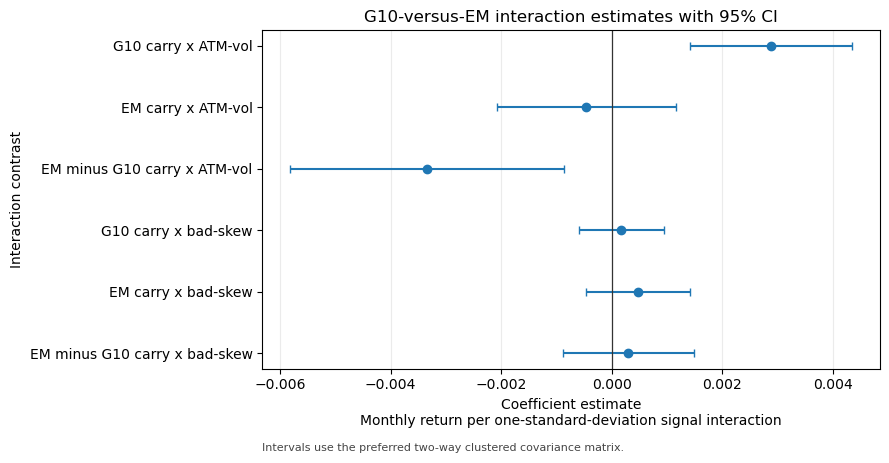

In [15]:

heterogeneity_results = pd.DataFrame()
heterogeneity_compact = pd.DataFrame()
if STATSMODELS_AVAILABLE:
    het = add_design_columns(z_panel, suffix="class")
    het["em"] = het["asset_class"].eq("EM").astype(float)
    base_terms = MODEL_TERMS["M4 both carry interactions"]
    for term in ["carry", "atm_vol", "bad_skew", "carry_x_atm_vol", "carry_x_bad_skew"]:
        het[f"em_x_{term}"] = het["em"] * het[term]
    xcols = base_terms + ["em", "em_x_carry", "em_x_atm_vol", "em_x_bad_skew", "em_x_carry_x_atm_vol", "em_x_carry_x_bad_skew"]
    heterogeneity_results, het_fit, het_used = fit_ols_with_inference(het, Y_COL, xcols, "All", "M4 EM heterogeneity", "asset-class monthly z-scores")
    if het_fit is not None:
        params = pd.Series(np.asarray(het_fit.params), index=het_fit.model.exog_names)
        cov = pd.DataFrame(np.asarray(het_fit.cov_params()), index=params.index, columns=params.index)
        def lincombo(name, weights):
            est = sum(weights.get(k,0)*params.get(k,0) for k in weights)
            keys=list(weights); w=np.array([weights[k] for k in keys], dtype=float)
            c=cov.reindex(index=keys, columns=keys).fillna(0.0).to_numpy()
            se=math.sqrt(max(float(w @ c @ w),0.0))
            t=est/se if se>0 else np.nan
            p=2*(1-scipy_stats.t.cdf(abs(t), df=max(len(het_used)-len(params),1))) if SCIPY_AVAILABLE and pd.notna(t) else np.nan
            return {"estimate_name": name, "estimate": est, "two_way_se": se, "two_way_t": t, "two_way_p": p, "ci_low": est-1.96*se if pd.notna(se) else np.nan, "ci_high": est+1.96*se if pd.notna(se) else np.nan, "observations": len(het_used)}
        heterogeneity_compact = pd.DataFrame([
            lincombo("G10 carry x ATM-vol", {"carry_x_atm_vol":1}),
            lincombo("EM carry x ATM-vol", {"carry_x_atm_vol":1, "em_x_carry_x_atm_vol":1}),
            lincombo("EM minus G10 carry x ATM-vol", {"em_x_carry_x_atm_vol":1}),
            lincombo("G10 carry x bad-skew", {"carry_x_bad_skew":1}),
            lincombo("EM carry x bad-skew", {"carry_x_bad_skew":1, "em_x_carry_x_bad_skew":1}),
            lincombo("EM minus G10 carry x bad-skew", {"em_x_carry_x_bad_skew":1}),
        ])
else:
    skipped_models.append({"section": "heterogeneity", "reason": "statsmodels unavailable"})
successful_sections.append("formal G10-versus-EM heterogeneity tests")
display(heterogeneity_compact.style.format({"estimate":"{:+.5f}", "two_way_se":"{:.5f}", "two_way_t":"{:+.2f}", "two_way_p":"{:.3f}", "ci_low":"{:+.5f}", "ci_high":"{:+.5f}"}) if not heterogeneity_compact.empty else heterogeneity_compact)
if plt is not None and not heterogeneity_compact.empty:
    fig, ax = plt.subplots(figsize=(9, 4.8))
    sub = heterogeneity_compact.copy().iloc[::-1]
    ax.errorbar(sub["estimate"], sub["estimate_name"], xerr=[sub["estimate"]-sub["ci_low"], sub["ci_high"]-sub["estimate"]], fmt="o", capsize=3)
    ax.axvline(0, color="#333", lw=.9)
    ax.grid(axis="x", alpha=.25)
    ax.set_title("G10-versus-EM interaction estimates with 95% CI")
    ax.set_xlabel("Coefficient estimate\nMonthly return per one-standard-deviation signal interaction")
    ax.set_ylabel("Interaction contrast")
    ax.text(0.0, -0.22, "Intervals use the preferred two-way clustered covariance matrix.", transform=ax.transAxes, ha="left", va="top", fontsize=8, color="#444444")
    plt.tight_layout(); savefig(fig, "heterogeneity_interaction_ci.png"); plt.show()


## Marginal Effects and Economic Magnitude

For M4, the marginal effect of carry is:

$$
\frac{\partial E[r_{i,t+1}]}{\partial C_{i,t}}
=
\beta_C
+
\beta_{CV}V_{i,t}
+
\beta_{CS}S_{i,t}.
$$

Because the signals are standardized, coefficients are interpreted as the next-month return impact of a one-standard-deviation change in the relative signal.


,sample,atm_vol_z,bad_skew_z,marginal_carry_effect,monthly_bps,se,ci_low,ci_high,ci_low_bps,ci_high_bps,unconditional_return_std,effect_vs_return_std
0,All,-1,-1,-0.00029,-2.9,0.00085,-0.001956,0.001381,-19.6,+13.8,0.032318,-0.01
1,All,-1,0,-0.00058,-5.8,0.00094,-0.002414,0.001259,-24.1,+12.6,0.032318,-0.02
2,All,-1,1,-0.00087,-8.7,0.00107,-0.002962,0.001227,-29.6,+12.3,0.032318,-0.03
3,All,-1,2,-0.00116,-11.6,0.00123,-0.003571,0.001255,-35.7,+12.6,0.032318,-0.04
4,All,0,-1,+0.00105,+10.5,0.00050,0.000077,0.002021,+0.8,+20.2,0.032318,+0.03
5,All,0,0,+0.00076,+7.6,0.00038,0.000017,0.001501,+0.2,+15.0,0.032318,+0.02
6,All,0,1,+0.00047,+4.7,0.00039,-0.000294,0.001232,-2.9,+12.3,0.032318,+0.01
7,All,0,2,+0.00018,+1.8,0.00052,-0.000840,0.001197,-8.4,+12.0,0.032318,+0.01
8,All,1,-1,+0.00239,+23.9,0.00097,0.000485,0.004286,+4.9,+42.9,0.032318,+0.07
9,All,1,0,+0.00210,+21.0,0.00076,0.000600,0.003590,+6.0,+35.9,0.032318,+0.06


### Model fit and incremental adjusted R-squared

,sample,specification,model,observations,adj_r_squared,aic,bic,delta_adj_r2_vs_M1
37,All,all-universe monthly z-scores,M0 carry only,4840,0.0008,-19489.6,-19476.6,+0.0004
39,All,all-universe monthly z-scores,M1 main effects,4840,0.0004,-19485.8,-19459.8,+0.0000
43,All,all-universe monthly z-scores,M2 carry x bad skew,4840,0.0002,-19483.8,-19451.3,-0.0002
48,All,all-universe monthly z-scores,M3 carry x ATM vol,4840,0.0002,-19483.9,-19451.5,-0.0002
53,All,all-universe monthly z-scores,M4 both carry interactions,4840,0.0000,-19482.0,-19443.1,-0.0004
59,All,all-universe monthly z-scores,M5 pairwise interactions,4840,-0.0001,-19480.4,-19435.0,-0.0005
66,All,all-universe monthly z-scores,M6 three-way exploratory,4840,0.0011,-19485.2,-19433.3,+0.0007
74,All,asset-class monthly z-scores,M0 carry only,4840,0.0005,-19488.0,-19475.0,+0.0004
76,All,asset-class monthly z-scores,M1 main effects,4840,0.0001,-19484.3,-19458.3,+0.0000
80,All,asset-class monthly z-scores,M2 carry x bad skew,4840,-0.0000,-19482.7,-19450.2,-0.0001


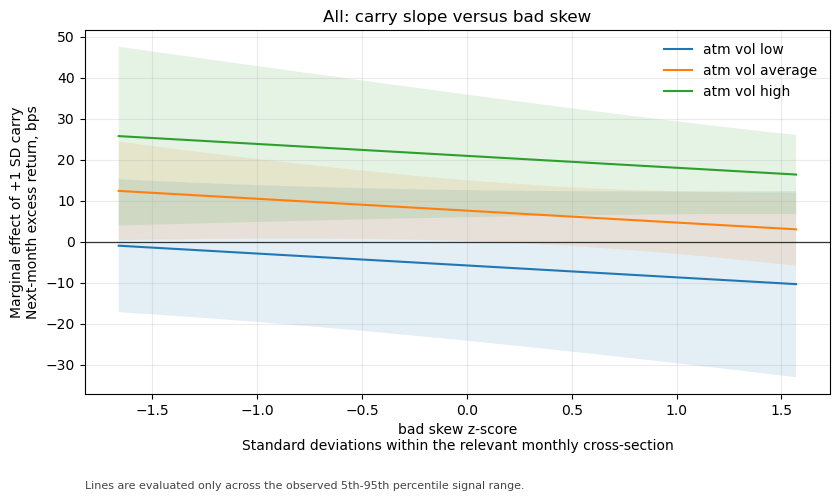

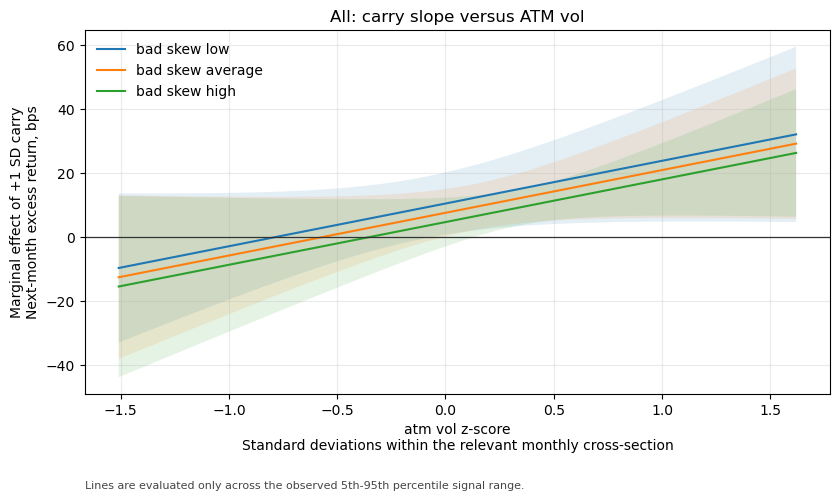

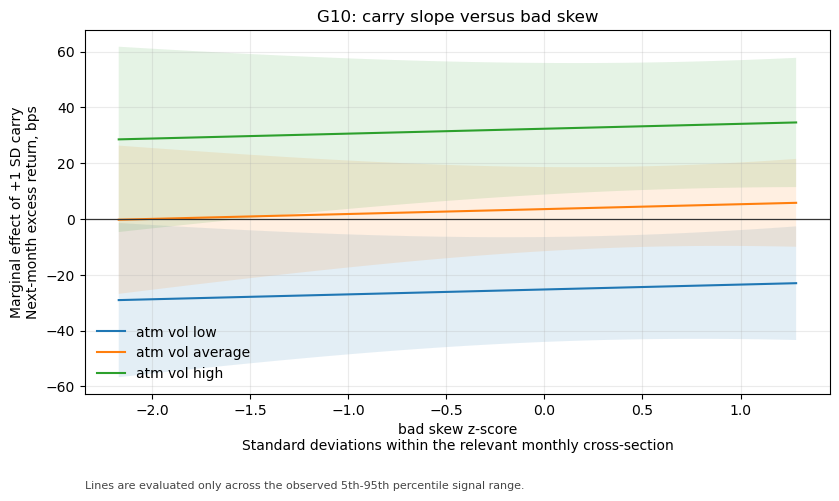

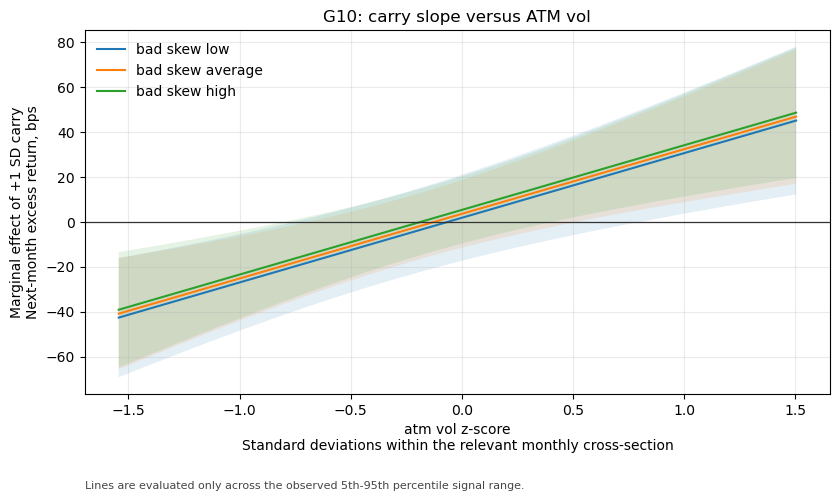

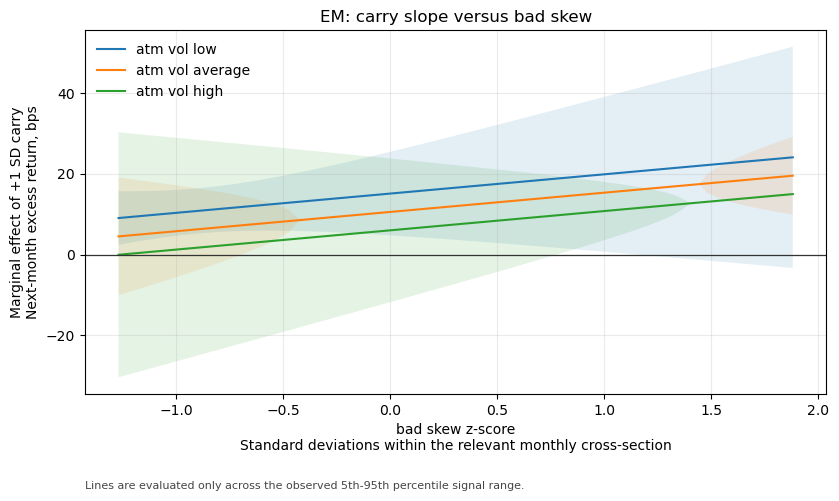

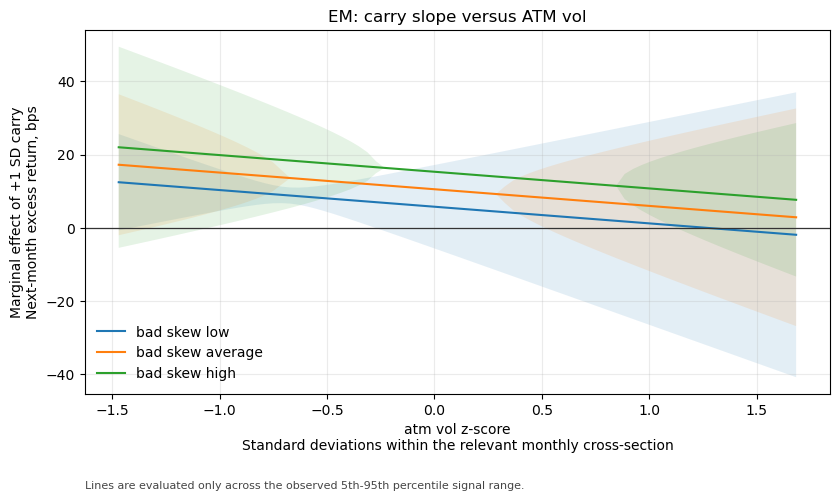

In [16]:

def get_fit_key(sample):
    spec = "asset-class monthly z-scores" if sample == "All" else "within-class monthly z-scores"
    return (sample, spec, "M4 both carry interactions")

def marginal_grid_for(sample):
    key = get_fit_key(sample)
    fit = fitted_models.get(key)
    used = fitted_data.get(key, pd.DataFrame())
    if fit is None or used.empty:
        return pd.DataFrame()
    names = fit.model.exog_names
    params = pd.Series(np.asarray(fit.params), index=names)
    cov = pd.DataFrame(np.asarray(fit.cov_params()), index=names, columns=names)
    rows=[]
    for v in [-1,0,1,2]:
        for s in [-1,0,1,2]:
            weights = {"carry":1.0, "carry_x_atm_vol":v, "carry_x_bad_skew":s}
            est = sum(weights[k]*params.get(k,0) for k in weights)
            keys=list(weights); w=np.array([weights[k] for k in keys], dtype=float)
            se=math.sqrt(max(float(w @ cov.reindex(index=keys, columns=keys).fillna(0).to_numpy() @ w),0.0))
            rows.append({"sample":sample, "atm_vol_z":v, "bad_skew_z":s, "marginal_carry_effect":est, "monthly_bps":est*10000, "se":se, "ci_low":est-1.96*se, "ci_high":est+1.96*se, "ci_low_bps":(est-1.96*se)*10000, "ci_high_bps":(est+1.96*se)*10000, "unconditional_return_std": used[Y_COL].std(ddof=1), "effect_vs_return_std": est/used[Y_COL].std(ddof=1) if used[Y_COL].std(ddof=1)>0 else np.nan})
    return pd.DataFrame(rows)

marginal_effects = pd.concat([marginal_grid_for(s) for s in ["All", "G10", "EM"]], ignore_index=True)
display(marginal_effects.style.format({"marginal_carry_effect":"{:+.5f}", "monthly_bps":"{:+.1f}", "se":"{:.5f}", "ci_low_bps":"{:+.1f}", "ci_high_bps":"{:+.1f}", "effect_vs_return_std":"{:+.2f}"}) if not marginal_effects.empty else marginal_effects)

# Incremental model fit and nested comparisons.
fit_summary = regression_results[regression_results["variable"].eq("const")][["sample", "specification", "model", "observations", "adj_r_squared", "aic", "bic"]].drop_duplicates()
fit_summary = fit_summary.sort_values(["sample", "specification", "model"])
fit_summary["delta_adj_r2_vs_M1"] = fit_summary.groupby(["sample", "specification"])["adj_r_squared"].transform(lambda s: s - s[fit_summary.loc[s.index, "model"].eq("M1 main effects")].iloc[0] if fit_summary.loc[s.index, "model"].eq("M1 main effects").any() else np.nan)
display(Markdown("### Model fit and incremental adjusted R-squared")); display(fit_summary.head(120).style.format({"adj_r_squared":"{:.4f}", "delta_adj_r2_vs_M1":"{:+.4f}", "aic":"{:.1f}", "bic":"{:.1f}"}))

if plt is not None:
    for sample in ["All", "G10", "EM"]:
        key = get_fit_key(sample); fit = fitted_models.get(key); used = fitted_data.get(key, pd.DataFrame())
        if fit is None or used.empty: continue
        names = fit.model.exog_names; params = pd.Series(np.asarray(fit.params), index=names); cov = pd.DataFrame(np.asarray(fit.cov_params()), index=names, columns=names)
        for xvar, fixed_var, title_tail in [("bad_skew", "atm_vol", "carry slope versus bad skew"), ("atm_vol", "bad_skew", "carry slope versus ATM vol")]:
            lo, hi = used[xvar].quantile([.05,.95])
            xs = np.linspace(lo, hi, 80)
            fig, ax = plt.subplots(figsize=(8.5,5.2))
            for fixed_level, lab in [(-1,"low"),(0,"average"),(1,"high")]:
                vals=[]; lows=[]; highs=[]
                for x in xs:
                    v = fixed_level if fixed_var=="atm_vol" else x
                    s = fixed_level if fixed_var=="bad_skew" else x
                    weights={"carry":1.0,"carry_x_atm_vol":v,"carry_x_bad_skew":s}
                    keys=list(weights); w=np.array([weights[k] for k in keys], dtype=float)
                    est=sum(weights[k]*params.get(k,0) for k in keys)
                    se=math.sqrt(max(float(w @ cov.reindex(index=keys, columns=keys).fillna(0).to_numpy() @ w),0.0))
                    vals.append(est); lows.append(est-1.96*se); highs.append(est+1.96*se)
                ax.plot(xs, np.array(vals) * 10000, label=f"{fixed_var.replace('_', ' ')} {lab}")
                ax.fill_between(xs, np.array(lows) * 10000, np.array(highs) * 10000, alpha=.12)
            ax.axhline(0,color="#333",lw=.9)
            ax.set_title(f"{sample}: {title_tail}")
            ax.set_xlabel(f"{xvar.replace('_', ' ')} z-score\nStandard deviations within the relevant monthly cross-section")
            ax.set_ylabel("Marginal effect of +1 SD carry\nNext-month excess return, bps")
            ax.grid(alpha=.25); ax.legend(frameon=False)
            ax.text(0.0, -0.24, "Lines are evaluated only across the observed 5th-95th percentile signal range.", transform=ax.transAxes, ha="left", va="top", fontsize=8, color="#444444")
            plt.tight_layout(); savefig(fig, f"marginal_{sample}_{title_tail.replace(' ','_')}.png"); plt.show()
successful_sections.append("marginal effects and economic magnitude")


## Nonlinearity, Downside, Robustness, Influence, and Pseudo-Out-of-Sample Checks

These are predeclared robustness and diagnostic checks, not specification search. They help distinguish mean-return relationships from downside-risk relationships and reveal whether interaction estimates are driven by a few currencies or periods.


Running robustness, downside, influence, and pseudo-out-of-sample diagnostics...


### Robustness coefficient table

,sample,model,specification,robustness_check,excluded_currency,variable,coefficient,two_way_cluster_t,two_way_cluster_p,observations
0,All,carry x skew top quintile,nonlinearity,carry x skew top quintile,nan,carry_x_skew_top_q,+0.00222,+2.88,0.009,4840
1,All,carry x vol top quintile,nonlinearity,carry x vol top quintile,nan,carry_x_vol_top_q,+0.00194,+1.06,0.302,4840
2,G10,carry x skew top quintile,nonlinearity,carry x skew top quintile,nan,carry_x_skew_top_q,+0.00339,+1.63,0.141,2097
3,G10,carry x vol top quintile,nonlinearity,carry x vol top quintile,nan,carry_x_vol_top_q,+0.00629,+3.78,0.005,2097
4,EM,carry x skew top quintile,nonlinearity,carry x skew top quintile,nan,carry_x_skew_top_q,+0.00263,+2.14,0.055,2743
5,EM,carry x vol top quintile,nonlinearity,carry x vol top quintile,nan,carry_x_vol_top_q,-0.00139,-1.10,0.294,2743
6,All,probability future loss LPM,downside LPM,probability future loss LPM,nan,atm_vol,+0.00252,+0.20,0.844,4840
7,All,probability future loss LPM,downside LPM,probability future loss LPM,nan,bad_skew,+0.00156,+0.12,0.905,4840
8,All,probability future loss LPM,downside LPM,probability future loss LPM,nan,carry_x_atm_vol,-0.00600,-0.41,0.688,4840
9,All,probability future loss LPM,downside LPM,probability future loss LPM,nan,carry_x_bad_skew,-0.01302,-1.43,0.168,4840


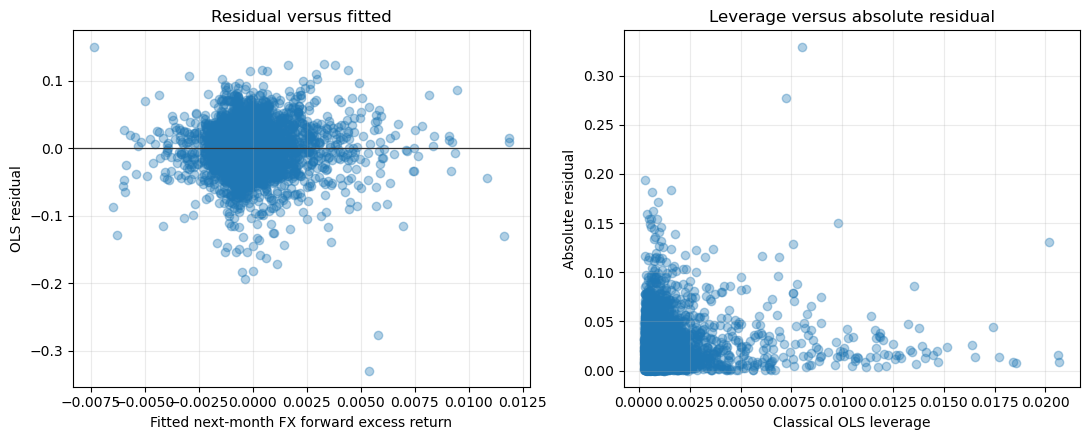

### Largest classical OLS influence observations

,month_end,currency,asset_class,carry_signal_1m,atm_vol_1m,bad_skew25_1m,realized_1m_forward_excess_return,fitted,residual,abs_residual,cooks_distance,leverage
0,2021-10-31 00:00:00,CHF,G10,-0.078%,5.97,+0.10,-0.38%,-0.000139,-0.37%,0.003691,0.1411,0.0017
1,2018-07-31 00:00:00,CHF,G10,-0.264%,5.54,-0.39,+1.92%,0.001073,+1.81%,0.018137,0.0902,0.0019
2,2023-05-31 00:00:00,CHF,G10,-0.361%,7.22,-0.28,+1.31%,-0.000044,+1.32%,0.013157,0.0575,0.0009
3,2008-11-30 00:00:00,PLN,EM,+0.258%,37.71,+6.34,+0.56%,-0.001001,+0.66%,0.006609,0.0361,0.0006
4,2008-10-31 00:00:00,PLN,EM,+0.198%,45.40,+5.24,-6.83%,-0.001245,-6.70%,0.067038,0.0203,0.0008
5,2018-08-31 00:00:00,CHF,G10,-0.256%,6.66,-0.31,-1.57%,0.000339,-1.60%,0.016024,0.0163,0.0012
6,2015-02-28 00:00:00,INR,EM,+0.548%,6.75,+1.03,-0.50%,-0.000497,-0.45%,0.004516,0.0149,0.0014
7,2011-08-31 00:00:00,NOK,G10,+0.173%,13.97,+2.58,-8.73%,-0.000156,-8.72%,0.087156,0.0132,0.0003
8,2018-09-30 00:00:00,CHF,G10,-0.276%,6.62,-0.34,-2.97%,0.000050,-2.97%,0.029746,0.0103,0.0012
9,2008-12-31 00:00:00,PLN,EM,+0.395%,41.79,+7.46,-15.56%,-0.001305,-15.43%,0.154328,0.0097,0.0009


### Pseudo-out-of-sample forecast diagnostics

,sample,model,observations,rmse,oos_r2_vs_zero
0,All,M0 carry only,3633,0.0288,-0.0073
1,All,M1 main effects,3633,0.0288,-0.0081
2,All,M4 both carry interactions,3633,0.0288,-0.0130
3,EM,M0 carry only,2076,0.0301,-0.0072
4,EM,M1 main effects,2076,0.0301,-0.0083
5,EM,M4 both carry interactions,2076,0.0302,-0.0152
6,G10,M0 carry only,1557,0.0268,-0.0069
7,G10,M1 main effects,1557,0.0269,-0.0100
8,G10,M4 both carry interactions,1557,0.0269,-0.0139


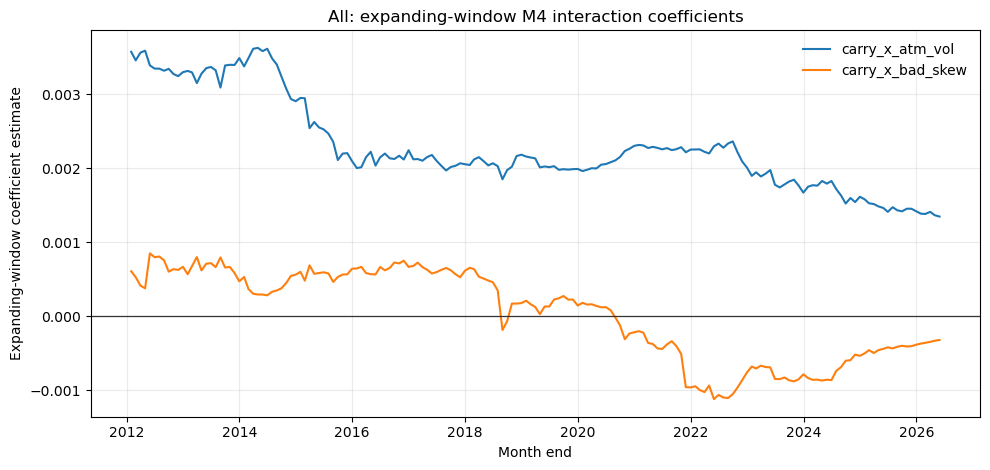

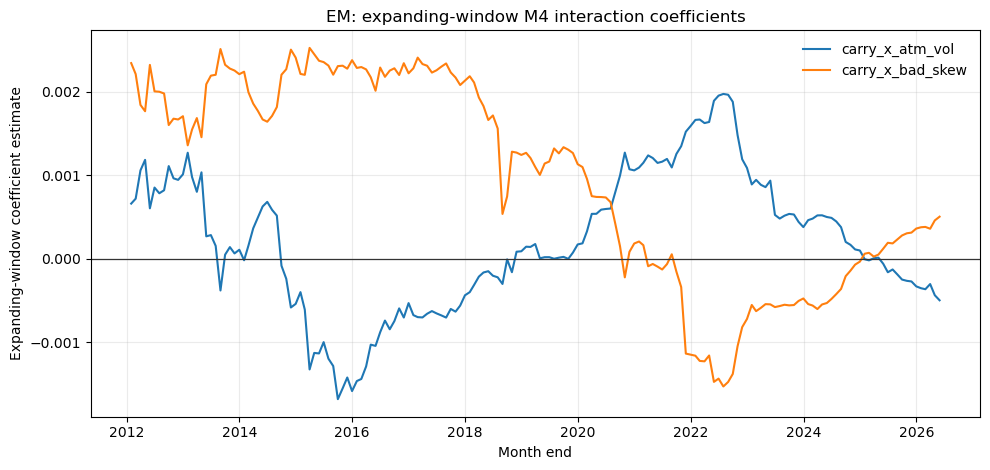

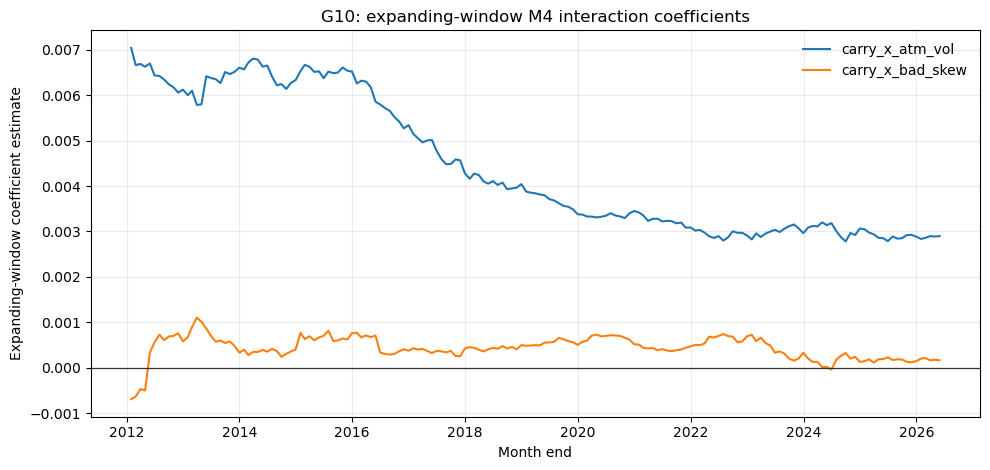

In [17]:

print("Running robustness, downside, influence, and pseudo-out-of-sample diagnostics...")
robustness_rows=[]
influence_rows=[]
oos_rows=[]

# Nonlinearity checks: carry slope by top-quintile indicators and quintile dummies.
nonlin = add_design_columns(cond_panel, suffix="class")
nonlin["skew_top_q"] = (nonlin["q_skew_class"].eq(5)).astype(float)
nonlin["vol_top_q"] = (nonlin["q_vol_class"].eq(5)).astype(float)
nonlin["carry_x_skew_top_q"] = nonlin["carry"] * nonlin["skew_top_q"]
nonlin["carry_x_vol_top_q"] = nonlin["carry"] * nonlin["vol_top_q"]
for sample, df in {"All": nonlin, "G10": nonlin[nonlin["asset_class"].eq("G10")], "EM": nonlin[nonlin["asset_class"].eq("EM")]}.items():
    for label, xcols in [("carry x skew top quintile", ["carry","atm_vol","bad_skew","skew_top_q","carry_x_skew_top_q"]), ("carry x vol top quintile", ["carry","atm_vol","bad_skew","vol_top_q","carry_x_vol_top_q"] )]:
        res, _, _ = fit_ols_with_inference(df, Y_COL, xcols, sample, label, "nonlinearity")
        if not res.empty:
            target = xcols[-1]
            robustness_rows.append(res[res["variable"].eq(target)].assign(robustness_check=label))

# Downside analyses.
downside = add_design_columns(z_panel, suffix="class")
full_q10 = downside[Y_COL].quantile(.10)
downside["severe_loss_full"] = (downside[Y_COL] <= full_q10).astype(float)
downside["severe_loss_class"] = downside.groupby("asset_class")[Y_COL].transform(lambda s: s <= s.quantile(.10)).astype(float)
for ybin, label in [("future_loss", "probability future loss LPM"), ("severe_loss_full", "probability severe loss full-sample threshold LPM"), ("severe_loss_class", "probability severe loss asset-class threshold LPM")]:
    for sample, df in {"All": downside, "G10": downside[downside["asset_class"].eq("G10")], "EM": downside[downside["asset_class"].eq("EM")]}.items():
        res, _, _ = fit_ols_with_inference(df, ybin, MODEL_TERMS["M4 both carry interactions"], sample, label, "downside LPM", min_obs=40)
        if not res.empty:
            robustness_rows.append(res[res["variable"].isin(["carry_x_atm_vol","carry_x_bad_skew","atm_vol","bad_skew"])].assign(robustness_check=label))
# Quantile regressions, no clustered inference.
if STATSMODELS_AVAILABLE:
    for q in [.10,.25,.50]:
        df = downside.dropna(subset=[Y_COL]+MODEL_TERMS["M4 both carry interactions"]).copy()
        if len(df) >= 80:
            try:
                X = sm.add_constant(df[MODEL_TERMS["M4 both carry interactions"]], has_constant="add")
                fit = sm.QuantReg(df[Y_COL], X).fit(q=q, max_iter=2000)
                for var in ["carry", "atm_vol", "bad_skew", "carry_x_atm_vol", "carry_x_bad_skew"]:
                    robustness_rows.append(pd.DataFrame([{"sample":"All", "model":f"quantile {q:.2f}", "specification":"quantile regression no clustered inference", "variable":var, "coefficient":fit.params.get(var,np.nan), "two_way_cluster_t":np.nan, "two_way_cluster_p":np.nan, "observations":len(df), "robustness_check":f"quantile {q:.2f}"}]))
            except Exception as exc:
                skipped_models.append({"section":"quantile regression", "q":q, "reason":repr(exc)})

# Predeclared M4 robustness checks.
def extract_interactions(res, check):
    if res.empty: return pd.DataFrame()
    return res[res["variable"].isin(["carry_x_atm_vol","carry_x_bad_skew"])].copy().assign(robustness_check=check)

base_m4 = {"All": z_panel, "G10": z_panel[z_panel["asset_class"].eq("G10")], "EM": z_panel[z_panel["asset_class"].eq("EM")]}
for sample, df in base_m4.items():
    specs = [
        ("raw variables", add_design_columns(df, raw=True)),
        ("monthly z-scores", add_design_columns(df, suffix="all" if sample=="All" else "class")),
        ("asset-class monthly z-scores", add_design_columns(df, suffix="class")),
        ("monthly rank transform", add_design_columns(df, rank=True)),
    ]
    for check, dfx in specs:
        res, _, _ = fit_ols_with_inference(dfx, Y_COL, MODEL_TERMS["M4 both carry interactions"], sample, "M4 robustness", check)
        robustness_rows.append(extract_interactions(res, check))
    for wlo, whi, check in [(0.01,0.99,"monthly 1/99 winsorization"),(0.05,0.95,"monthly 5/95 winsorization")]:
        dfx=df.copy()
        for col in SIGNAL_MAP.values():
            dfx[col]=dfx.groupby("month_end")[col].transform(lambda s: s.clip(s.quantile(wlo), s.quantile(whi)) if s.notna().sum()>=5 else s)
        # Recompute class z-scores after winsorization.
        tmp=dfx.copy()
        for keys, sub in tmp.groupby(["month_end", "asset_class"]):
            for name, col in SIGNAL_MAP.items():
                z,_=safe_group_zscore_missing(sub[col], MIN_Z_N_CLASS)
                tmp.loc[sub.index, f"z_{name}_class"] = z
        dfx=add_design_columns(tmp, suffix="class")
        res, _, _ = fit_ols_with_inference(dfx, Y_COL, MODEL_TERMS["M4 both carry interactions"], sample, "M4 robustness", check)
        robustness_rows.append(extract_interactions(res, check))

# Currency exclusions and sample splits for All.
all_df = z_panel.copy()
for ccy in sorted(all_df["currency"].dropna().unique()):
    res, _, _ = fit_ols_with_inference(add_design_columns(all_df[~all_df["currency"].eq(ccy)], suffix="class"), Y_COL, MODEL_TERMS["M4 both carry interactions"], "All", "M4 leave-one-currency-out", f"excluding {ccy}")
    tmp=extract_interactions(res, f"excluding {ccy}"); tmp["excluded_currency"] = ccy; robustness_rows.append(tmp)
for ccy in ["TRY","BRL","ZAR","MXN"]:
    if ccy in all_df["currency"].unique():
        res, _, _ = fit_ols_with_inference(add_design_columns(all_df[~all_df["currency"].eq(ccy)], suffix="class"), Y_COL, MODEL_TERMS["M4 both carry interactions"], "All", "M4 focused exclusion", f"excluding {ccy}")
        tmp=extract_interactions(res, f"excluding {ccy}"); tmp["excluded_currency"] = ccy; robustness_rows.append(tmp)

CRISIS_WINDOWS = [("2008 GFC","2008-07-31","2009-03-31"),("2013 taper","2013-05-31","2013-09-30"),("2015 EM China","2015-06-30","2016-02-29"),("2020 Covid","2020-02-29","2020-04-30"),("2022 dollar rates","2022-01-31","2022-10-31")]
crisis_months=set()
for _,a,b in CRISIS_WINDOWS:
    crisis_months.update(pd.date_range(pd.Timestamp(a), pd.Timestamp(b), freq="ME"))
all_df["is_crisis"] = all_df["month_end"].isin(crisis_months)
for label, sub in [("excluding crisis months", all_df[~all_df["is_crisis"]]), ("crisis months only", all_df[all_df["is_crisis"]])]:
    res, _, _ = fit_ols_with_inference(add_design_columns(sub, suffix="class"), Y_COL, MODEL_TERMS["M4 both carry interactions"], "All", "M4 crisis split", label)
    robustness_rows.append(extract_interactions(res, label))
months_sorted=sorted(all_df["month_end"].unique())
mid=months_sorted[len(months_sorted)//2]
for label, sub in [("first half", all_df[all_df["month_end"]<mid]), ("second half", all_df[all_df["month_end"]>=mid]), ("pre-2020", all_df[all_df["month_end"]<pd.Timestamp("2020-01-31")]), ("post-2020", all_df[all_df["month_end"]>=pd.Timestamp("2020-01-31")])]:
    res, _, _ = fit_ols_with_inference(add_design_columns(sub, suffix="class"), Y_COL, MODEL_TERMS["M4 both carry interactions"], "All", "M4 sample split", label)
    robustness_rows.append(extract_interactions(res, label))
# 10D and butterfly control.
if z_panel["bad_skew10_1m"].notna().sum() > 50:
    tmp=z_panel.copy(); tmp["bad_skew25_1m"] = tmp["bad_skew10_1m"]
    for keys, sub in tmp.groupby(["month_end","asset_class"]):
        z,_=safe_group_zscore_missing(sub["bad_skew25_1m"], MIN_Z_N_CLASS); tmp.loc[sub.index,"z_bad_skew_class"] = z
    tmp=add_design_columns(tmp, suffix="class")
    res,_,_=fit_ols_with_inference(tmp, Y_COL, MODEL_TERMS["M4 both carry interactions"], "All", "M4 10D bad skew", "25D replaced by 10D")
    robustness_rows.append(extract_interactions(res, "25D replaced by 10D"))
res,_,_=fit_ols_with_inference(add_design_columns(z_panel, suffix="class"), Y_COL, MODEL_TERMS["M4 both carry interactions"]+["z_bf25_class"], "All", "M4 plus butterfly control", "asset-class monthly z-scores")
robustness_rows.append(extract_interactions(res, "adding butterfly control"))

robustness_results = pd.concat([x for x in robustness_rows if isinstance(x, pd.DataFrame) and not x.empty], ignore_index=True, sort=False) if robustness_rows else pd.DataFrame()
display(Markdown("### Robustness coefficient table")); display(robustness_results[[c for c in ["sample","model","specification","robustness_check","excluded_currency","variable","coefficient","two_way_cluster_t","two_way_cluster_p","observations"] if c in robustness_results]].head(180).style.format({"coefficient":"{:+.5f}", "two_way_cluster_t":"{:+.2f}", "two_way_cluster_p":"{:.3f}"}) if not robustness_results.empty else robustness_results)

# Influence diagnostics under classical All M4.
try:
    used = fitted_data[("All", "asset-class monthly z-scores", "M4 both carry interactions")]
    fit_classical = sm.OLS(used[Y_COL], sm.add_constant(used[MODEL_TERMS["M4 both carry interactions"]], has_constant="add")).fit()
    infl = OLSInfluence(fit_classical)
    influence_df = used[["month_end","currency"]].copy()
    influence_df = influence_df.merge(z_panel[["month_end","currency","asset_class","carry_signal_1m","atm_vol_1m","bad_skew25_1m",Y_COL]], on=["month_end","currency"], how="left")
    influence_df["fitted"] = fit_classical.fittedvalues.values
    influence_df["residual"] = fit_classical.resid.values
    influence_df["abs_residual"] = influence_df["residual"].abs()
    influence_df["cooks_distance"] = infl.cooks_distance[0]
    influence_df["leverage"] = infl.hat_matrix_diag
    influence_rows.append(influence_df.sort_values("cooks_distance", ascending=False).head(50))
    if plt is not None:
        fig, axes = plt.subplots(1,2,figsize=(11,4.5))
        axes[0].scatter(influence_df["fitted"], influence_df["residual"], alpha=.35)
        axes[0].axhline(0,color="#333",lw=.9)
        axes[0].set_title("Residual versus fitted")
        axes[0].set_xlabel("Fitted next-month FX forward excess return")
        axes[0].set_ylabel("OLS residual")
        axes[1].scatter(influence_df["leverage"], influence_df["abs_residual"], alpha=.35)
        axes[1].set_title("Leverage versus absolute residual")
        axes[1].set_xlabel("Classical OLS leverage")
        axes[1].set_ylabel("Absolute residual")
        for ax in axes: ax.grid(alpha=.25)
        plt.tight_layout(); savefig(fig,"influence_residual_leverage.png"); plt.show()
except Exception as exc:
    skipped_models.append({"section":"influence diagnostics", "reason":repr(exc)})
influence_results = pd.concat(influence_rows, ignore_index=True, sort=False) if influence_rows else pd.DataFrame()
display(Markdown("### Largest classical OLS influence observations")); display(influence_results.head(30).style.format({"carry_signal_1m":"{:+.3%}", "atm_vol_1m":"{:.2f}", "bad_skew25_1m":"{:+.2f}", Y_COL:"{:+.2%}", "residual":"{:+.2%}", "cooks_distance":"{:.4f}", "leverage":"{:.4f}"}) if not influence_results.empty else influence_results)

# Pseudo-out-of-sample expanding-window predictions, regression diagnostics only.
def oos_expanding(df, sample):
    d0 = df.sort_values(["month_end","currency"]).copy()
    months=sorted(d0["month_end"].unique())
    rows=[]; coef_rows=[]
    if len(months) <= ROLLING_MIN_TRAIN_MONTHS + 3:
        skipped_models.append({"section":"pseudo out of sample", "sample":sample, "reason":"insufficient months", "months":len(months)})
        return pd.DataFrame(), pd.DataFrame()
    for t in months[ROLLING_MIN_TRAIN_MONTHS:]:
        train = add_design_columns(d0[d0["month_end"] < t], suffix="class")
        test = add_design_columns(d0[d0["month_end"].eq(t)], suffix="class")
        if train["month_end"].nunique() < ROLLING_MIN_TRAIN_MONTHS or len(test) < 3: continue
        for model_name in ["M0 carry only", "M1 main effects", "M4 both carry interactions"]:
            terms=MODEL_TERMS[model_name]
            tr=train.dropna(subset=[Y_COL]+terms); te=test.dropna(subset=[Y_COL]+terms)
            if len(tr)<40 or te.empty: continue
            try:
                fit=sm.OLS(tr[Y_COL], sm.add_constant(tr[terms], has_constant="add")).fit()
                Xte=sm.add_constant(te[terms], has_constant="add")
                pred=fit.predict(Xte)
                for idx,val in zip(te.index,pred):
                    rows.append({"sample":sample,"month_end":te.loc[idx,"month_end"],"currency":te.loc[idx,"currency"],"model":model_name,"prediction":val,"actual":te.loc[idx,Y_COL],"train_months":tr["month_end"].nunique()})
                if model_name == "M4 both carry interactions":
                    coef_rows.append({"sample":sample,"month_end":t,"train_months":tr["month_end"].nunique(), **{f"coef_{k}":v for k,v in fit.params.items()}})
            except Exception:
                continue
    return pd.DataFrame(rows), pd.DataFrame(coef_rows)

oos_parts=[]; coef_paths=[]
for sample, df in [("All", z_panel), ("G10", z_panel[z_panel["asset_class"].eq("G10")]), ("EM", z_panel[z_panel["asset_class"].eq("EM")])]:
    pred, coef = oos_expanding(df, sample)
    if not pred.empty: oos_parts.append(pred)
    if not coef.empty: coef_paths.append(coef)
oos_predictions = pd.concat(oos_parts, ignore_index=True) if oos_parts else pd.DataFrame()
oos_coefficient_paths = pd.concat(coef_paths, ignore_index=True) if coef_paths else pd.DataFrame()
if not oos_predictions.empty:
    oos_eval=[]
    for sample, sub in oos_predictions.groupby("sample"):
        pivot=sub.pivot_table(index=["month_end","currency"], columns="model", values="prediction")
        actual=sub.groupby(["month_end","currency"])["actual"].first()
        zero_rmse=math.sqrt(float((actual**2).mean()))
        for model in pivot.columns:
            err=actual.loc[pivot.index]-pivot[model]
            rmse=math.sqrt(float((err**2).mean()))
            oos_eval.append({"sample":sample,"model":model,"observations":len(err),"rmse":rmse,"oos_r2_vs_zero":1-(rmse**2)/(zero_rmse**2) if zero_rmse>0 else np.nan})
    oos_evaluation=pd.DataFrame(oos_eval)
else:
    oos_evaluation=pd.DataFrame()
display(Markdown("### Pseudo-out-of-sample forecast diagnostics")); display(oos_evaluation.style.format({"rmse":"{:.4f}", "oos_r2_vs_zero":"{:+.4f}"}) if not oos_evaluation.empty else oos_evaluation)
if plt is not None and not oos_coefficient_paths.empty:
    for sample, sub in oos_coefficient_paths.groupby("sample"):
        fig, ax = plt.subplots(figsize=(10,4.8))
        for col in ["coef_carry_x_atm_vol","coef_carry_x_bad_skew"]:
            if col in sub: ax.plot(sub["month_end"], sub[col], label=col.replace("coef_", ""))
        ax.axhline(0,color="#333",lw=.9)
        ax.set_title(f"{sample}: expanding-window M4 interaction coefficients")
        ax.set_xlabel("Month end")
        ax.set_ylabel("Expanding-window coefficient estimate")
        ax.grid(alpha=.25); ax.legend(frameon=False)
        plt.tight_layout(); savefig(fig, f"oos_coefficients_{sample}.png"); plt.show()
successful_sections.append("robustness, influence, downside, and pseudo-out-of-sample diagnostics")


## Comprehensive Model Comparison

The large comparison tables below preserve the full M0-M6 overview after the individual model sections. Compact narrative tables above use only preferred two-way clustered inference; the saved regression output retains all inference methods.

In [18]:

model_comparison_tables=[]
for sample in ["All", "G10", "EM"]:
    spec = "asset-class monthly z-scores" if sample == "All" else "within-class monthly z-scores"
    sub = regression_results[(regression_results["sample"].eq(sample)) & (regression_results["specification"].eq(spec)) & (regression_results["variable"].isin(["carry","atm_vol","bad_skew","carry_x_atm_vol","carry_x_bad_skew","atm_vol_x_bad_skew","carry_x_atm_vol_x_bad_skew"]))]
    model_comparison_tables.append(sub.assign(primary_specification=True))
model_comparison_table = pd.concat(model_comparison_tables, ignore_index=True) if model_comparison_tables else pd.DataFrame()
display(model_comparison_table[["sample","model","variable","coefficient","two_way_cluster_t","stars","observations","adj_r_squared"]].style.format({"coefficient":"{:+.5f}", "two_way_cluster_t":"{:+.2f}", "adj_r_squared":"{:.4f}"}) if not model_comparison_table.empty else model_comparison_table)

interaction_improvement = fit_summary[fit_summary["model"].isin(["M1 main effects","M2 carry x bad skew","M3 carry x ATM vol","M4 both carry interactions"])].copy()
interaction_improvement = interaction_improvement.sort_values(["sample","specification","model"])
display(Markdown("### Incremental fit from option interactions")); display(interaction_improvement.style.format({"adj_r_squared":"{:.4f}", "delta_adj_r2_vs_M1":"{:+.4f}", "aic":"{:.1f}", "bic":"{:.1f}"}))


,sample,model,variable,coefficient,two_way_cluster_t,stars,observations,adj_r_squared
0,All,M0 carry only,carry,+0.00083,+2.06,*,4840,0.0005
1,All,M1 main effects,carry,+0.00098,+3.44,***,4840,0.0001
2,All,M1 main effects,atm_vol,+0.00021,+0.36,,4840,0.0001
3,All,M1 main effects,bad_skew,-0.00035,-0.61,,4840,0.0001
4,All,M2 carry x bad skew,carry,+0.00087,+2.46,**,4840,-0.0000
5,All,M2 carry x bad skew,atm_vol,+0.00019,+0.30,,4840,-0.0000
6,All,M2 carry x bad skew,bad_skew,-0.00032,-0.52,,4840,-0.0000
7,All,M2 carry x bad skew,carry_x_bad_skew,+0.00022,+0.91,,4840,-0.0000
8,All,M3 carry x ATM vol,carry,+0.00066,+1.81,*,4840,0.0011
9,All,M3 carry x ATM vol,atm_vol,+0.00022,+0.45,,4840,0.0011


### Incremental fit from option interactions

,sample,specification,model,observations,adj_r_squared,aic,bic,delta_adj_r2_vs_M1
39,All,all-universe monthly z-scores,M1 main effects,4840,0.0004,-19485.8,-19459.8,+0.0000
43,All,all-universe monthly z-scores,M2 carry x bad skew,4840,0.0002,-19483.8,-19451.3,-0.0002
48,All,all-universe monthly z-scores,M3 carry x ATM vol,4840,0.0002,-19483.9,-19451.5,-0.0002
53,All,all-universe monthly z-scores,M4 both carry interactions,4840,0.0000,-19482.0,-19443.1,-0.0004
76,All,asset-class monthly z-scores,M1 main effects,4840,0.0001,-19484.3,-19458.3,+0.0000
80,All,asset-class monthly z-scores,M2 carry x bad skew,4840,-0.0000,-19482.7,-19450.2,-0.0001
85,All,asset-class monthly z-scores,M3 carry x ATM vol,4840,0.0011,-19487.9,-19455.5,+0.0010
90,All,asset-class monthly z-scores,M4 both carry interactions,4840,0.0010,-19486.4,-19447.5,+0.0009
2,All,raw levels,M1 main effects,4840,0.0020,-19493.7,-19467.8,+0.0000
6,All,raw levels,M2 carry x bad skew,4840,0.0029,-19496.7,-19464.3,+0.0008


## Interpretation: How Do Option Signals Condition Carry?

The text below is generated from the computed tables. It uses cautious language and does not select or optimize any strategy.


In [19]:

def row_for(df, sample, spec, model, var):
    if df.empty: return None
    sub=df[(df["sample"].eq(sample)) & (df["specification"].eq(spec)) & (df["model"].eq(model)) & (df["variable"].eq(var))]
    return sub.iloc[0] if not sub.empty else None

def fmt_coef(row):
    if row is None: return "unavailable"
    return f"{row['coefficient']:+.5f} (two-way t={row['two_way_cluster_t']:+.2f}, p={row['two_way_cluster_p']:.3f})"

def evidence_word(row):
    if row is None or pd.isna(row.get("two_way_cluster_p", np.nan)): return "unavailable"
    p=row["two_way_cluster_p"]
    return "robust" if p<0.05 else "borderline" if p<0.10 else "weak"

interp_lines=[]
for sample in ["All","G10","EM"]:
    spec = "asset-class monthly z-scores" if sample == "All" else "within-class monthly z-scores"
    carry = row_for(regression_results, sample, spec, "M0 carry only", "carry")
    atm = row_for(regression_results, sample, spec, "M1 main effects", "atm_vol")
    skew = row_for(regression_results, sample, spec, "M1 main effects", "bad_skew")
    cv = row_for(regression_results, sample, spec, "M4 both carry interactions", "carry_x_atm_vol")
    cs = row_for(regression_results, sample, spec, "M4 both carry interactions", "carry_x_bad_skew")
    b0 = row_for(butterfly_regression_results, sample, spec, "B0 butterfly standalone control", "bf25") if "butterfly_regression_results" in globals() else None
    cb = row_for(butterfly_regression_results, sample, spec, "B3 joint three-conditioner model", "carry_x_bf25") if "butterfly_regression_results" in globals() else None
    cv_b1 = row_for(butterfly_regression_results, sample, spec, "B1 butterfly control added to M4", "carry_x_atm_vol") if "butterfly_regression_results" in globals() else None
    cs_b1 = row_for(butterfly_regression_results, sample, spec, "B1 butterfly control added to M4", "carry_x_bad_skew") if "butterfly_regression_results" in globals() else None
    interp_lines.append(f"- **{sample}:** carry-only slope is {fmt_coef(carry)}. ATM-vol main effect is {fmt_coef(atm)} and bad-skew main effect is {fmt_coef(skew)}. In M4, carry × ATM vol is {fmt_coef(cv)} and carry × bad skew is {fmt_coef(cs)}.")
    interp_lines.append(f"  Butterfly standalone effect in B0 is {fmt_coef(b0)}; carry × butterfly in B3 is {fmt_coef(cb)}. After adding butterfly in B1, carry × ATM-vol is {fmt_coef(cv_b1)} and carry × bad-skew is {fmt_coef(cs_b1)}.")
if not heterogeneity_compact.empty:
    for nm in ["EM minus G10 carry x ATM-vol", "EM minus G10 carry x bad-skew"]:
        r = heterogeneity_compact[heterogeneity_compact["estimate_name"].eq(nm)]
        if not r.empty:
            x = r.iloc[0]
            interp_lines.append(f"- Formal heterogeneity test for {nm}: estimate {x['estimate']:+.5f}, p={x['two_way_p']:.3f}. This is the appropriate test for EM-versus-G10 differences.")
if "butterfly_risk_results" in globals() and not butterfly_risk_results.empty:
    risk_sig = butterfly_risk_results[(butterfly_risk_results["variable"].isin(["bf25","carry_x_bf25"])) & (butterfly_risk_results.get("two_way_cluster_p", pd.Series(np.nan, index=butterfly_risk_results.index)) < 0.10)]
    interp_lines.append(f"- Butterfly future-risk tests produce {len(risk_sig)} butterfly-related rows with two-way clustered p-values below 0.10 across absolute-return, squared-return, negative-return, severe-loss, and lower-tail diagnostics. This distinguishes mean-return information from risk information.")
if not robustness_results.empty:
    for var in ["carry_x_atm_vol", "carry_x_bad_skew"]:
        sub=robustness_results[robustness_results["variable"].eq(var)]
        if not sub.empty:
            base=row_for(regression_results,"All","asset-class monthly z-scores","M4 both carry interactions",var)
            share = (np.sign(sub["coefficient"].dropna()) == np.sign(base["coefficient"])).mean() if base is not None else np.nan
            interp_lines.append(f"- Robustness sign stability for {var}: {share:.0%} of available checks have the same sign as the All-sample primary M4 estimate.")
if "butterfly_robustness" in globals() and not butterfly_robustness.empty:
    for var in ["bf25", "carry_x_bf25"]:
        sub=butterfly_robustness[butterfly_robustness["variable"].eq(var)]
        if not sub.empty:
            interp_lines.append(f"- Butterfly robustness for {var}: median coefficient {sub['coefficient'].median():+.5f}; {int((sub['two_way_cluster_p']<0.10).sum())} checks have p<0.10 where clustered p-values are available.")
if not oos_evaluation.empty:
    m4 = oos_evaluation[oos_evaluation["model"].eq("M4 both carry interactions")]
    for _, r in m4.iterrows():
        interp_lines.append(f"- Pseudo-out-of-sample {r['sample']} M4 forecast diagnostic: RMSE {r['rmse']:.4f}, OOS R-squared versus zero forecast {r['oos_r2_vs_zero']:+.4f}. This is not a tradable backtest.")
interp_lines.append("- Candidate implications for the next notebook, not strategy conclusions: ATM vol may be more suitable for portfolio-level scaling or a G10-specific carry conditioner; bad skew may be more useful for directional downside monitoring; butterfly may be more useful for tail-risk monitoring than mean-return prediction if its risk-outcome coefficients are stronger than its mean-return coefficients.")
interp_lines.append("- This notebook remains a regression and diagnostic study. It does not select or optimize any option-filtered carry strategy.")

display(Markdown("\n".join(interp_lines)))


- **All:** carry-only slope is +0.00083 (two-way t=+2.06, p=0.053). ATM-vol main effect is +0.00021 (two-way t=+0.36, p=0.726) and bad-skew main effect is -0.00035 (two-way t=-0.61, p=0.546). In M4, carry × ATM vol is +0.00134 (two-way t=+1.75, p=0.096) and carry × bad skew is -0.00029 (two-way t=-1.23, p=0.231).
  Butterfly standalone effect in B0 is -0.00052 (two-way t=-1.51, p=0.147); carry × butterfly in B3 is +0.00072 (two-way t=+2.05, p=0.054). After adding butterfly in B1, carry × ATM-vol is +0.00125 (two-way t=+1.59, p=0.128) and carry × bad-skew is -0.00010 (two-way t=-0.31, p=0.760).
- **G10:** carry-only slope is +0.00077 (two-way t=+1.64, p=0.141). ATM-vol main effect is -0.00007 (two-way t=-0.09, p=0.927) and bad-skew main effect is +0.00003 (two-way t=+0.04, p=0.966). In M4, carry × ATM vol is +0.00288 (two-way t=+3.74, p=0.006) and carry × bad skew is +0.00018 (two-way t=+0.42, p=0.689).
  Butterfly standalone effect in B0 is -0.00021 (two-way t=-0.37, p=0.718); carry × butterfly in B3 is +0.00075 (two-way t=+1.21, p=0.260). After adding butterfly in B1, carry × ATM-vol is +0.00288 (two-way t=+3.73, p=0.006) and carry × bad-skew is +0.00034 (two-way t=+0.89, p=0.398).
- **EM:** carry-only slope is +0.00088 (two-way t=+1.75, p=0.108). ATM-vol main effect is +0.00074 (two-way t=+1.74, p=0.110) and bad-skew main effect is -0.00099 (two-way t=+nan, p=nan). In M4, carry × ATM vol is -0.00045 (two-way t=-0.54, p=0.598) and carry × bad skew is +0.00048 (two-way t=+0.97, p=0.353).
  Butterfly standalone effect in B0 is -0.00095 (two-way t=-1.38, p=0.195); carry × butterfly in B3 is +0.00060 (two-way t=+1.02, p=0.329). After adding butterfly in B1, carry × ATM-vol is -0.00067 (two-way t=-0.81, p=0.437) and carry × bad-skew is +0.00075 (two-way t=+1.39, p=0.193).
- Formal heterogeneity test for EM minus G10 carry x ATM-vol: estimate -0.00333, p=0.008. This is the appropriate test for EM-versus-G10 differences.
- Formal heterogeneity test for EM minus G10 carry x bad-skew: estimate +0.00030, p=0.618. This is the appropriate test for EM-versus-G10 differences.
- Butterfly future-risk tests produce 7 butterfly-related rows with two-way clustered p-values below 0.10 across absolute-return, squared-return, negative-return, severe-loss, and lower-tail diagnostics. This distinguishes mean-return information from risk information.
- Robustness sign stability for carry_x_atm_vol: 78% of available checks have the same sign as the All-sample primary M4 estimate.
- Robustness sign stability for carry_x_bad_skew: 65% of available checks have the same sign as the All-sample primary M4 estimate.
- Butterfly robustness for bf25: median coefficient -0.00052; 3 checks have p<0.10 where clustered p-values are available.
- Butterfly robustness for carry_x_bf25: median coefficient +0.00072; 27 checks have p<0.10 where clustered p-values are available.
- Pseudo-out-of-sample All M4 forecast diagnostic: RMSE 0.0288, OOS R-squared versus zero forecast -0.0130. This is not a tradable backtest.
- Pseudo-out-of-sample EM M4 forecast diagnostic: RMSE 0.0302, OOS R-squared versus zero forecast -0.0152. This is not a tradable backtest.
- Pseudo-out-of-sample G10 M4 forecast diagnostic: RMSE 0.0269, OOS R-squared versus zero forecast -0.0139. This is not a tradable backtest.
- Candidate implications for the next notebook, not strategy conclusions: ATM vol may be more suitable for portfolio-level scaling or a G10-specific carry conditioner; bad skew may be more useful for directional downside monitoring; butterfly may be more useful for tail-risk monitoring than mean-return prediction if its risk-outcome coefficients are stronger than its mean-return coefficients.
- This notebook remains a regression and diagnostic study. It does not select or optimize any option-filtered carry strategy.

## Visualization Validation

This section programmatically audits figure labels and heatmap color conventions. Return heatmaps must use symmetric red-white-green limits centered at zero; count heatmaps must use a separate sequential scale.

In [20]:

figure_audit = pd.DataFrame(figure_audit_rows)
heatmap_validation = pd.DataFrame(heatmap_validation_rows)
if not heatmap_validation.empty:
    bad_heatmaps = heatmap_validation[(~heatmap_validation["symmetric_limits"]) | (heatmap_validation["return_cmap"].ne(RETURN_CMAP)) | (heatmap_validation["count_uses_return_cmap"])]
    if not bad_heatmaps.empty:
        raise AssertionError(f"Heatmap validation failed: {bad_heatmaps.head().to_dict('records')}")
if not figure_audit.empty:
    bad_axes = figure_audit[(~figure_audit["title_present"]) | (~figure_audit["xlabel_present"]) | (~figure_audit["ylabel_present"])]
    if not bad_axes.empty:
        raise AssertionError(f"Figure label audit failed: {bad_axes.head().to_dict('records')}")
visualization_audit_summary = pd.DataFrame([{
    "figures_audited": figure_audit["figure"].nunique() if not figure_audit.empty else 0,
    "axes_audited": len(figure_audit),
    "axes_with_titles": int(figure_audit["title_present"].sum()) if not figure_audit.empty else 0,
    "axes_with_xlabels": int(figure_audit["xlabel_present"].sum()) if not figure_audit.empty else 0,
    "axes_with_ylabels": int(figure_audit["ylabel_present"].sum()) if not figure_audit.empty else 0,
    "return_heatmaps_validated": len(heatmap_validation),
}])
display(visualization_audit_summary)
successful_sections.append("visualization label and heatmap color validation")


,figures_audited,axes_audited,axes_with_titles,axes_with_xlabels,axes_with_ylabels,return_heatmaps_validated
0,53,138,138,138,138,28


## Save Outputs

In [21]:

print("Saving regression-study outputs...")
# Concatenate regression-related tables for robust output.
regression_results.to_parquet(OUTPUTS["regression"], index=False)
fixed_effect_results.to_parquet(OUTPUTS["fixed_effects"], index=False)
heterogeneity_out = pd.concat([heterogeneity_results.assign(table="coefficient_table") if not heterogeneity_results.empty else pd.DataFrame(), heterogeneity_compact.assign(table="compact_wald_table") if not heterogeneity_compact.empty else pd.DataFrame()], ignore_index=True, sort=False)
heterogeneity_out.to_parquet(OUTPUTS["heterogeneity"], index=False)
marginal_effects.to_parquet(OUTPUTS["marginal"], index=False)
robustness_results.to_parquet(OUTPUTS["robustness"], index=False)
influence_results.to_parquet(OUTPUTS["influence"], index=False)
oos_out = pd.concat([oos_predictions.assign(table="predictions") if not oos_predictions.empty else pd.DataFrame(), oos_coefficient_paths.assign(table="coefficient_paths") if not oos_coefficient_paths.empty else pd.DataFrame(), oos_evaluation.assign(table="evaluation") if not oos_evaluation.empty else pd.DataFrame()], ignore_index=True, sort=False)
oos_out.to_parquet(OUTPUTS["oos"], index=False)
reg_panel_clean.to_parquet(OUTPUTS["panel"], index=False)
coverage_output = pd.concat([coverage_table.assign(table="coverage"), sample_summary_table.assign(table="sample_summary"), rr_direction_diagnostics.assign(table="rr_direction")], ignore_index=True, sort=False)
coverage_output.to_parquet(OUTPUTS["coverage"], index=False)
descriptive_output = pd.concat([descriptive_table.assign(table="descriptive"), correlation_table.assign(table="correlations")], ignore_index=True, sort=False)
descriptive_output.to_parquet(OUTPUTS["descriptive"], index=False)
conditional_out = pd.concat([conditional_returns.assign(table_type="conditional_cells"), conditional_difference_tests.assign(table_type="difference_tests")], ignore_index=True, sort=False)
conditional_out.to_parquet(OUTPUTS["conditional"], index=False)
heatmap_cells.to_parquet(OUTPUTS["heatmap"], index=False)
butterfly_descriptive.to_parquet(OUTPUTS["butterfly_descriptive"], index=False)
butterfly_heatmap_cells.to_parquet(OUTPUTS["butterfly_heatmap"], index=False)
butterfly_regression_results.to_parquet(OUTPUTS["butterfly_regression"], index=False)
butterfly_risk_results.to_parquet(OUTPUTS["butterfly_risk"], index=False)
butterfly_robustness.to_parquet(OUTPUTS["butterfly_robustness"], index=False)
butterfly_summary_payload = {
    "notebook_name": NOTEBOOK_NAME,
    "butterfly_regression_rows": int(len(butterfly_regression_results)),
    "butterfly_risk_rows": int(len(butterfly_risk_results)),
    "butterfly_robustness_rows": int(len(butterfly_robustness)),
    "figures": [str(p.relative_to(ROOT)) for p in figure_paths if "butterfly" in p.name],
}
with open(OUTPUTS["butterfly_summary"], "w") as f:
    json.dump(butterfly_summary_payload, f, indent=2, default=str)

summary_payload = {
    "notebook_name": NOTEBOOK_NAME,
    "sample_period": {"first": str(reg_panel_clean["month_end"].min().date()), "last": str(reg_panel_clean["month_end"].max().date())},
    "observations": int(len(reg_panel_clean)),
    "currencies": int(reg_panel_clean["currency"].nunique()),
    "months": int(reg_panel_clean["month_end"].nunique()),
    "successful_sections": successful_sections,
    "skipped_models": skipped_models,
    "output_files": {k: str(v.relative_to(ROOT)) for k,v in OUTPUTS.items()},
    "figure_files": [str(p.relative_to(ROOT)) for p in figure_paths],
    "visualization_audit": visualization_audit_summary.to_dict("records") if "visualization_audit_summary" in globals() else [],
    "heatmap_validation": heatmap_validation.to_dict("records") if "heatmap_validation" in globals() else [],
}
with open(OUTPUTS["summary"], "w") as f:
    json.dump(summary_payload, f, indent=2, default=str)

save_summary = pd.DataFrame([{"output": k, "file": v.relative_to(ROOT), "rows": (len(pd.read_parquet(v)) if v.suffix == ".parquet" else np.nan)} for k,v in OUTPUTS.items() if v.exists()])
display(save_summary)


Saving regression-study outputs...


,output,file,rows
0,panel,theo/data/processed/option_filter_regression_p...,4840.0
1,coverage,theo/data/processed/option_filter_regression_c...,45.0
2,descriptive,theo/data/processed/option_filter_regression_d...,239.0
3,conditional,theo/data/processed/option_filter_conditional_...,407.0
4,heatmap,theo/data/processed/option_filter_heatmap_cell...,399.0
5,regression,theo/data/processed/option_filter_regression_r...,185.0
6,fixed_effects,theo/data/processed/option_filter_regression_f...,63.0
7,heterogeneity,theo/data/processed/option_filter_regression_h...,18.0
8,marginal,theo/data/processed/option_filter_regression_m...,48.0
9,robustness,theo/data/processed/option_filter_regression_r...,159.0


## Final Execution Summary

In [22]:

def preferred_estimate(sample, var):
    spec = "asset-class monthly z-scores" if sample == "All" else "within-class monthly z-scores"
    r = row_for(regression_results, sample, spec, "M4 both carry interactions", var)
    if r is None:
        return "unavailable"
    survives = pd.notna(r["two_way_cluster_p"]) and r["two_way_cluster_p"] < 0.10
    return f"{r['coefficient']:+.5f}, two-way t={r['two_way_cluster_t']:+.2f}, p={r['two_way_cluster_p']:.3f}, survives two-way clustering at 10%: {survives}"

fe_survival = {}
for var in ["carry_x_atm_vol", "carry_x_bad_skew"]:
    sub = fixed_effect_results[(fixed_effect_results["sample"].eq("All")) & (fixed_effect_results["variable"].eq(var))]
    fe_survival[var] = int((sub["two_way_cluster_p"] < .10).sum()) if not sub.empty else 0
rob_survival = {}
for var in ["carry_x_atm_vol", "carry_x_bad_skew"]:
    sub = robustness_results[robustness_results["variable"].eq(var)]
    rob_survival[var] = int((sub["two_way_cluster_p"] < .10).sum()) if not sub.empty and "two_way_cluster_p" in sub else 0

summary_text = f"""
- **Notebook:** {NOTEBOOK_NAME}
- **Sample period:** {reg_panel_clean['month_end'].min().date()} to {reg_panel_clean['month_end'].max().date()}
- **Observations / currencies / months:** {len(reg_panel_clean):,} / {reg_panel_clean['currency'].nunique()} / {reg_panel_clean['month_end'].nunique()}
- **Successful sections:** {', '.join(successful_sections)}
- **Skipped sections and reasons:** {len(skipped_models)} skipped model entries; see `option_filter_regression_summary.json` for details.
- **Output paths:** {', '.join(str(v.relative_to(ROOT)) for v in OUTPUTS.values())}
- **Preferred M4 carry × ATM-vol estimate, All:** {preferred_estimate('All', 'carry_x_atm_vol')}
- **Preferred M4 carry × bad-skew estimate, All:** {preferred_estimate('All', 'carry_x_bad_skew')}
- **Preferred G10 carry × ATM-vol / bad-skew:** {preferred_estimate('G10', 'carry_x_atm_vol')} / {preferred_estimate('G10', 'carry_x_bad_skew')}
- **Preferred EM carry × ATM-vol / bad-skew:** {preferred_estimate('EM', 'carry_x_atm_vol')} / {preferred_estimate('EM', 'carry_x_bad_skew')}
- **Formal EM-versus-G10 differences:** {heterogeneity_compact[['estimate_name','estimate','two_way_p']].to_dict('records') if not heterogeneity_compact.empty else 'unavailable'}
- **Fixed-effect survival count, All:** {fe_survival}
- **Robustness survival count:** {rob_survival}
- **Pseudo-out-of-sample evaluation:** {oos_evaluation.to_dict('records') if not oos_evaluation.empty else 'unavailable'}

- **Successful revised visualization sections:** zero-centered heatmaps, labeled time-series/scatter/coefficient/marginal-effect charts, and visualization audit.
- **Figures audited / axes audited:** {visualization_audit_summary['figures_audited'].iloc[0] if 'visualization_audit_summary' in globals() and not visualization_audit_summary.empty else 'n/a'} / {visualization_audit_summary['axes_audited'].iloc[0] if 'visualization_audit_summary' in globals() and not visualization_audit_summary.empty else 'n/a'}
- **Successful butterfly sections:** descriptive, conditional heatmaps, B0-B3 regressions, future-risk tests, robustness, and saved outputs.
- **Preferred B1/B3 results:** B1 carry × ATM-vol All = {fmt_coef(row_for(butterfly_regression_results, 'All', 'asset-class monthly z-scores', 'B1 butterfly control added to M4', 'carry_x_atm_vol')) if 'butterfly_regression_results' in globals() else 'unavailable'}; B1 carry × bad-skew All = {fmt_coef(row_for(butterfly_regression_results, 'All', 'asset-class monthly z-scores', 'B1 butterfly control added to M4', 'carry_x_bad_skew')) if 'butterfly_regression_results' in globals() else 'unavailable'}; B3 carry × butterfly All = {fmt_coef(row_for(butterfly_regression_results, 'All', 'asset-class monthly z-scores', 'B3 joint three-conditioner model', 'carry_x_bf25')) if 'butterfly_regression_results' in globals() else 'unavailable'}.
- **Does butterfly change the existing carry × ATM-vol conclusion?** Compare B1 against M4 in the butterfly section; this is reported with the same two-way clustered convention.
- **Does butterfly change the existing carry × bad-skew conclusion?** Compare B1 against M4 in the butterfly section; this is reported with the same two-way clustered convention.
- **Butterfly mean-return versus future-risk evidence:** see `option_filter_butterfly_risk_results.parquet` and the generated interpretation above.

> This notebook remains a regression and diagnostic study. No option-filtered carry strategy is selected or optimized here.
"""
display(Markdown(summary_text))



- **Notebook:** 06_options_filter_regression.ipynb
- **Sample period:** 2007-01-31 to 2026-05-31
- **Observations / currencies / months:** 4,840 / 21 / 233
- **Successful sections:** zero-centered red-white-green conditional-return heatmaps, raw and standardized OLS model sequence, model-by-model M0-M6 presentation, butterfly descriptive, heatmap, regression, risk, and robustness extensions, fixed-effect M4 regressions, formal G10-versus-EM heterogeneity tests, marginal effects and economic magnitude, robustness, influence, downside, and pseudo-out-of-sample diagnostics, visualization label and heatmap color validation
- **Skipped sections and reasons:** 0 skipped model entries; see `option_filter_regression_summary.json` for details.
- **Output paths:** theo/data/processed/option_filter_regression_panel.parquet, theo/data/processed/option_filter_regression_coverage.parquet, theo/data/processed/option_filter_regression_descriptive.parquet, theo/data/processed/option_filter_conditional_returns.parquet, theo/data/processed/option_filter_heatmap_cells.parquet, theo/data/processed/option_filter_regression_results.parquet, theo/data/processed/option_filter_regression_fixed_effects.parquet, theo/data/processed/option_filter_regression_heterogeneity.parquet, theo/data/processed/option_filter_regression_marginal_effects.parquet, theo/data/processed/option_filter_regression_robustness.parquet, theo/data/processed/option_filter_regression_influence.parquet, theo/data/processed/option_filter_regression_oos_predictions.parquet, theo/data/processed/option_filter_regression_summary.json, theo/data/processed/option_filter_butterfly_descriptive.parquet, theo/data/processed/option_filter_butterfly_heatmap_cells.parquet, theo/data/processed/option_filter_butterfly_regression_results.parquet, theo/data/processed/option_filter_butterfly_risk_results.parquet, theo/data/processed/option_filter_butterfly_robustness.parquet, theo/data/processed/option_filter_butterfly_summary.json
- **Preferred M4 carry × ATM-vol estimate, All:** +0.00134, two-way t=+1.75, p=0.096, survives two-way clustering at 10%: True
- **Preferred M4 carry × bad-skew estimate, All:** -0.00029, two-way t=-1.23, p=0.231, survives two-way clustering at 10%: False
- **Preferred G10 carry × ATM-vol / bad-skew:** +0.00288, two-way t=+3.74, p=0.006, survives two-way clustering at 10%: True / +0.00018, two-way t=+0.42, p=0.689, survives two-way clustering at 10%: False
- **Preferred EM carry × ATM-vol / bad-skew:** -0.00045, two-way t=-0.54, p=0.598, survives two-way clustering at 10%: False / +0.00048, two-way t=+0.97, p=0.353, survives two-way clustering at 10%: False
- **Formal EM-versus-G10 differences:** [{'estimate_name': 'G10 carry x ATM-vol', 'estimate': 0.002879823285462702, 'two_way_p': 0.00012102724171758616}, {'estimate_name': 'EM carry x ATM-vol', 'estimate': -0.00045495329310504514, 'two_way_p': 0.582030915508629}, {'estimate_name': 'EM minus G10 carry x ATM-vol', 'estimate': -0.0033347765785677473, 'two_way_p': 0.008343360273073808}, {'estimate_name': 'G10 carry x bad-skew', 'estimate': 0.00017540946878961543, 'two_way_p': 0.6540171043211127}, {'estimate_name': 'EM carry x bad-skew', 'estimate': 0.000476984771501555, 'two_way_p': 0.3238331564537429}, {'estimate_name': 'EM minus G10 carry x bad-skew', 'estimate': 0.00030157530271193955, 'two_way_p': 0.6182257051539135}]
- **Fixed-effect survival count, All:** {'carry_x_atm_vol': 2, 'carry_x_bad_skew': 0}
- **Robustness survival count:** {'carry_x_atm_vol': 29, 'carry_x_bad_skew': 3}
- **Pseudo-out-of-sample evaluation:** [{'sample': 'All', 'model': 'M0 carry only', 'observations': 3633, 'rmse': 0.02876094410237176, 'oos_r2_vs_zero': -0.007302904709007185}, {'sample': 'All', 'model': 'M1 main effects', 'observations': 3633, 'rmse': 0.02877263179010889, 'oos_r2_vs_zero': -0.008121753623812511}, {'sample': 'All', 'model': 'M4 both carry interactions', 'observations': 3633, 'rmse': 0.0288420401161615, 'oos_r2_vs_zero': -0.012991411762614424}, {'sample': 'EM', 'model': 'M0 carry only', 'observations': 2076, 'rmse': 0.030127797245908958, 'oos_r2_vs_zero': -0.007201453366956656}, {'sample': 'EM', 'model': 'M1 main effects', 'observations': 2076, 'rmse': 0.03014419865237892, 'oos_r2_vs_zero': -0.00829838168646102}, {'sample': 'EM', 'model': 'M4 both carry interactions', 'observations': 2076, 'rmse': 0.030247365110875633, 'oos_r2_vs_zero': -0.015211856442896687}, {'sample': 'G10', 'model': 'M0 carry only', 'observations': 1557, 'rmse': 0.026822883874824024, 'oos_r2_vs_zero': -0.006911194610131899}, {'sample': 'G10', 'model': 'M1 main effects', 'observations': 1557, 'rmse': 0.026863416419397355, 'oos_r2_vs_zero': -0.009956617276188906}, {'sample': 'G10', 'model': 'M4 both carry interactions', 'observations': 1557, 'rmse': 0.026915878302625696, 'oos_r2_vs_zero': -0.013905181528310662}]

- **Successful revised visualization sections:** zero-centered heatmaps, labeled time-series/scatter/coefficient/marginal-effect charts, and visualization audit.
- **Figures audited / axes audited:** 53 / 138
- **Successful butterfly sections:** descriptive, conditional heatmaps, B0-B3 regressions, future-risk tests, robustness, and saved outputs.
- **Preferred B1/B3 results:** B1 carry × ATM-vol All = +0.00125 (two-way t=+1.59, p=0.128); B1 carry × bad-skew All = -0.00010 (two-way t=-0.31, p=0.760); B3 carry × butterfly All = +0.00072 (two-way t=+2.05, p=0.054).
- **Does butterfly change the existing carry × ATM-vol conclusion?** Compare B1 against M4 in the butterfly section; this is reported with the same two-way clustered convention.
- **Does butterfly change the existing carry × bad-skew conclusion?** Compare B1 against M4 in the butterfly section; this is reported with the same two-way clustered convention.
- **Butterfly mean-return versus future-risk evidence:** see `option_filter_butterfly_risk_results.parquet` and the generated interpretation above.

> This notebook remains a regression and diagnostic study. No option-filtered carry strategy is selected or optimized here.


## Closing Scope Note

This notebook remains a regression and diagnostic study. No option-filtered carry strategy is selected or optimized here.